#**PROBLEM STATEMENT**

##**CONTEXT**

Business communities in the United States face a strong demand for human resources, but one of the most difficult issues is finding and attracting the proper talent, which is likely the most crucial factor in staying competitive. Companies in the United States strive for hard-working, skilled, and qualified professionals both locally and internationally.

The US Immigration and Nationality Act (INA) allows foreign workers to work in the United States on a temporary or permanent basis.  The act also safeguards US workers from negative effects on their salaries or working conditions by requiring US firms to comply with statutory requirements when hiring foreign workers to fill labour shortages.  The Office of Foreign Labour Certification (OFLC) administers the immigration programs.

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in cases where employers can demonstrate that there are insufficient US workers available to perform the work at wages equal to or greater than the wage paid for the occupation in the area of intended employment.

##**OBJECTIVE**

In Fiscal Year 2016, the OFLC handled 775,979 employer applications for 1,699,957 temporary and permanent labour certificates.  The overall number of processed applications increased by nine percent compared to the previous year.  As the number of applications grows year after year, the procedure of examining each case becomes increasingly time-consuming.

The increasing number of applicants each year necessitates a Machine Learning-based solution that can assist in shortlisting prospects with a better possibility of VISA approval.  OFLC has recruited the firm EasyVisa to provide data-driven solutions.  As a data scientist at EasyVisa, you must analyse the provided data and, using a classification model:
  
* Make the visa approval procedure easier.

* Recommend a suitable profile for applicants whose visas should be confirmed or rejected depending on the factors that significantly influence the case status.

##**DATA DESCRIPTION**

The data covers numerous attributes of both the employee and the employer.  Below is a detailed data dictionary.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee have any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
* case_status: Flag indicating if the Visa was certified or denied

#**IMPORTING LIBRARIES**

In [2]:
#for supressing warnings
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score


#**DATA OVERVIEW**

**The objective of this step is to get an overview of our dataset by:**

* Observing the first few rows of the dataset, to check whether the dataset has been loaded properly or not.
* Fetching information regarding the number of rows and columns in the dataset.
* Finding out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
* Checking the statistical summary of the dataset to get an overview of the numerical columns of the dataset.

------------------------------------------------------------------------------

**Upload the dataset**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving EasyVisa.csv to EasyVisa.csv


**Reading the dataset**

In [4]:
#reading csv file into a pandas Dataframe
visa = pd.read_csv('EasyVisa.csv')



**Display Top 5 Rows**

In [5]:
visa.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Display Bottom 5 Rows**

In [6]:
visa.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


**Checking shape of dataset.**

In [7]:
visa.shape

(25480, 12)

**Observations:**

* Dataset has 25,480 rows and 12 columns.

**Checking Data Types**

In [8]:
visa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Observations:**

***Data Types:***
*  There are 9 categorical variables: **"case_id	continent"	"education_of_employee", "has_job_experience", "requires_job_training", "region_of_employment", "unit_of_wage", "full_time_position",	"case_status" (target variable).**

* There are only three numerical variables: **"no_of_employees", "yr_of_estab", "prevailing_wage".**

**Checking Statistical Summary**

In [9]:
visa.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


**Observations:**

***Number of Employees (no_of_employees)***

* The **average company size is 5,667** employees, with a very high standard deviation of 22,878, indicating a large variation.

* The **minimum value is -26**, which is not valid and suggests a data entry error or quality issue as number of employees cannot be negative.

* The **maximum value is 602,069**, indicating that a few very large organizations act as outliers.

* Most companies, **75% of the data**, have **fewer than 3,504 employees**.

***Year of Establishment (yr_of_estab)***

* The **average year** of establishment is around **1979.**

* The **minimum value is 1800**, which is realistic suggesting old establishment, and could be an outlier.

* The **maximum value is 2016**, which matches the latest application year in the dataset.

* The **median year is 1997**, indicating that most sponsoring companies are relatively modern, although some very old institutions do exist.

***Prevailing Wage (prevailing_wage)***

* The **average prevailing wage** is about **$74,456**, with significant variation, roughly 52,816.

* The **minimum value is $2.13**, which is below the legal minimum for wages in the US and suggests possible data entry issues or incorrect unit reporting. This need further investigation.

* The **maximum value is $319,210**, reflecting high-skilled or executive-level jobs.

* The **median wage is $70,308**, and 75% of applicants earn below $107,735, indicating a positively skewed distribution.

**Conclusions:**

* All three numeric variables show extreme values and outliers, with impossible minimum values like negative employees, a wage of $2.13, and an establishment year of 1800 which could be an outlier.

* These anomalies will need data cleaning and preprocessing before modeling, such as removing negative values, capping extreme outliers, and converting wages into consistent yearly units.


**Checking Unique Values & Counts**

In [10]:
unique_counts = visa.nunique()
print("Unique values are:")
unique_counts

Unique values are:


,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


In [11]:
# Loop through categorical columns and display their unique values
cat_cols = visa.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(visa[col].unique())



Column: case_id
['EZYV01' 'EZYV02' 'EZYV03' ... 'EZYV25478' 'EZYV25479' 'EZYV25480']

Column: continent
['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']

Column: education_of_employee
['High School' "Master's" "Bachelor's" 'Doctorate']

Column: has_job_experience
['N' 'Y']

Column: requires_job_training
['N' 'Y']

Column: region_of_employment
['West' 'Northeast' 'South' 'Midwest' 'Island']

Column: unit_of_wage
['Hour' 'Year' 'Week' 'Month']

Column: full_time_position
['Y' 'N']

Column: case_status
['Denied' 'Certified']


**Observations:**

***1.Numerical variables***

* ***case_id*** has **25,480** unique values, which matches the dataset size. It is just an identifier and will not be useful for modeling.

* ***prevailing_wage*** also has **25,454** unique values, almost as many as rows. This shows it is a continuous variable with very high distinctness.

* ***no_of_employees*** has **7,105** unique values, which confirms a wide range in company sizes.

* ***yr_of_estab*** has **199** unique values, which is reasonable since it covers more than two centuries of company founding years.

***2.Categorical Variables***

* ***continent*** has **6** unique values, which matches the number of inhabited continents.

* ***education_of_employee*** has **4** categories, which seems manageable. These are likely High School, Bachelor's, Master's, and Doctorate.

* ***region_of_employment*** has **5** categories that correspond to US regions.

* ***unit_of_wage*** has **4** categories: Hourly, Weekly, Monthly, and Yearly.

* ***has_job_experience***, ***requires_job_training***, ***full_time_position***, and ***case_status*** all have **2** unique values each, which confirms they are binary categorical variables.

***3.Target Variable***

* **case_status** (Certified/Denied) has 2 unique values, making it a binary classification problem.

**Conclusions:**

* The dataset includes a mix of high-uniqueness continuous variables, such as wages, employees, and establishment year, along with low-cardinality categorical variables, such as continent, education, and job experience.

* Most categorical variables have relatively few unique values, which makes them easy to binary encode.

* Some variables, like prevailing_wage and no_of_employees, may need scaling and outlier handling due to their wide ranges.

* case_id should be removed since it is just an identifier.

**Checking for Duplicates**

In [12]:
print("Number of duplicate:")
visa.duplicated().sum()

Number of duplicate:


np.int64(0)

**Observation:**

* There are no duplicates in our dataset. This indicates data is fit to do further analysis.



**Checking Missing Values**

In [13]:
print("Missing values:")
visa.isnull().sum()

Missing values:


,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


**Observations:**

* There are no missing values in our dataset. This suggest our dataset do not require any imputing techniques. Thereby, preserving the data integrity.

##**Data Cleaning**

**Dropping Unnecessary Variables**

We dropped the case_id column because it is a unique identifier and will not be useful for prediction.

In [14]:
# we will copy the original dataset to preserve it.
df = visa.copy()

#dropping case_id
df.drop(['case_id'], axis = 1, inplace=True)

**Checking Shape After Dropping case_id**

In [15]:
df.shape

(25480, 11)

**Checking the Top 5 Rows**

In [16]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Observations:**
* We can see that we have 11 columns and this confirms case_id is dropped successfully.

**Treating Negative Values**

* We know there are **negative values in no_of_employees** where they don't make logical sense, as it indicates data entry errors or anomalies that could skew our analysis.
* Therefore, **we will address these negative values beforehand**, to ensure that the trends, patterns, and descriptive statistics we observe in EDA are reflective of the true data characteristics.

In [17]:
#fetching the number of rows with negative values in no_of_employees column
negative_count = (df['no_of_employees'] < 0).sum()
print(f"Number of rows with negative 'no_of_employees': {negative_count}")

Number of rows with negative 'no_of_employees': 33


In [18]:
#Fetch all columns for the rows with negative employee counts
negative_employee_rows = df.loc[df['no_of_employees'] < 0]
print(negative_employee_rows.to_string()) # to_string() prevents truncation

           continent education_of_employee has_job_experience requires_job_training  no_of_employees  yr_of_estab region_of_employment  prevailing_wage unit_of_wage full_time_position case_status
245           Europe              Master's                  N                     N              -25         1980            Northeast       39452.9900         Year                  Y   Certified
378             Asia            Bachelor's                  N                     Y              -11         2011            Northeast       32506.1400         Year                  Y      Denied
832    South America              Master's                  Y                     N              -17         2002                South      129701.9400         Year                  Y   Certified
2918            Asia              Master's                  Y                     N              -26         2005              Midwest      112799.4600         Year                  Y   Certified
6439            Asia

**Observations:**

* There are **33 rows with negative values** for 'no_of_employees' which is logically impossible.
* The negative values has repeating pattern (-11, -14, -17, -25, -26). This suggests specific negative values show a data entry error, likely due to a misplaced sign, rather than random mistakes.
* We will **impute these 33 values by absolute value** transformation as this preserve the data.


In [19]:
# fixing -ve values using .abs() directly on the series
df['no_of_employees'] = df['no_of_employees'].apply(lambda x: abs(x) if x < 0 else x)

# Verifying the fix
negative_count_after = (df['no_of_employees'] < 0).sum()
print(f"Number of rows with negative values after fix: {negative_count_after}")

Number of rows with negative values after fix: 0


In [20]:
#shape of negative values after abs value transformation
df.loc[df['no_of_employees'] < 0].shape

(0, 11)

**Observations:**

* After transforming negative values in no_of_employees' there are **no negative values left**. Hence, our transformation was successful.

**Checking unique values in Categorical columns**

In [21]:
def value_counts_with_percent(df, col):
    counts = df[col].value_counts()
    percents = df[col].value_counts(normalize=True) * 100
    result = pd.DataFrame({'Count': counts, 'Percentage (%)': percents.round(2)})
    return result

cat_colms = df.select_dtypes(['object'])


for col in cat_colms:
    print(f"\n--- {col} ---\n")
    display(value_counts_with_percent(df, col))


--- continent ---



,Count,Percentage (%)
continent,,
Asia,16861,66.17
Europe,3732,14.65
North America,3292,12.92
South America,852,3.34
Africa,551,2.16
Oceania,192,0.75



--- education_of_employee ---



,Count,Percentage (%)
education_of_employee,,
Bachelor's,10234,40.16
Master's,9634,37.81
High School,3420,13.42
Doctorate,2192,8.60



--- has_job_experience ---



...

,Count,Percentage (%)
unit_of_wage,,
Year,22962,90.12
Hour,2157,8.47
Week,272,1.07
Month,89,0.35



--- full_time_position ---



,Count,Percentage (%)
full_time_position,,
Y,22773,89.38
N,2707,10.62



--- case_status ---



,Count,Percentage (%)
case_status,,
Certified,17018,66.79
Denied,8462,33.21


**Observations:**

***Continent***

* Strong Asian Majority: **Most applications come from Asia at 66.17%** , far exceeding other regions.

* European & North American Contribution: Europe provides **14.65%** and North America accounts for **12.92%**.

* Minority Regions: Applications from South America (**3.34%**), Africa (**2.16%**), and Oceania (**0.75%**) are relatively rare.

***education_of_employee***

* Highly Educated Pool: **More than three-quarters (77.97%) of applicants hold an advanced degree**. Of these, **40.16% have a Bachelor's** and **37.81% have a Master's**.

* Significant Doctoral Presence: Those with a Doctorate make up a small minority at **8.6%**.

* Low High School Representation: Only **13.42%** of applicants have a High School diploma as their highest degree.

***has_job_experience***

* Experienced Majority: A clear majority (**58.09%**) of applicants have prior job experience.

* Inexperienced Minority: A notable portion (**41.91%**) apply without any job experience.

***requires_job_training***

* Low Training Need: Most positions, **88.4%**, do not require specific job training.

* Niche Training Roles: Only **11.6%** of visa applications are for positions that require training.

***region_of_employment***

* Even Coastal Distribution: Job opportunities mainly focus on the Northeast (**28.24%**) and West (**25.85%**), with the South (**27.54%**) also being a key area.

* Lower Midwest & Island Share: The Midwest (**16.9%**) has fewer opportunities, while positions in Island territories (**1.47%**) are very uncommon.

***unit_of_wage***

* Annual Salary Standard: The vast majority of positions (**90.12%**) offer a yearly salary.

* Hourly Roles Exist: A small but significant portion (**8.47%**) pay on an hourly basis.

* Weekly/Monthly Rarity: Contracts specifying Weekly (**1.07%**) or Monthly (**0.35%**) pay are quite rare.

***full_time_position***

* Overwhelmingly Full-Time: The visa program is mainly used for full-time positions (**89.38%**).

* Limited Part-Time Scope: Part-time roles make up a small minority (**10.62%**) of applications.

***case_status***

* High Approval Rate: Nearly two-thirds (**66.79%**) of all applications are Certified.

* Significant Denial Rate: A notable portion (**33.21%**) of applications are Denied, showing a competitive or strict process.

#**EXPLORATORY DATA ANALYSIS**

##**EDA Functions**

* We will define functions below to carry out EDA.

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Function for combined histogram and box plots.
def custplot_box_hist(
    df_copy,
    column_name,
    figure_size=(10,6),
    show_kde=False,
    num_bins=20,
    box_color=None,
    hist_color=None
):
    """
    Combined boxplot + histogram for a numeric column.

    Parameters
    ----------
    df_copy : pandas.DataFrame
        DataFrame to plot.
    column_name : str
        Column to visualise.
    figure_size : tuple, optional
        Overall figure size (default (10, 6)).
    show_kde : bool
        Overlay a KDE curve on the histogram.
    num_bins : int, optional
        Number of histogram bins (default 20).
    box_color : str or None
        Colour for the boxplot (name like 'violet', 'skyblue', etc).
    hist_color : str or None
        Colour for the histogram (name or palette color).
    """

    fig, (box_ax, hist_ax) = plt.subplots(
        nrows=2,
        sharex=True,
        figsize=figure_size,
        gridspec_kw={"height_ratios": [1, 3]}
    )

    # ── Boxplot ──
    sns.boxplot(
        x=df_copy[column_name],
        ax=box_ax,
        showmeans=True,
        color=box_color,
        meanprops={"marker": "o", "markerfacecolor": "gold"} # boxplot will be created and a "o" will indicate the mean value of the column
    )
    box_ax.set(title=f"Boxplot and Histogram of {column_name}", xlabel="")

    # ── Histogram ──
    sns.histplot(
        df_copy[column_name],
        ax=hist_ax,
        bins=num_bins,
        kde=show_kde,
        color=hist_color
    )

    # Mean and Median lines
    hist_ax.axvline(df_copy[column_name].mean(),   color="red", linestyle="--", label="Mean")
    hist_ax.axvline(df_copy[column_name].median(), color="black", linestyle="-",  label="Median")
    hist_ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)


In [23]:
# function to create labeled barplots
def cust_label_barplot(
    df_copy,
    column_name,
    figure_size=(10, 6),
    show_percent=False,
    top_n=None,
    palette=None        # for any matplotlib/seaborn colour or palette
):
    """
    Barplot of a categorical feature with count/percentage labels.

    Parameters
    ----------
    df_copy : pandas.DataFrame
        DataFrame to plot.
    column_name : str
        Categorical column to visualise.
    figure_size : tuple, optional
        Figure size in inches (default (10, 6)).
    show_percent : bool, optional
        If True, show percentages; else show counts.
    top_n : int or None, optional
        Limit to the top‑N most frequent categories.
    palette : str, list, dict or None, optional
        Colour palette (e.g. "Set2", ["skyblue","orange"], {"A":"teal",…}).
        If None, Seaborn’s default colour cycle is used.

    """
    print(df_copy[column_name].value_counts(dropna=False))
    print("\n")

    # order the categories by frequency, optionally truncate to top_n
    category_order = df_copy[column_name].value_counts().index[:top_n]
    bar_count      = len(category_order)


    # set up the fig size with dynamic width
    plt.figure(figsize=(max(bar_count + 2, figure_size[0]), figure_size[1]))

    # draw the bars
    ax = sns.countplot(
        data=df_copy,
        x=column_name,
        order=category_order,
        palette=palette,
    )

    # tidy x‑axis labels
    plt.xticks(rotation=45, fontsize=10)
    if ax.get_legend() is not None:
        ax.legend_.remove()     # each bar is self‑explanatory

    # annotate bars
    total = len(df_copy[column_name])
    for bar in ax.patches:
        height = bar.get_height()
        label  = f"{(height / total) * 100:.1f}%" if show_percent else f"{height}"
        x      = bar.get_x() + bar.get_width() / 2
        ax.annotate(
            label, (x, height),
            ha="center", va="bottom",
            fontsize=12,
            xytext=(0,3), textcoords="offset points" # offset to move labels within plot boundry
        )

    plt.tight_layout()
    plt.show()

    plt.close(ax.figure)        # prevents duplicate plots

In [24]:
def stacked_barplot_custom(data, predictor, target, palette='Set2'):
    """
    Creates a normalized stacked bar plot for a categorical predictor and target variable.
    Displays the raw counts and the proportional distribution.

    Parameters:
    - data (pd.DataFrame): The input dataset
    - predictor (str): The categorical independent variable to group by (x-axis)
    - target (str): The categorical target variable (segments within each bar)
    - palette (str or list): Color palette name or list of hex codes (default: 'Set2')
    """

    # Determine the number of unique categories in predictor to size the figure dynamically
    category_count = data[predictor].nunique()

    # Generate a cross-tabulation (raw counts) of predictor vs target
    raw_counts = pd.crosstab(data[predictor], data[target], margins=True)
    print(raw_counts)
    print("-" * 100)

    # Normalize the crosstab row-wise to get proportions within each predictor category
    normalized_counts = pd.crosstab(data[predictor], data[target], normalize='index')

    # Identify the least frequent target class to sort categories by it (helps consistency)
    least_frequent_class = data[target].value_counts().index[-1]
    normalized_sorted = normalized_counts.sort_values(by=least_frequent_class, ascending=False)

    # Select a color palette based on the number of target classes
    num_classes = normalized_sorted.shape[1]
    colors = sns.color_palette(palette, n_colors=num_classes)

    # Plot the normalized stacked bar chart
    ax = normalized_sorted.plot(
        kind='bar',
        stacked=True,
        figsize=(category_count + 5, 5),
        color=colors
    )

    # Add labels and adjust layout
    plt.xlabel(predictor)
    plt.ylabel('Proportion')
    plt.title(f"Stacked Bar Plot: {predictor} vs {target}")
    plt.xticks(rotation=45)

    # Move legend outside the plot and format it
    plt.legend(title=target, loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    # Ensure layout is not clipped
    plt.tight_layout()

    # Display the plot
    plt.show()

    # Close the plot to prevent it from being duplicated in notebooks
    plt.close(ax.figure)


In [25]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target, palette='viridis'): # Add palette parameter
    """
    Creates distribution plots (histograms and boxplots) for a numeric predictor
    variable with respect to a categorical target variable.
    Displays the distributions for each target category separately and with outliers removed.

    Parameters:
    - data (pd.DataFrame): The input dataset
    - predictor (str): The numeric independent variable to plot (x-axis)
    - target (str): The categorical target variable to group by
    - palette (str or list): Color palette name or list of hex codes (default: 'viridis')
    """

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    # Get colors from the palette for each unique target value
    colors = sns.color_palette(palette, n_colors=len(target_uniq))

    # Histogram for the first target category
    axs[0, 0].set_title("Distribution of " + predictor + " for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color=colors[0],  # Use the first color from the palette
        stat="density",
    )

    # Histogram for the second target category
    axs[0, 1].set_title("Distribution of " + predictor + " for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color=colors[1],  # Use the second color from the palette
        stat="density",
    )

    # Boxplot with outliers
    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette=palette) # Use the specified palette

    # Boxplot without outliers
    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette=palette, # Use the specified palette
    )

    plt.tight_layout()
    plt.show()

##**Univariate Analysis**

**Observations on no_of_employees**

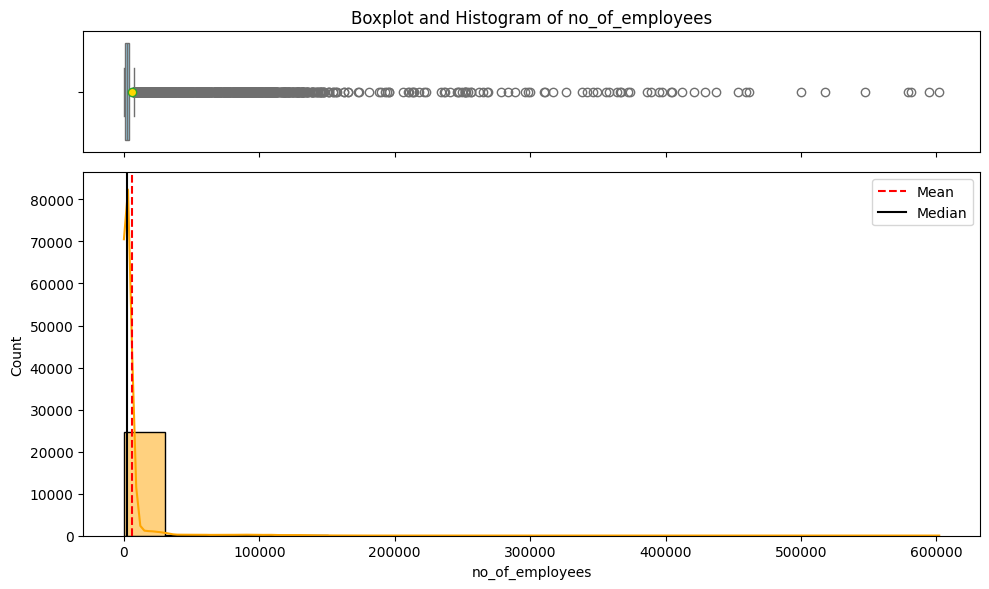

In [26]:
custplot_box_hist(df, "no_of_employees", show_kde=True, box_color="skyblue", hist_color="orange")


In [27]:
df["no_of_employees"].describe()

,no_of_employees
count,25480.000000
mean,5667.089207
std,22877.917453
min,11.000000
25%,1022.000000
50%,2109.000000
75%,3504.000000
max,602069.000000


**Observations:**

* Histogram & bar plot depicts that distribution is highly right skewed.

* The vast majority of companies in the dataset has fewer than 10,0000 employees, as shown by the bars on the left side of histogram plot with median of 3504 employees.

* Maximum number of employees is around 60,0000.

* Minimum number of employees is 11.

* There is presence of multiple extreme outliers extending up to 602069 employees as shown by box plot. These points are far beyond the upper whisker of the boxplot.

**Observations on yr_of_estab**

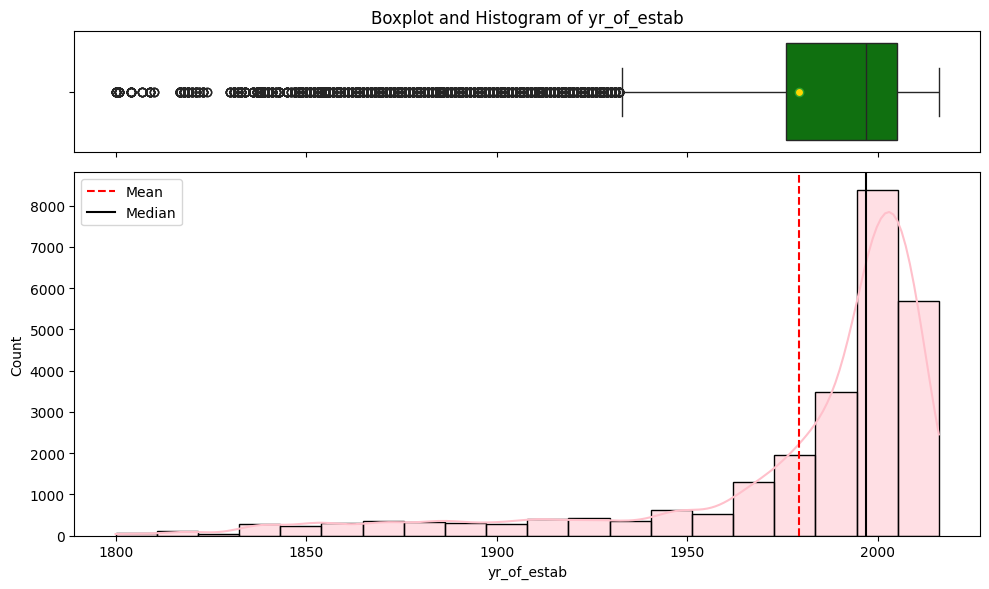

In [28]:
custplot_box_hist(df, "yr_of_estab", show_kde=True, box_color="green", hist_color="pink")

**Observations:**

* Histogram plot reveals distributions is highly left skewed with distinct peaks. This suggests that data comes from different years groups.

* The data spans over two centuries, from the oldest company founded in 1800 to the newest in 2016.

* There are several extreme low value outliers present beyond upper whisker i.e. companies established in 1800s and early 1900s are acting as historical outlier. They are not error but rare observation and actual data.

* The mean (1979) is significantly lower than the median (1997), points to the left skewness.

* The IQR is from 1976 to 2005. this means 50% of all companies in the dataset were established within this recent 29 years window and this recent cluster forms the taller peak on the right side of histogram.



**Observations on prevailing_wage**

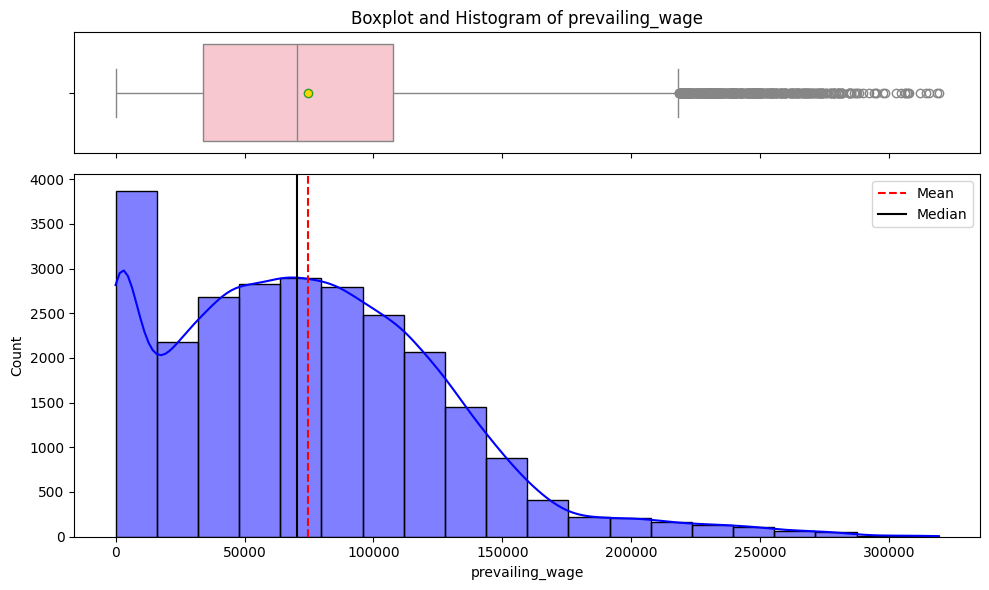

In [29]:
custplot_box_hist(df, "prevailing_wage", show_kde=True, box_color="pink", hist_color="blue")


**Observations:**

* The histogram shows a highly right skewed distribution. Majority of data is concentrated around on the left side of the plot, reflecting most job offers around standard market rates.

* The median wage of $70,308 serves as a solid reference for the average job offer since it is less affected by extreme values than the mean.

* The wide interquartile range ~(34k - 108k) dollars shows how much variations in standard wages offered.

* The minimum wage offered is ~$2.13, while maximum salary offered is 319210 dollars.

* There are many extreme outliers on the lower whisker ranging from 21,0000 to 319,210 dollars. These extreme values are not data error but represents wages offered for highly specialised , senior or in-demand skills.


**Observations on continent**

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64




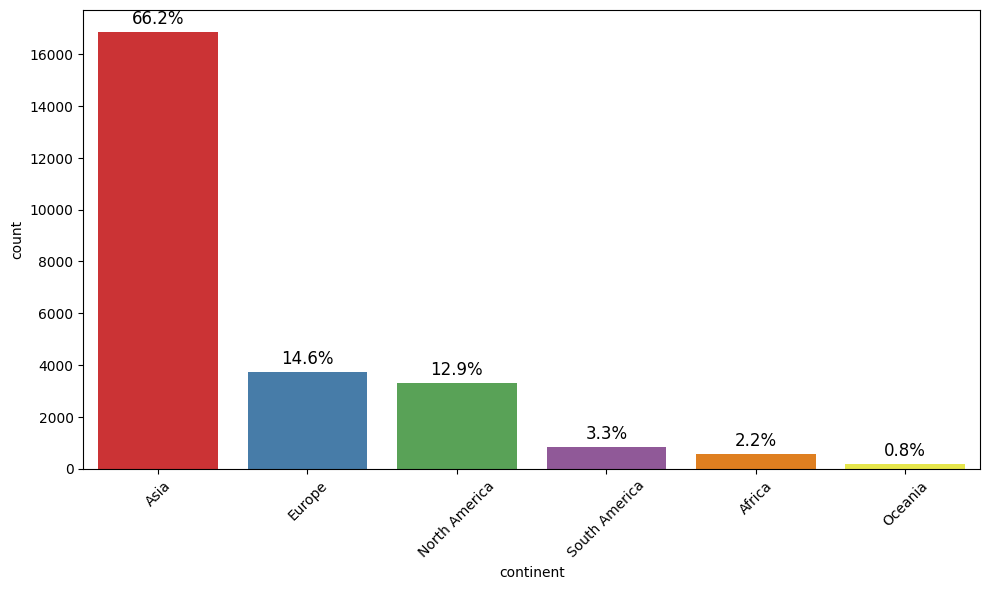

In [30]:
cust_label_barplot(df, "continent", palette="Set1", show_percent=True)

**Observations:**

* ***Asia dominates:*** Asia has the highest number of observations **(16,861, or 66.2%** of the overall dataset).  This suggests a significant over-representation of Asia in the data.

* The **dataset is substantially skewed** between continents as shown in the bar plot, with Asia accounting for more than half of the total observations.  This may bias any model trained on this data towards Asia.

* ***Europe and North America*** have a moderate representation, with **3,732 (14.6%) and 3,292 (12.9%)**, respectively.

* The geographic regions of ***South America, Africa, and Oceania*** have little representation in the dataset.  Their totals are **852 (3.3%), 551 (2.2%), and 192 (0.8%)**, respectively.

* The low numbers for Africa, Oceania, and South America indicate that insights for **these regions may be less reliable or statistically weaker than for Asia, Europe, and North America**.

* Overall, data looks highly right skewed.

**Observations on education_of_employee**

education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64




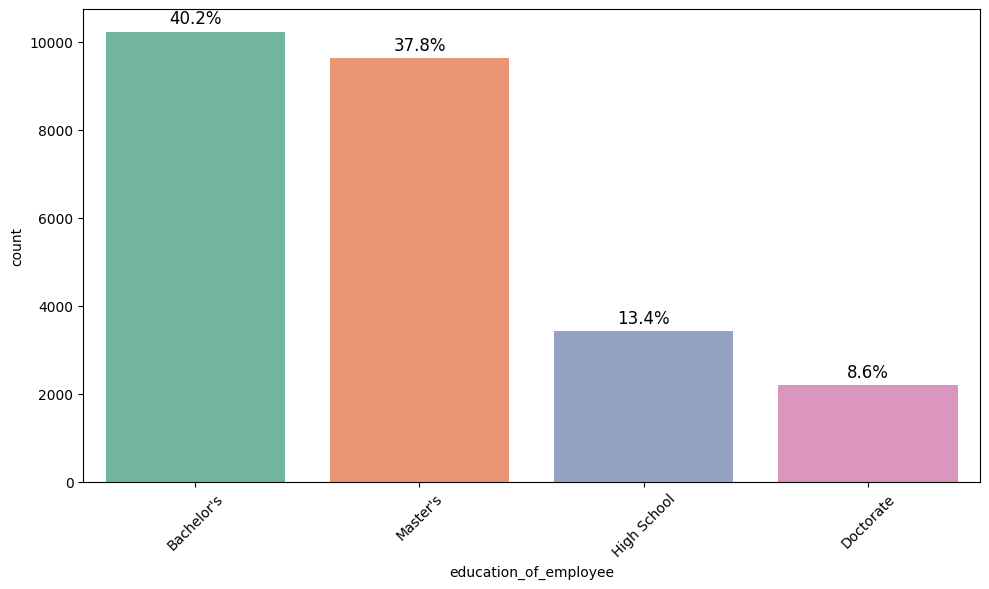

In [31]:
cust_label_barplot(df, "education_of_employee", palette="Set2", show_percent=True)

**Observations:**

***Bachelor's Degree: The largest applicant pool***

 * Individuals with a Bachelor's degree represent the single largest educational demographic, accounting for **10,234 people (40.2%)**.
 * This suggests that a four-year university degree is the most common prerequisite for the positions in this dataset.

***Master's Degree: Strong Second Majority***

 * Individuals with a Master's degree are nearly as common, at **9,634 people (37.8%)**.
 * The large number of Master's degree holders demonstrates a significant demand for positions requiring specialised, advanced expertise.

***High School Diploma: A Distinct Minority***

 * Only **3,420 people (13.4%)** identify a High School certificate as their highest educational achievement.
 * This modest share indicates that the opportunities in this dataset are mostly for professions requiring a higher degree background.

***Doctorate Degree: A Highly Specialised Niche***

 * Individuals with Doctorates are the lowest educational category, with **2,192 people (8.6%)**.
 * This category includes a highly specialised group of top-tier experts and senior professionals.

**Conclusion:**
* **Overall, 86.6% of persons in this dataset have a Bachelor's degree or higher**.

* This distribution is slightly right skewed &  demonstrates that the majority of the jobs listed here are for roles that need a highly educated and specialised skilled workers.

**Observations on region_of_employment**

region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64




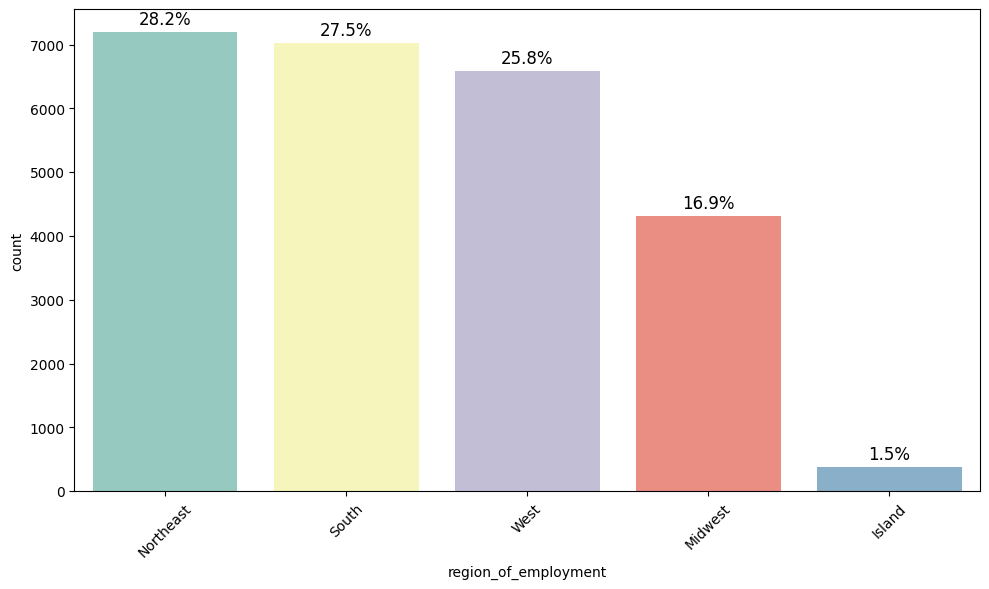

In [32]:
cust_label_barplot(df, "region_of_employment", palette="Set3", show_percent=True)

**Observations:**

***Northeast: The primary hub***

* The Northeast area is the leading job hotspot, with **7,195 roles** available, accounting for **28.2%** of all opportunities.
* This suggests a significant number of job opportunities in the region's key economic centres.

***South: A Strong Second***

* The South area is a close second, with **7,017 spots (27.5%)**.
* This nearly comparable percentage to the Northeast demonstrates that it is an equally important and dominant market for employment.

***West is a major contributor***

* The West area also contributes significantly, with **6,586 slots (25.9%)**.
* This reinforces the trend of coastal regions being the dominant provider of job opportunities.

***Midwest: A Notable Minority***

* The Midwest accounts for a lower share, with** 4,307 positions (16.9%)**.
* While still large, its share is far lower than the top three regions.

***Island's Almost Negligible Presence***

* There are just **375 jobs (1.5% of total employment)** on island territories.
* This reflects a very specific and constrained job market within the dataset.


**Conclusion:**
* Overall distribution is skewed towards coastal regions.
* The distribution of work opportunities is extremely uneven.
* It is biased towards the three **coastal regions: northeast, south, and west**.
* These **three regions make up 81.6% of all job openings**, demonstrating a considerable coastal bias in employment location.

**Observations on unit_of_wage**

unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64




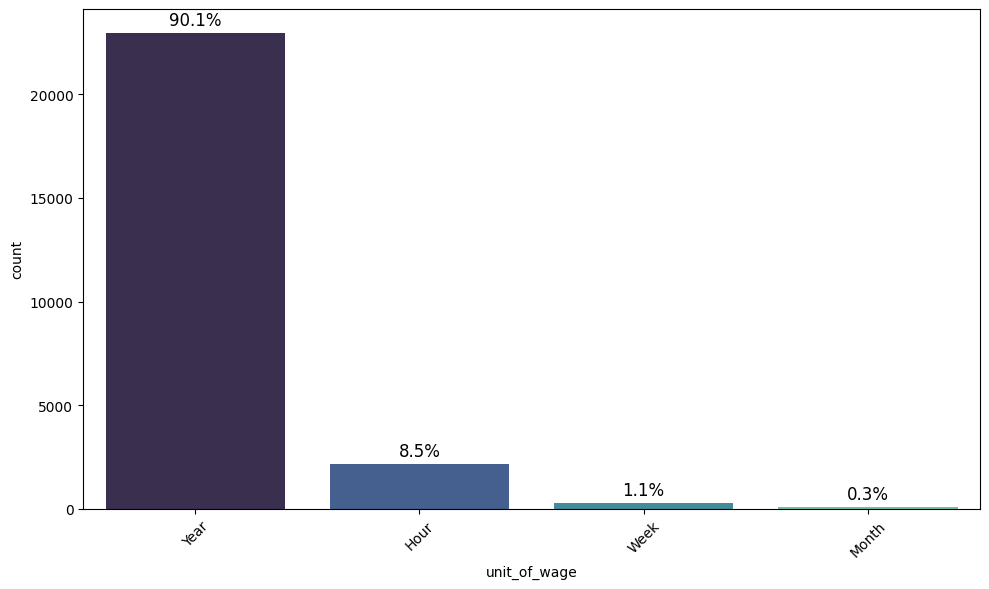

In [33]:
cust_label_barplot(df, "unit_of_wage", palette="mako", show_percent=True)

**Observations:**

***Strong Dominance of Yearly Wages***

* The great majority of positions, **22,962 (90.1%)**, pay an annual salary.
* This suggests that the conventional and expected practice for these occupations is to present salary as an annual sum, as is customary for full-time, professional work.

***The Low Presence of Hourly Wages***

* A tiny but significant percentage of positions, **2,157 (8.5%)**, are paid hourly.
* This implies that some employment, such as specialised contractors, part-time specialists, or certain hourly-based professional services, fall into this category.

***Narrow Use of Weekly and Monthly Units***

* The Weekly and Monthly payment units are uncommon, with only **272 (1.1%) and 89 (0.3%)** instances, respectively.
* These units in the dataset indicate employment contracts that are particularly niche or non-standard.


**Conclusions:**

* The distribution of salary units is **severely right skewed**, with a yearly wage being the nearly universal standard.
* This large bias towards yearly compensation (90.1%) is consistent with the fact that the majority of occupations are full-time, as evidenced by the full_time_position variable.

**Observations on has_job_experience**

has_job_experience
Y    14802
N    10678
Name: count, dtype: int64




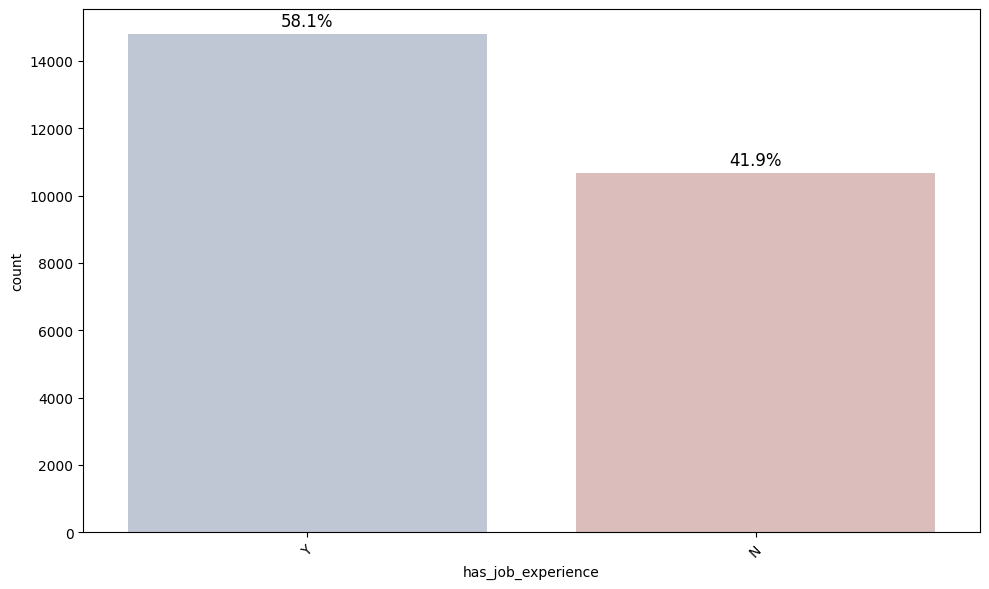

In [34]:
cust_label_barplot(df, "has_job_experience", palette="vlag", show_percent=True)

**Observations:**

***Experienced applicants make up the majority***

* The vast majority of applicants, **14,802 persons (58.1%)**, have prior employment experience **(Y)**.
* This suggests that the majority of the occupations in the dataset require or prefer candidates who have prior professional experience.

***A significant number of inexperienced applicants***

* A significant proportion of candidates, **10,678 (41.9%), have no prior work experience (N)**.
* This significant share means that there are numerous chances for entry-level workers, recent graduates, and those transitioning careers.

**Conclusion:**
* The dataset includes a fair mix of chances for both **experienced professionals (58.1%) and freshers(41.9%)** to the employment market.
* The distribution of experienced and inexperienced applications is fairly even, with a **minor skewness** towards experienced individuals.



**Observations on requires_job_training**

requires_job_training
N    22525
Y     2955
Name: count, dtype: int64




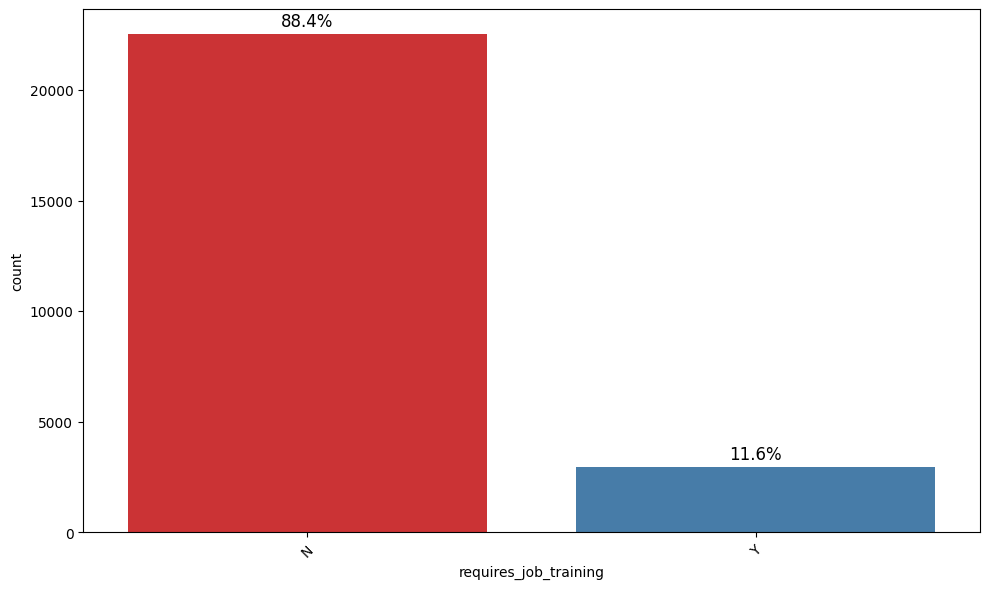

In [35]:
cust_label_barplot(df, "requires_job_training", palette="Set1", show_percent=True)

**Observations:**

* The distribution is highly right skewed, with a dominant focus on roles that need no training.

***An overwhelming majority  Requires No Training (N)***

* The great majority of employment, **22,525 (88.4%)**, require no job training for the employee (N).
* This suggests that employers are generally looking for applicants who already have the essential skills and can contribute quickly.

***A small number of roles require training (Y)***

* Only **2,955 (11.6%)** of positions indicate the need for job training (Y).
* This shows that firms are willing to invest in training for the suitable individual in a certain range of tasks, most likely for highly specialised talents or company-specific procedures.


**Observations on full_time_position**

full_time_position
Y    22773
N     2707
Name: count, dtype: int64




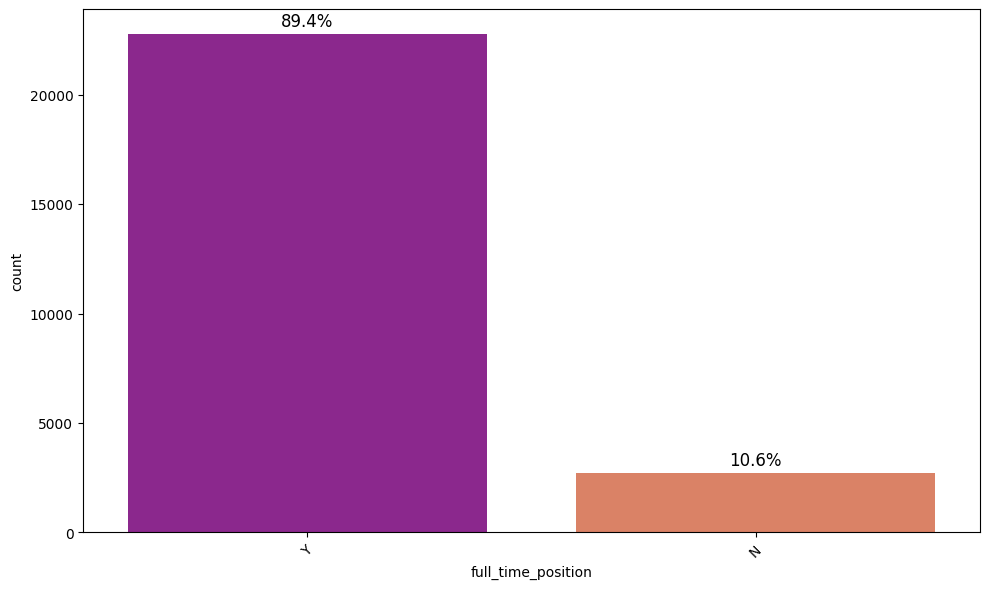

In [36]:
cust_label_barplot(df, "full_time_position", palette="plasma", show_percent=True)

**Observations:**

***Dominance of full-time positions (Y)***

* The vast majority of job jobs, **22,773 (89.4%)**, are full-time (Y).
* This suggests that the opportunities in this dataset are predominantly for secure, permanent employment, as opposed to temporary or part-time labour.

***Limited part-time opportunities (N)***

* Part-time employment accounts for only **2,707 (10.6%)** of total positions (N).
* This shows that part-time jobs are uncommon and most likely represent specialised, flexible, or niche job arrangements.


**Conclusions:**

* Overwhelmingly full-time positions
 The distribution of position kinds is **extremely right skewed**, with full-time opportunities being the nearly universal norm.
* This strong bias towards full-time employment (89.4%) indicates that the dataset represents a job market dominated by full-time, committed employment arrangements.  Part-time positions are the exception rather than the rule.


**Observations on case_status**

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64




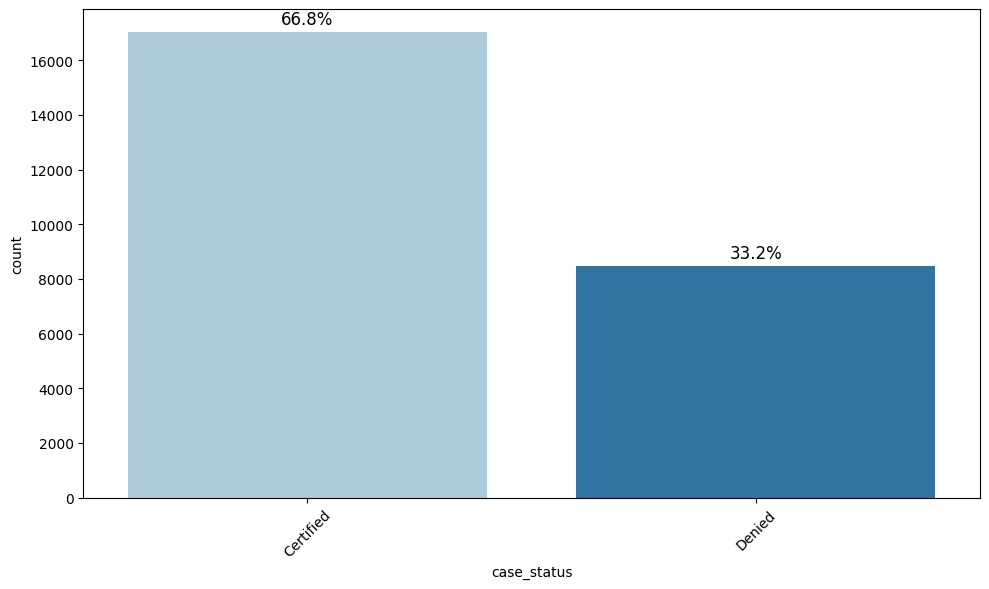

In [37]:
cust_label_barplot(df, "case_status", palette="Paired", show_percent=True)

**Observations:**

***The majority of applications are certified***

* The vast majority of visa applications, **17,018 (66.8%)**, were certified (approved).
* This suggests that the majority of applicants in the sample successfully meet the requirements for visa approval.

***A significant number of applications are denied***

* A significant percentage of applications, **8,462 (33.2%)**, were denied.
* This high denial rate demonstrates how selective the procedure is, with a large number of applications failing to meet all the standards or requirements for visa processing.

**Conclusions:**
* The distribution of outcomes demonstrates a **moderate skew towards certified**, with roughly two-thirds of all applications approved.
* However, the 33.2% denial rate is too high to ignore, indicating that the application procedure is hard and selective.  

##**Bivariate Analysis**

**Let us first label encode few object type columns.**

In [38]:

# first we encode our dependent variable
df["case_status"] = df["case_status"].replace({'Certified':1, 'Denied':0})

# now we encode the independent variables with Y: 1 & N :0
df["has_job_experience"] = df["has_job_experience"].replace({'Y':1, 'N':0})
df["requires_job_training"] = df["requires_job_training"].replace({'Y':1, 'N':0})
df["full_time_position"] = df["full_time_position"].replace({'Y':1, 'N':0})

In [39]:
# List the columns we just label encoded
encoded_columns = ["case_status", "has_job_experience", "requires_job_training", "full_time_position"]

# verify the unique values for each of these columns
for col in encoded_columns:
    unique_vals = df[col].unique()
    print(f"Unique values in '{col}': {sorted(unique_vals)}")

Unique values in 'case_status': [np.int64(0), np.int64(1)]
Unique values in 'has_job_experience': [np.int64(0), np.int64(1)]
Unique values in 'requires_job_training': [np.int64(0), np.int64(1)]
Unique values in 'full_time_position': [np.int64(0), np.int64(1)]


**Observations:**

* We have successfully label encoded case_status', 'has_job_experience','requires_job_training', 'full_time_position'

**Heatmap Analysis on All Numerical Columns**

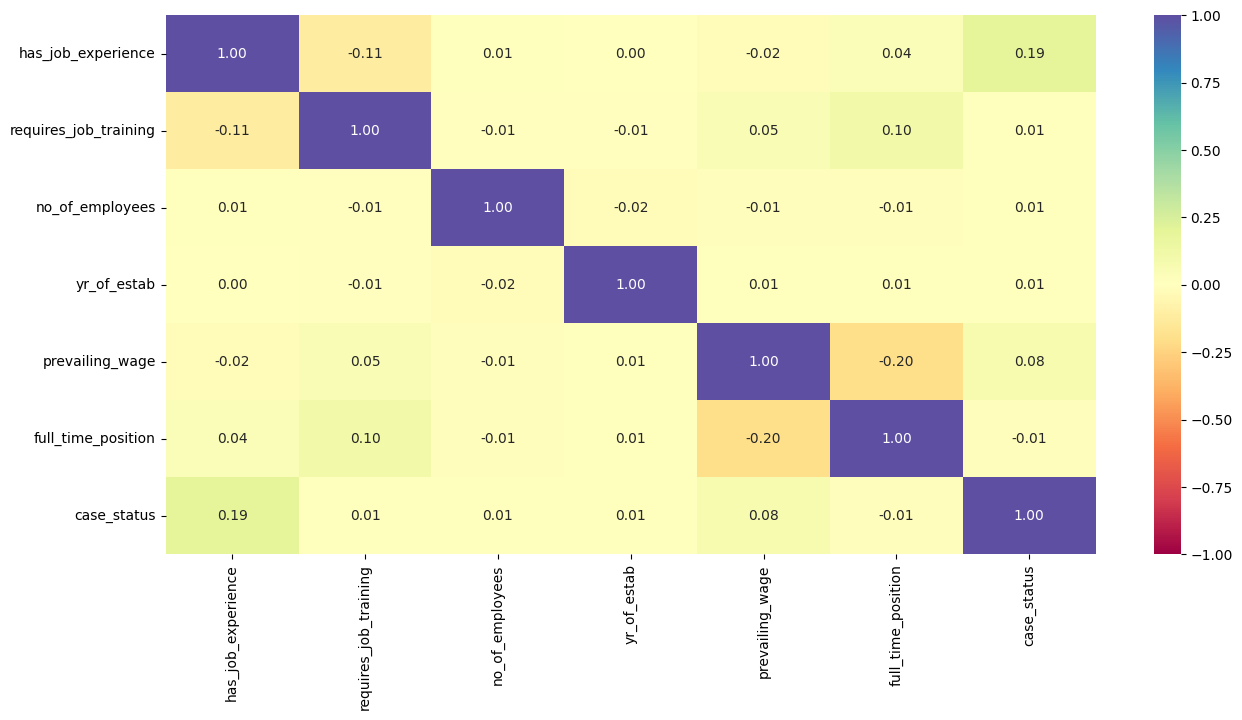

In [40]:
# To create the heatmap, We'll create a list of only the numerical variables
corr = df.select_dtypes(include=np.number).columns.tolist()

# Now let's plot the heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(
    df[corr].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations:**

***Job experience  is the strongest predictor of visa approval***

* The highest positive correlation (**r = 0.19**) exists between visa certification (case_status) and employment experience (has_job_experience).
* This positive link suggests that applicants with prior job experience are more likely to get their visas approved.

***Full-time roles are linked with lower wages***

* A significant negative correlation (**r = -0.20**) appears between wage (prevailing_wage) and position type (full_time_position).
* This shows that full-time occupations in this dataset pay lower earnings than part-time or contract work, which is counterintuitive and warrants additional examination.

***Experienced applicants require less training***

* There is a logical negative association (**r = -0.11**) between experience (has_job_experience) and training requirements.
* This demonstrates that applicants with prior experience are less likely to require further job training.

***There are no redundant variables detected***

* All correlations between the predictor variables are quite weak (**less than |r = 0.20|**).
* This means that there is no multicollinearity - each variable contributes unique information and can be combined in a predictive model.

***The Company Profile Has Little Direct Influence***

* Both firm size (number_of_employees) and company age (year_of_estab) have a near-zero correlation (**roughly r = 0.01**) with visa clearance.
* This suggests that the size or age of an organisation has almost no direct linear association with the likelihood of visa approval.


***Most relationships are weak***

* The vast majority of correlations are close to zero, indicating that the dataset lacks straightforward linear relationships.
* This implies that more advanced modelling techniques may be required to identify complicated trends driving visa choices as simple model will not perform well.

**Observations on education_of_employee vs case_status**

case_status               0      1    All
education_of_employee                    
Bachelor's             3867   6367  10234
Doctorate               280   1912   2192
High School            2256   1164   3420
Master's               2059   7575   9634
All                    8462  17018  25480
----------------------------------------------------------------------------------------------------


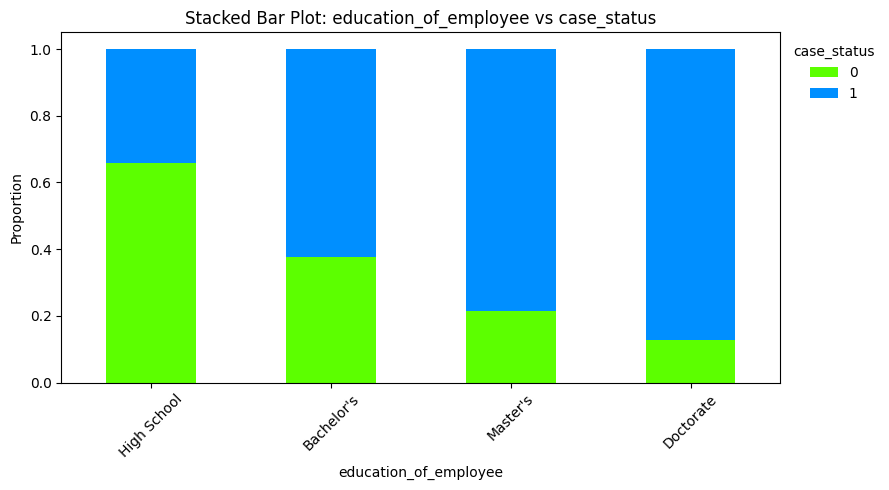

In [41]:
stacked_barplot_custom(df, "education_of_employee", "case_status", palette='gist_rainbow')

**Observations:**

***Doctorate holders have the highest certification rate***

* Applicants with a doctorate degree have a very high certification rate.  **1,912 out of 2,192** applications were approved, for an impressive **87.2% approval rate**.
* This suggests that sophisticated, specialised knowledge is in high demand and significantly favoured during the visa acceptance procedure.

***Very High Certification Rate: Master's Degree Holders***

* Applicants holding a Master's degree have an excellent likelihood of approval.  **7,575 of 9,634** applications were certified, yielding an acceptance percentage of **78.6%**.
* This confirms the high preference for applicants with more advanced education than a bachelor's degree.

***Moderate Certification Rate for Bachelor's Degree Holders***

* Applicants holding a Bachelor's degree have a moderate certification rate.  **6,367 of 10,234** applications were approved, representing a **62.2%** visa acceptance rate.
* While, a bachelor's degree alone has a much lower chance of clearance than advanced degrees.

***Lowest Certification Rate: High School Graduates***

* Applicants with only a high school diploma face the most difficult odds.  **Only 1,164 of 3,420** applications were approved, for a poor acceptance rate of **34.0%**.

* This shows that visas are largely certified for occupations requiring a higher education background, while applications based only on experience or abilities (without a degree) are rejected at a far higher rate.


**Conclusions:**

* There is a clear and substantial positive correlation between an applicant's educational level and their chances of visa approval.
* The certification rate rises considerably with each higher level of education.  Higher education levels range from high school (34%), bachelor's (62%), master's (79%), to doctoral (87%).
* This tendency strongly suggests that the visa procedure is intended to prioritise and certify highly educated and specialised individuals.

**Observations on unit_of_wage vs case_status**



case_status      0      1    All
unit_of_wage                    
Hour          1410    747   2157
Month           34     55     89
Week           103    169    272
Year          6915  16047  22962
All           8462  17018  25480
----------------------------------------------------------------------------------------------------


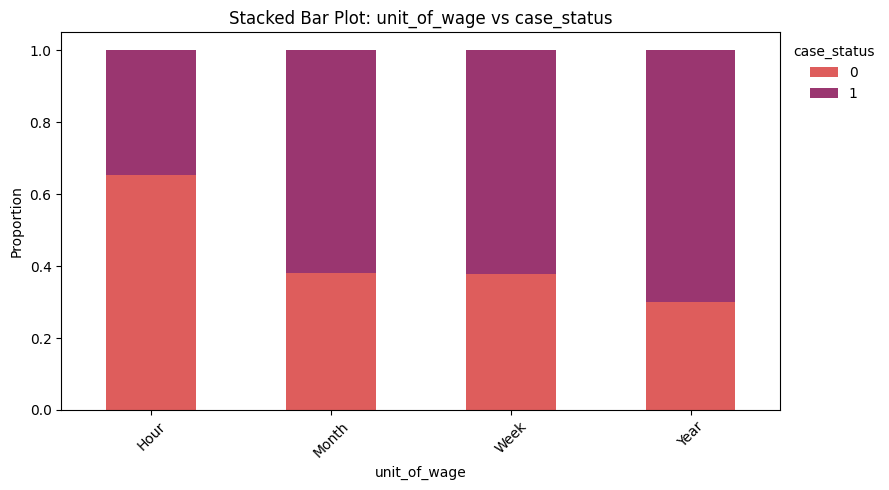

In [42]:
stacked_barplot_custom(df, "unit_of_wage", "case_status", palette='flare')

**Observations:**

***Highest Certification Rate: Yearly-Paid Roles***

* Positions with annual salaries have the greatest certification rate.  **16,047 out of 22,962** applications were approved, yielding a solid **69.9%** visa acceptance rate.
* This suggests that secure, full-time, salaried jobs are evaluated favourably and have the best chance of visa acceptance.

***High Certification Rate for Weekly and Monthly Paid Roles***

* Roles with **weekly (62.1%) and monthly (61.8%)** pay have much higher approval percentages.
* This shows that reviewers believe certain non-hourly contract forms are legitimate and stable.

***Lowest Certification Rate: Hourly-Paid Positions***

* Applicants earning an hourly pay have the most difficult odds.  Only **747 of the 2,157** applications were certified, resulting in a **34.6%** visa approval rate.
* This shows that hourly-paid occupations are associated with less permanent, transient, or part-time work, resulting in increased scrutiny and denial rates.

**Insights:**
* There is a clear link between wage unit and case status likelihood.
* Long-term and steady pay arrangements receive the highest visa acceptance rate (yearly > weekly ≈ monthly).
* The rate is significantly lower for short-term or variable compensation (hourly).
* This pattern strongly suggests that the perceived stability and longevity of the employment is an important consideration in the visa approval decision.  Applications for permanent, salaried positions are much more likely to be certified.


**Observations on continent vs case_status**

case_status       0      1    All
continent                        
Africa          154    397    551
Asia           5849  11012  16861
Europe          775   2957   3732
North America  1255   2037   3292
Oceania          70    122    192
South America   359    493    852
All            8462  17018  25480
----------------------------------------------------------------------------------------------------


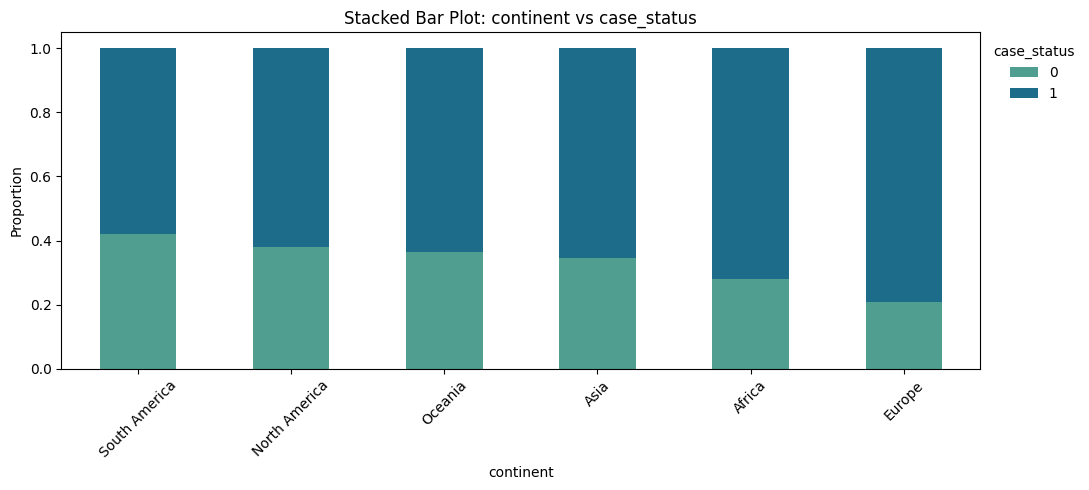

In [43]:
stacked_barplot_custom(df, "continent", "case_status", palette='crest')

**Observations:**

***European applicants have the highest certification rate***

* Approval Rate: **79.2% (2,957 approved from 3,732 total)**
* European applicants have the greatest visa certification rates.
* A significant **majority of applications from Europe are approved**.

***Very High Certification Rate for Oceanian Applicants***

* Approval Rate: **63.5% (122 approved of 192 total**).
* **Second highest approval rate**, albeit with a lower sample size.
* Strong performance despite reduced candidate numbers.

***Moderate Certification Rate for African and South American Applicants***

* **Africa**: **72.1%** approval rate (397 out of 551).

* **South America**: 57.9% approval percentage (493 out of 852).

* **Solid approval rates, particularly for African applicants**.

***Lower Certification Rate for North American and Asian Applicants***

* **North America: 61.9%*** approval rate (2,037 approvals out of 3,292).
* **Asia: 65.3%** approval rate (11,012 accepted from 16,861)
* While still a majority of approvals, these rates are **lower than other locations**.
* **Asia is the greatest candidate pool (66.2%** of total applications).

**Insights:**
* There is a 24.3 percentage point difference between the highest (Europe: 79.2%) and lowest (South America: 57.9%) approval percentages.
* European applicants have much higher success percentages than other regions.
* Asian candidates dominate in volume (66.2% of all applications), with a moderate approval rate (65.3%).
* African applicants demonstrate great performance (72.1% approval) despite their smaller numbers.


**Observations on has_job_experience vs case_status**

case_status            0      1    All
has_job_experience                    
0                   4684   5994  10678
1                   3778  11024  14802
All                 8462  17018  25480
----------------------------------------------------------------------------------------------------


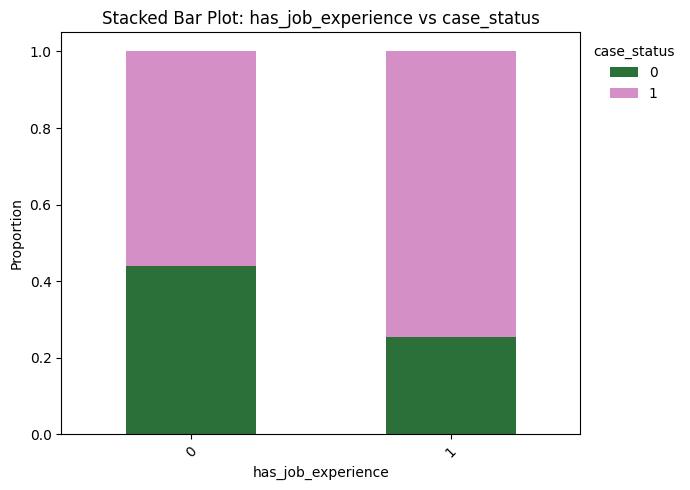

In [44]:
stacked_barplot_custom(df, "has_job_experience", "case_status", palette='cubehelix')

**Observations:**

***Higher Certification Rate: Experienced Applicants***

* Approval Rate: **74.5%** (11,024 accepted from 14,802 total)
* Applicants with job experience have much better certification rates.
* Nearly three out of every four experienced applicants are approved.

***Lower Certification Rate for Inexperienced Applicants***

* Approval Rate: **56.1%** (5,994 authorised from 10,678 total)
* Applicants without work experience have more challenging approval odds.
* A little more than half of novice applicants get approved.

**Insights:**

* 18.4% point difference between experienced (74.5%) and freshers (56.1%) applicants.
* Experience is an important factor in the approval process.
* Experienced applicants are 1.33 times more likely to be approved than novice applicants.
* The majority of candidates (58.1%) have job experience.
* Thus, **having job experience increases approval chances by 32.8%** (18.4% / 56.1%) compared to no experience.

**Observations on requires_job_training vs case_status**

case_status               0      1    All
requires_job_training                    
0                      7513  15012  22525
1                       949   2006   2955
All                    8462  17018  25480
----------------------------------------------------------------------------------------------------


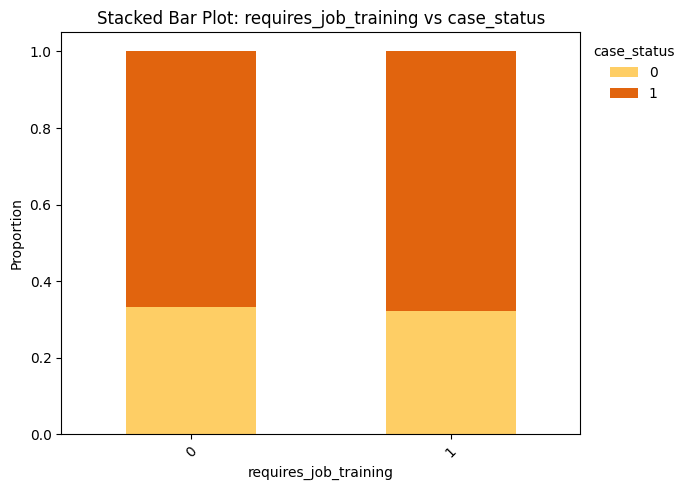

In [45]:
stacked_barplot_custom(df, "requires_job_training", "case_status", palette='YlOrBr')

**Observations:**

***Higher certification rate: No training required***

* Approval rate: **66.7%** (15,012 accepted out of a total of 22,525).
* Positions requiring no job training have a substantially higher certification rate.
* Nearly two out of three applications are granted when no training is required.

***Slightly lower certification rate: Training is required***

* Approval Rate: **67.9%** (2,006 approved from 2,955 total)
* Surprisingly, professions that need training have a marginally higher approval rate.
* This contradicts the basic idea that training requirements will negatively effect approval.

**Insights:**
* It include a **1.2%  point advantage** for professions needing training (67.9% vs. 66.7%).
* Minimal practical difference in approval rates based on training requirements.
* The vast majority of professions (88.4%) require no training.
* **Training requirements do not appear to be a key issue in approval decisions**.


**Observations on prevailing_wage vs case_status**

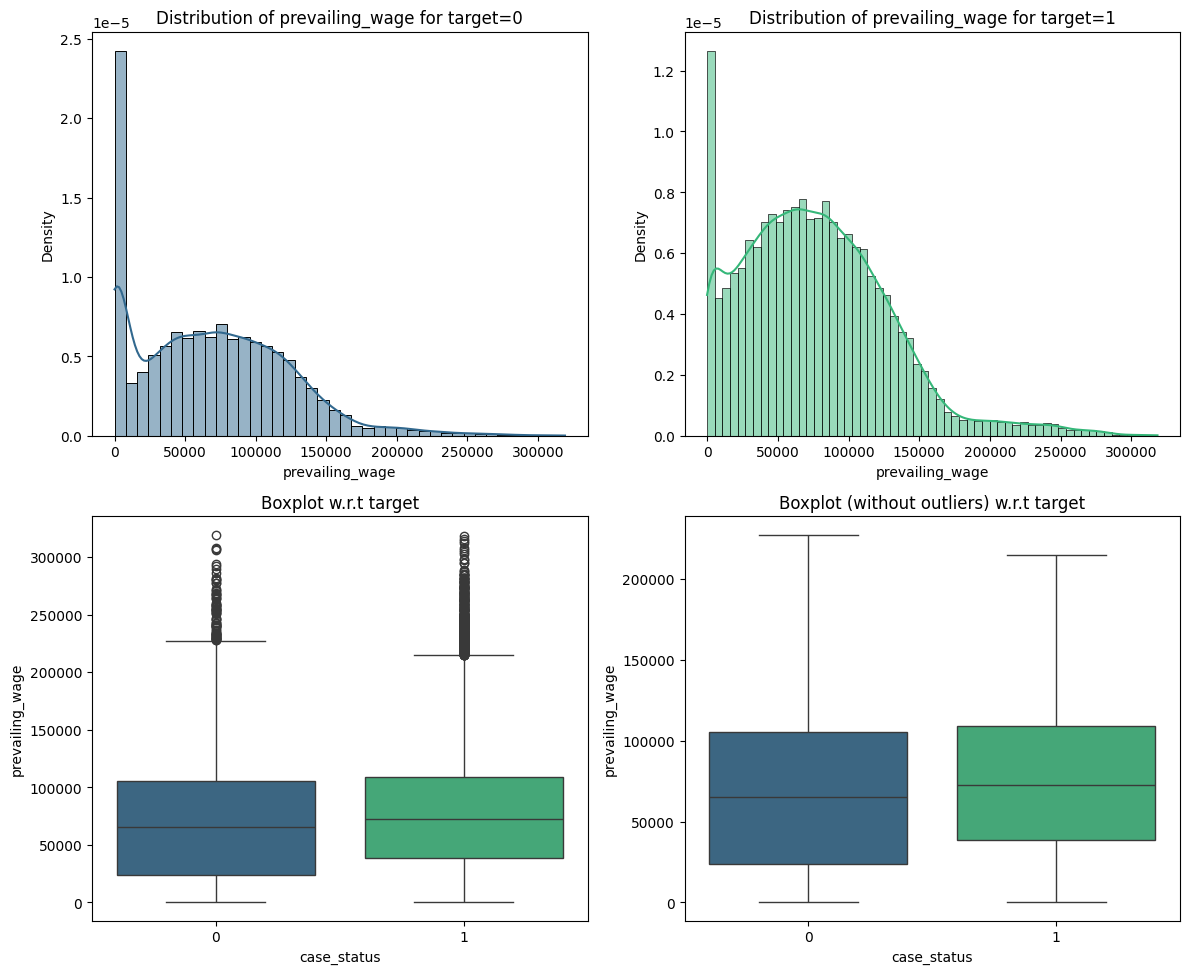

In [46]:
distribution_plot_wrt_target(df, 'prevailing_wage', 'case_status')

**Observations:**

* The prevailing wage has highly right skewed distribution, and is quite comparable between certified and rejected visas; the main distinction is in the lowest earnings, where denied visas have a density of **around 2.5** and certified visas have a density of **around 1.30**.  
* Also, certified visas have a somewhat higher density than denied visas.
* The distribution on the boxplot is quite similar, with the exception of a somewhat smaller number of denied visas.
* Offering a greater salary may marginally boost the likelihood of certification, even if it is not a reliable indicator in and of itself.

**Observations on no_of_employees vs case_status**

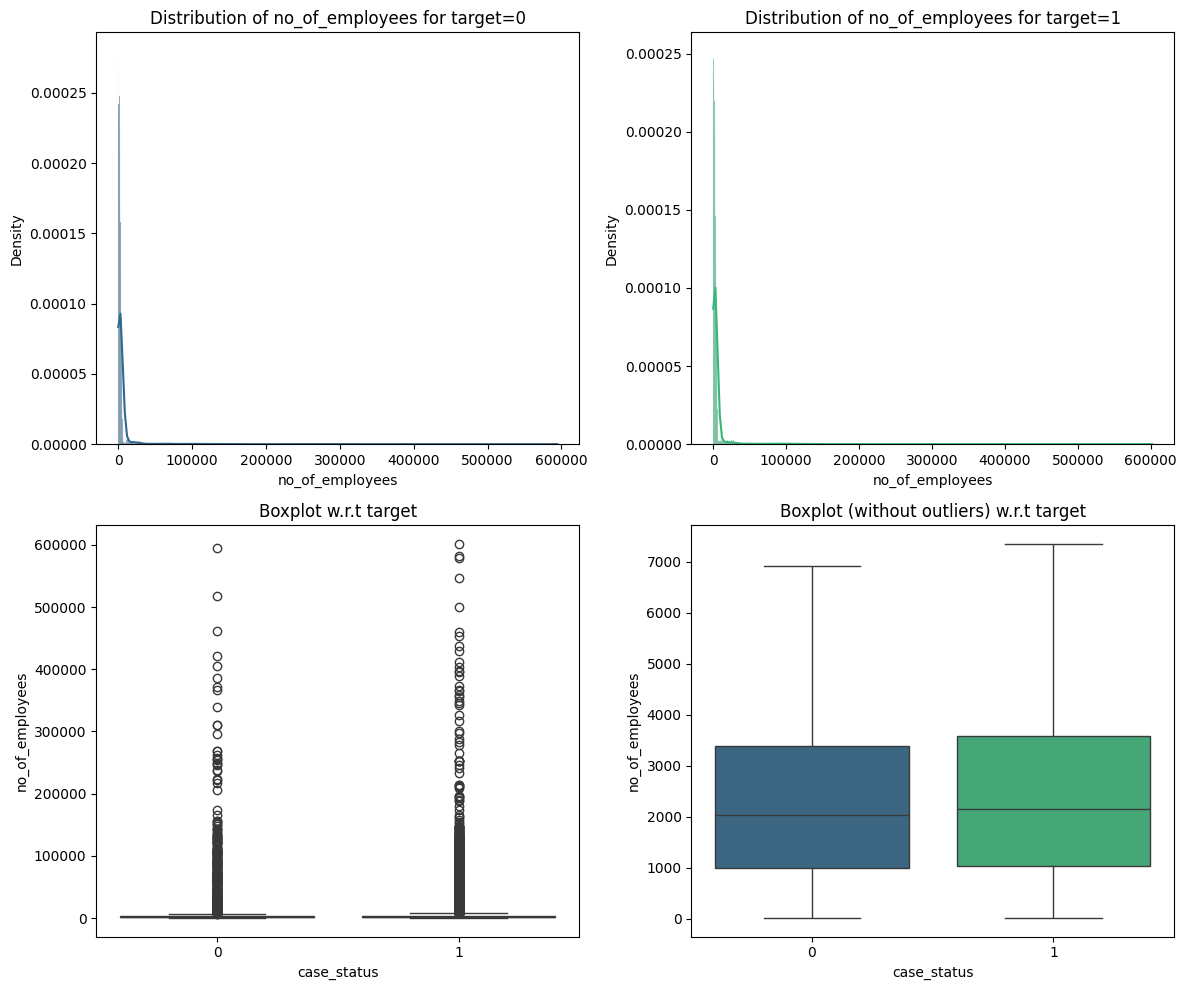

In [47]:
distribution_plot_wrt_target(df, 'no_of_employees', 'case_status')

**Observations:**

* Density plot shows almost similar trend for denied & accepted visas status based on number of employees, with distribution is highly right skewed.
* The number of employees with denied visa has density **~0.00023** while, the density for accepted is **~0.00024**.
* The box plot shows no_of_employees with denied status has median around 2k while accepted status has slightly above 2k.
* Outliers are present in both case status.
* The average company size is also slightly higher for certified visas.
* This is because visas from bigger, more reputable organisations have a minor propensity to be certified.  
* This probably reflects the idea that larger companies, which might have more financial stability and familiarity with the immigration procedure, are more legitimate and lower risk.
* Thus, company size (no_of_employees) is not a decisive feature, but rather a minor supporting trait.




**Observations on yr_of_estab vs case_status**

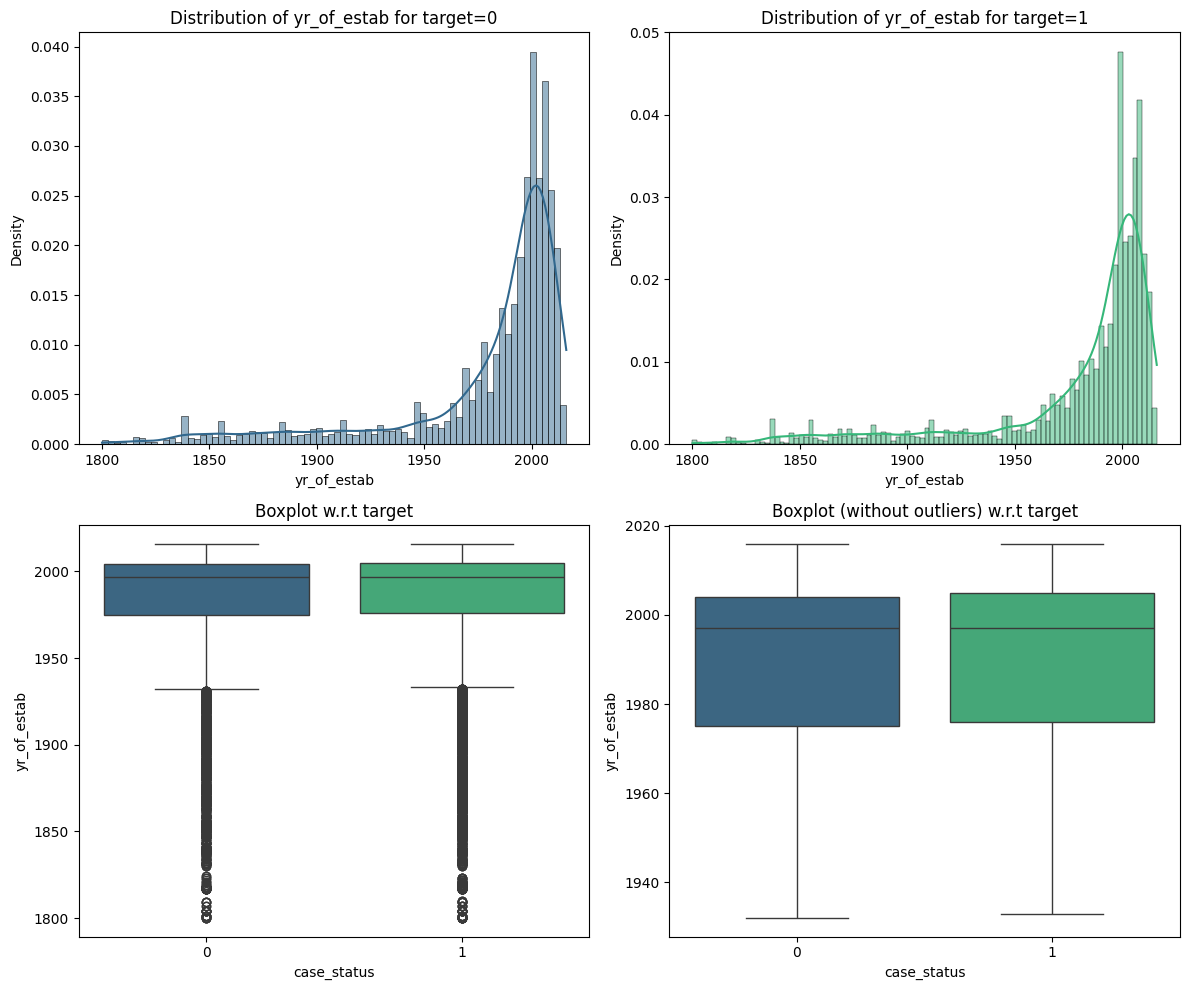

In [48]:
distribution_plot_wrt_target(df, 'yr_of_estab', 'case_status')

**Observations:**

* Density plot shows highly left skewed distribution with similar trends in denied or accepted via status.
* **Density for denied case is ~0.26 while for accepted is ~0.025**.
* The box plot shows there are several outliers present on both cases of denied & accepted visa status.
* **Median year of establishment for a company is ~1995 in both the case** of denied & rejected visa status.
* This is a critical finding.  It means that the "typical" or median company in both categories is the same age (about 25-30 years old at the time of application).  A visa application from a company of this age has an equal chance of being approved or denied based only on this aspect.
* Both groups include outlier enterprises founded considerably earlier (e.g., in the 1800s).
* The presence of very old companies in both the accepted and refused visa groups demonstrates that company age is neither a guarantee of success nor a reason for denial.  
* Unlike education or experience, the year of establishment (business age) is a neutral predictor of visa certification.
* The data strongly suggests that visa officers do not prefer older, "legacy" enterprises over newer ones when making certification judgements.

**Observations on region_of_employment vs case_status**

case_status              0      1    All
region_of_employment                    
Island                 149    226    375
Midwest               1054   3253   4307
Northeast             2669   4526   7195
South                 2104   4913   7017
West                  2486   4100   6586
All                   8462  17018  25480
----------------------------------------------------------------------------------------------------


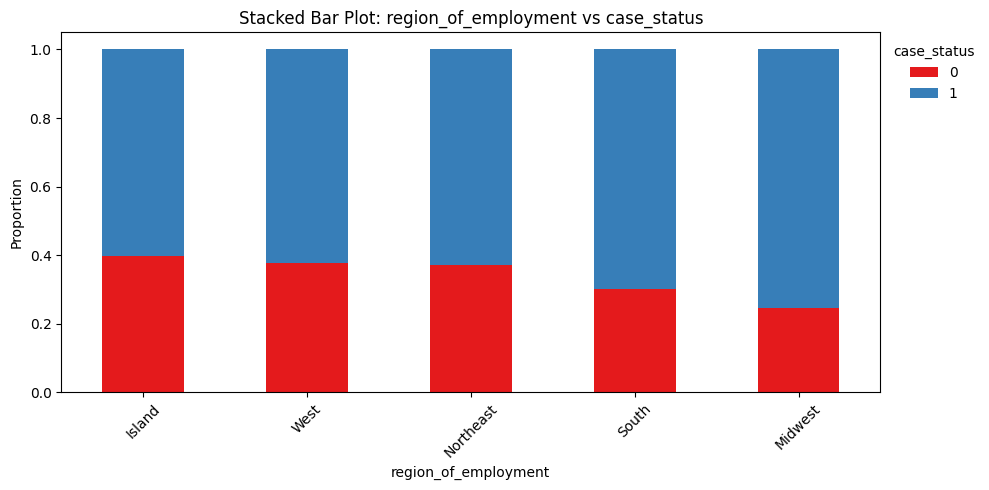

In [49]:
stacked_barplot_custom(df, "region_of_employment", "case_status", palette='Set1')

**Observations:**

***Midwest-Highest Approval Rate***
* The Midwest region has the highest certification rate.
* Approval Rate: **75.5%** (3,253 approved from 4,307 total)
* Three out of every four applications in the Midwest are approved.

***High Certification Rate: South Region***
* Approval Rate: **70.0%** (4,913 approvals out of 7,017 total)
* The South area demonstrates great performance, with a high approval rate.
* Applications here have very high prospects of success.

***Moderate Certification Rate: West and Northeast Regions***

* **West: 62.3%** approval rate (4,100 out of 6,586).
* **Northeast: 62.9%** approval rate (4,526 approvals out of 7,195).
* These big coastal regions exhibit moderate approval percentages.
* The majority approval rate remains high, but it is lower than in other regions.

***Lowest Certification Rate: Island Territories***
* Approval Rate: **60.3%** (226 approved of 375 total).
* The island territories have the lowest certification rate.
* This region faces the most demanding approval process.

**Key insights:**
* There is a **15.2 percentage point difference** between the highest (Midwest: 75.5%) and lowest (Island: 60.3%) approval percentages.
* Midwest applicants have much greater success percentages than other regions.
* Regional patterns matter: Heartland regions (Midwest, South) outperform coastal regions (Northeast, West).
* Island territories have the most difficult approval process.


**Observations on full_time_position vs case_status**

case_status            0      1    All
full_time_position                    
0                    852   1855   2707
1                   7610  15163  22773
All                 8462  17018  25480
----------------------------------------------------------------------------------------------------


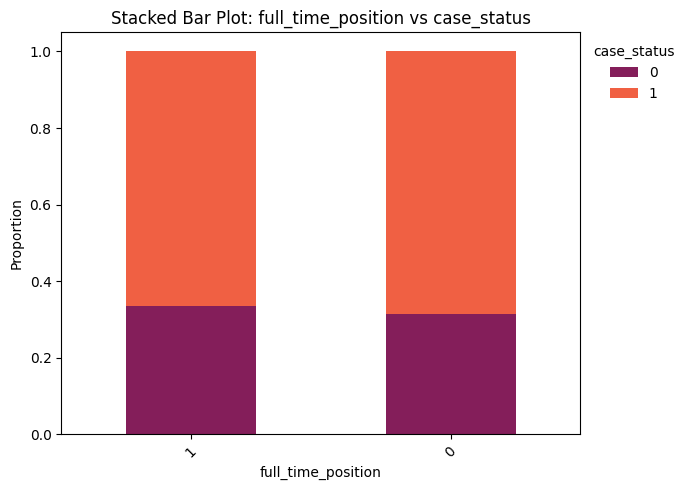

In [50]:
stacked_barplot_custom(df, "full_time_position", "case_status", palette='rocket')

**Observations:**

***Higher Certification Rate: Full-Time Role***

*  Approval Rate: **66.6%** (15,163 approved of 22,773 total)
* Full-time positions have a strong majority approval rate.
* Nearly two out of every three full-time applications are granted.

***Part-time positions have the highest certification rates***

* Approval Rate: **68.5%** (1,855 approved from 2,707 total)
* Surprisingly, part-time positions had a slightly higher approval rate.
* This goes against the initial notion that full-time positions would be preferred.


**Insights:**
* Part-time roles have a **1.9 percentage point advantage**(68.5% vs. 66.6%).
* There is a minimal practical difference in approval rates based on the employment type.
* The overwhelming majority of applicants (89.4%) are for full-time work.
* Employment type (full vs. part-time) does not appear to be a key influence in approval decisions.
* Contrary to popular belief, part-time jobs had a somewhat higher approval rate (68.5% vs. 66.6%).This suggests that part-time roles could be for specialized, high-demand skills where fewer qualified applicants exist.



**Observations on education_of_employee vs continent**

continent              Africa   Asia  Europe  North America  Oceania  \
education_of_employee                                                  
Bachelor's                143   7168    1299           1225       66   
Doctorate                  54    923     846            258       22   
High School                66   2290     490            401       36   
Master's                  288   6480    1097           1408       68   
All                       551  16861    3732           3292      192   

continent              South America    All  
education_of_employee                        
Bachelor's                       333  10234  
Doctorate                         89   2192  
High School                      137   3420  
Master's                         293   9634  
All                              852  25480  
----------------------------------------------------------------------------------------------------


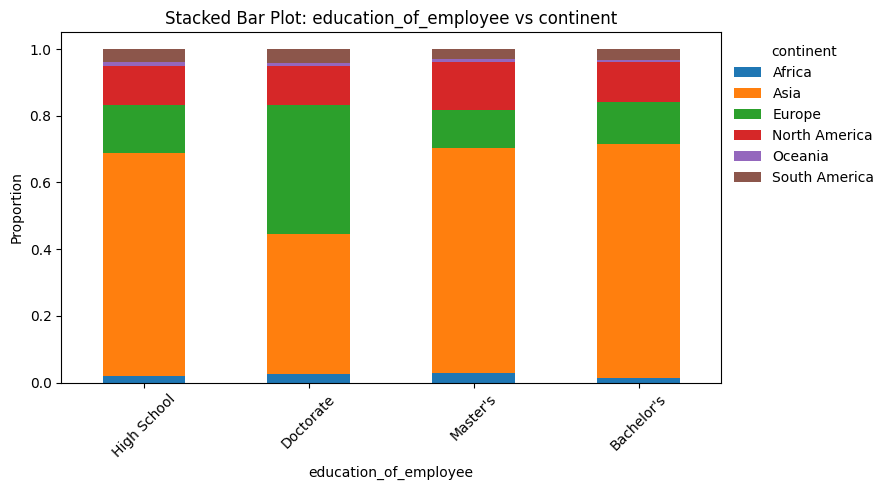

In [51]:
stacked_barplot_custom(df, "education_of_employee", "continent", palette='tab10')

**Observations:**

***Asia dominates at all educational levels***

* Asian applicants are the majority in all education categories:

  * Bachelor's: 7,168 out of 10,234 (**70%**).

  * Master's: 6,480 out 9,634 (**67%**)

  * Doctorate: 923 of 2,192 (**42%**).

  * High school: 2,290 out of 3,420 (**67%**)

* This reflects Asia's significant presence in the entire candidate pool.

***Europe: Strong on Advanced Degrees***

* Europe has unusually strong representation in higher education.

 * Doctorate: 846 out of 2,192 (**39%**)—second only to Asia.

 * Master's: **1,097** applications

* European candidates are more concentrated in advanced degree categories than other areas.

***North America has a balanced educational distribution***

* North American candidates are very evenly divided across education levels.

 * Bachelor's: **1,225**.

 * Master's: **1, 408**

 * High School: **401**.

 * Doctorate: **258**.

* The applicants' educational backgrounds are various.

***Africa and South America: Small but Qualified Pools***

* Both regions have fewer applicants but stronger educational profiles:
* **Africa** has a significant number of Master's degrees (**288**) in comparison to its overall population.
* **South America**: Balanced across academic levels, with a focus on bachelor's (**333**) and master's (**293**).


***Oceania: Small, but Highly Educated***

* Despite having the smallest region (**192 total applicants**):

  * Strong representation of Bachelor's (**66**) and Master's (**68**) degrees.
  * Proportionately high education level among applicants.


**Insights:**

* Regional educational patterns differ greatly.
* Asia's dominance is steady across all educational levels.
* European applicants are disproportionately represented in the advanced degree categories.
* All regions have a substantial representation in higher education (Bachelor's and above).

**Observations on has_job_experience vs continent**

continent           Africa   Asia  Europe  North America  Oceania  \
has_job_experience                                                  
0                      217   7071    1576           1348       89   
1                      334   9790    2156           1944      103   
All                    551  16861    3732           3292      192   

continent           South America    All  
has_job_experience                        
0                             377  10678  
1                             475  14802  
All                           852  25480  
----------------------------------------------------------------------------------------------------


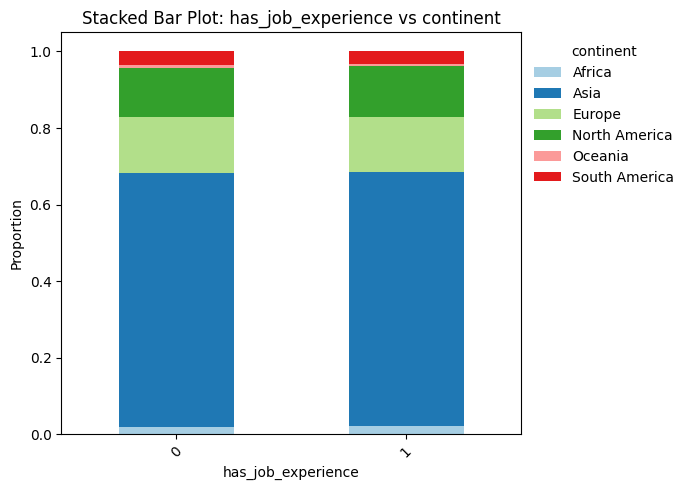

In [52]:
stacked_barplot_custom(df, "has_job_experience", "continent", palette='Paired')

**Observations:**

***Experienced applicants form the majority everywhere***

* Across all continents, applicants with work experience (Y:1) outweigh those without.
* This global pattern confirms that experienced professionals are the top applicants in all regions.

***Asia dominates both experience categories***

* Asia has the biggest number of experienced (**9,790**) and novice (**7,071**) applications.
* This reflects Asia's overwhelming domination of the whole candidate pool.

***Europe has the highest experience rate***

* Europe has the most experienced applicants:

 * Experienced: 2,156 (**58%**).

 * Inexperienced: 1,576 (**42%**).

 European applicants are more likely to have professional experience.


***Africa Demonstrates Notable Experience Level***

* Despite its tiny population, Africa has a significant experience profile:

 * Experienced: 334 (**61%**).

 * Inexperienced: 217 (**39%**).

* African applicants have one of the highest experience rates across all areas.


***Consistent Global Pattern***

* In all regions, there are more experienced applicants than inexperienced ones.
* The ratio is largely stable across continents.

**Insights:**
* Experience is appreciated universally in all locations.
* The European and African candidates have the highest number of experienced professionals.
* Asian applicants lead in absolute terms for both experience categories.
* No region focusses heavily on inexperienced applicants.

##**Multivariate Analysis**

**Observations on education_of_employee and has_job_experience vs case_status**

In [53]:
# Create a contingency table for education, experience, and case status
contingency_table = pd.crosstab(
    index=[df['education_of_employee'], df['has_job_experience']],
    columns=df['case_status'],
    margins=True,  # Adds the "All" row and column
    margins_name="All"  # Names the margin row/column as "All"
)

# Display the contingency table
print("Contingency Table: Education, Experience vs. Case Status")
print(contingency_table)

Contingency Table: Education, Experience vs. Case Status
case_status                                  0      1    All
education_of_employee has_job_experience                    
Bachelor's            0                   2117   2231   4348
                      1                   1750   4136   5886
Doctorate             0                    187    754    941
                      1                     93   1158   1251
High School           0                    954    442   1396
                      1                   1302    722   2024
Master's              0                   1426   2567   3993
                      1                    633   5008   5641
All                                       8462  17018  25480


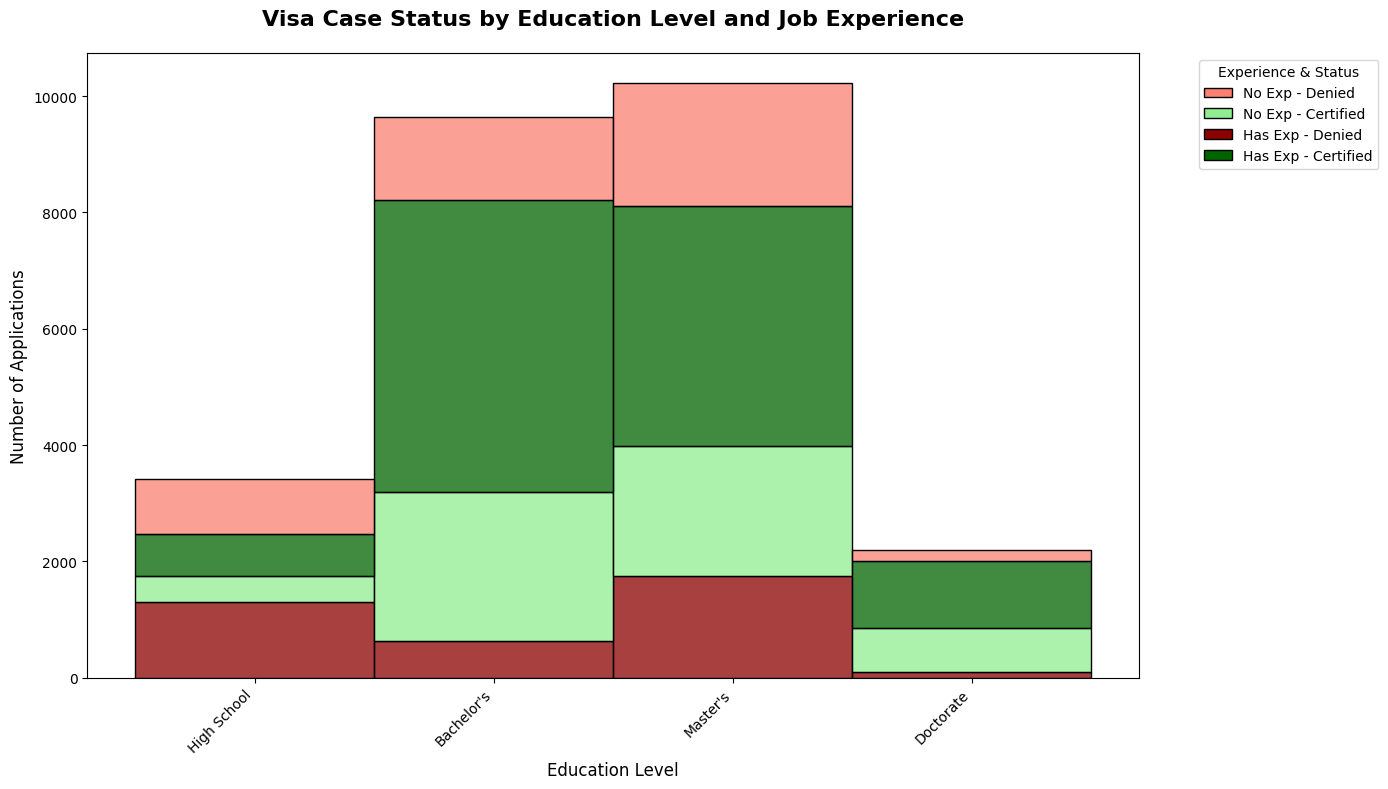

In [54]:
# Set the plot style
plt.figure(figsize=(14, 8))

# Create a custom hue by combining experience and status on the fly
custom_hue = df['has_job_experience'].astype(str) + '_' + df['case_status'].astype(str)

# Create the plot
ax = sns.histplot(
    data=df,
    x='education_of_employee',
    hue=custom_hue,
    multiple='stack',
    palette={
        '0_0': 'salmon',    # No Exp - Denied
        '0_1': 'lightgreen', # No Exp - Certified
        '1_0': 'darkred',   # Has Exp - Denied
        '1_1': 'darkgreen'  # Has Exp - Certified
    },
    edgecolor='black',
    stat='count'
)

# Format the plot
plt.title('Visa Case Status by Education Level and Job Experience', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Applications', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Manually set the order of x-axis
ax.set_xticks(range(4))
ax.set_xticklabels(['High School', 'Bachelor\'s', 'Master\'s', 'Doctorate'])

# Create custom legend with proper labels
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='salmon', edgecolor='black', label='No Exp - Denied'),
    Patch(facecolor='lightgreen', edgecolor='black', label='No Exp - Certified'),
    Patch(facecolor='darkred', edgecolor='black', label='Has Exp - Denied'),
    Patch(facecolor='darkgreen', edgecolor='black', label='Has Exp - Certified')
]
plt.legend(handles=legend_elements, title='Experience & Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Observations:**

***Best combination: Advanced Degree and Experience***

* Master's with Experience: Has the **most certified applications** (5,008).
* Doctorate with Experience has the **greatest certification rate** (1,158 / 1,251 = 92.6%).
* This combination provides the most favourable profile for visa clearance.


***Experience person with bachelor's degree***

* Without experience: **51.3%** certification rate (2,231 / 4,348).
* With experience: certification rate of 70.3% (4,136 / 5,886)
* For bachelor's degree holders, gaining experience enhances their **chances of acceptance by 19 percentage points**.


***High School Without Experience***

* This group has the **lowest certification rate** (31.7 percent, 442 / 1,396).
* It reflects the **most difficult profile for visa approval**.


***Even doctorates require experience***

* Without Experience: **80.1%** certification percentage (754/941)  - Good
* With experience: **92.6%** certification rate (1,158/1,251) - Excellent
* Experience still provides a considerable **12.5 percentage point advantage** for the highest degree of schooling.


***Experience Doesn't Fully Compensate for Low Education***

* High School with Experience still has a certification percentage of 35.7% (722 / 2,024).
* This is lower than the bachelor's without experience (51.3%).


**Insights:**

* Advanced Education levels & experience are key factors to determine of the person's visa is approved or rejected.  
* A doctorate with experience achieves 92.6%, whereas a doctorate without experience achieves "only" 80.1%.  
* Similarly, experience can assist a bachelor's degree holder advance from average (51.3%) to good (70.3%) prospects, but it cannot overcome the restrictions of a high school education.

##**Overall Insights from EDA Analysis**



***Education is the single most important factor***

* Higher education greatly improves approval chances.

* Doctorate holders have the best success rate (**87%**).

* High school graduates have the toughest odds (**34% approval**).

* Each increase in education level considerably boosts approval chances.


***Job experience provides a significant boost***

* Experienced applicants are **33% more likely to get approved**.

* Experience is most important for Bachelor's holders (19% point gain).

* Doctorate holders receive a 13% point boost from experience.

* The winning combo is advanced degrees + experience.


***Company stability outperforms company size (no_of_employees)***

* Company age does not impact much; new and old enterprises have similar approval percentages.

* Company size indicates only a modest advantage for larger companies.

* What counts more is the work type (full-time/annual wage vs. hourly).


**Job quality is more important than job location**

* Full-time, salaried positions have a significantly higher approval rate.

* Hourly wage approval is quite low (35%).

* The Midwest has the highest approval rate (76%), but disparities between areas are lower than other characteristics.


**The system promotes stable, professional employment**

* Yearly salaries are preferable to hourly earnings.

* Full-time opportunities are preferred.

* Professional experience is quite valuable.

* Advanced schooling is highly preferred.


***No single factor ensures success or failure***

* Even Doctorate holders get denied sometimes.

* Some high school grads still receive approval.

* The choice examines numerous aspects together to determine visa status.

***The best profile for visa approval:***

* Education: Doctorate or Master's degree.

* Experience: At least some work experience.

* Job Type: Full-Time, Salary Position

* Wage: meets or surpasses the prevailing wage.

* Region: Midwest or south areas have a minor edge.


***The most challenging profile:***

* Education: High school only.

* Experience: No work experience.

* Job Type: Hourly, Part-Time Position

* Wage: On the low end of the scale


**Conclusion:**

* **The EDA analysis shows a clear trend: the visa approval system is designed to certify educated, experienced professionals entering stable, well-compensated positions**.


#**DATA PROCESSING**

##**Data preparation**

**Let's convert all columns with dtype object into category**

In [55]:
# convert all columns with dtype object into category
for col in df.columns[df.dtypes=='object']:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  int64   
 3   requires_job_training  25480 non-null  int64   
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  category
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  category
 9   full_time_position     25480 non-null  int64   
 10  case_status            25480 non-null  int64   
dtypes: category(4), float64(1), int64(6)
memory usage: 1.5 MB


**Observations:**

* We can see object dtype has been successfully converted to the category dtype.
* has_job_experience, requires_job_training, full_time_position, case_status : these we already label encoded to binary features, including our target (case_status) variable successfully label encoded (converted from 'Y'/'N' to 1/0). Therefore, they are shown as int dtype.

##**Feature Engineering**

* We will not create any new features because:
 * The classifier models  we'll create can automatically detect the interactions and non-linear patterns we identified in the EDA.  
 * Adding new features will not make any significant impact and could hinder model generalisation.


##**Missing & Duplicate Values**

* There are no missing & duplicate values in our dataset as checked earlier in data overview section.
* Our data is clean to be used for model.

##**Outlier Detection & Treatment**

**Outlier Detection using Box Plot**

* Let's check outliers using box plot on continuous numerical columns only to prevent extreme values from unduly influencing the model's performance.
* We will not check outliers on label encoded columns as they are discrete values.

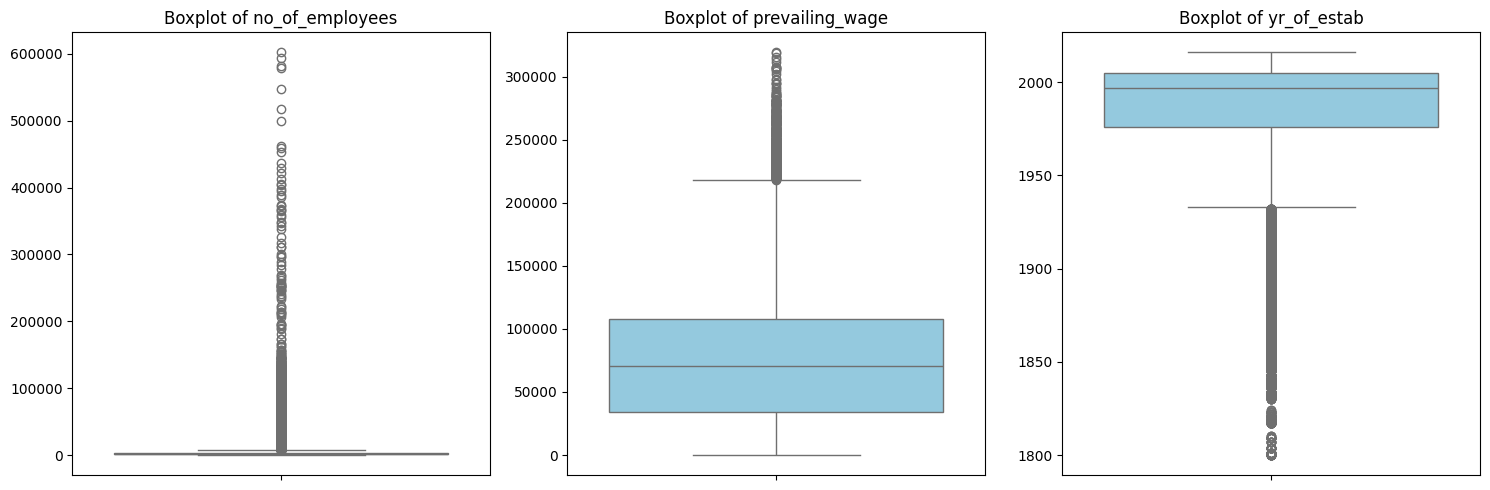

In [56]:
# List of numerical columns to check
num_cols = ['no_of_employees', 'prevailing_wage', 'yr_of_estab']

# Create boxplots
plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

**Observations:**

* The box plots shows there are several extreme outliers in all columns.
* We will further verify these outliers using IQR method.

**Outlier Verification using IQR method**

In [57]:
# Function to calculate IQR bounds
def find_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Check each column
for col in num_cols:
    lower_bound, upper_bound = find_iqr_bounds(df[col])
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}:")
    print(f"  Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {outlier_count} ({(outlier_count/len(df))*100:.2f}%)\n")

no_of_employees:
  Lower bound: -2701.00, Upper bound: 7227.00
  Number of outliers: 1556 (6.11%)

prevailing_wage:
  Lower bound: -76564.57, Upper bound: 218315.56
  Number of outliers: 427 (1.68%)

yr_of_estab:
  Lower bound: 1932.50, Upper bound: 2048.50
  Number of outliers: 3260 (12.79%)



**Observations:**

* There are many outliers in three columns : no_of_employees (6.11%) outliers, prevailing_wage (1.68%) and yr_of_estab (12.79%)
* We will see if we need to treat them or not.

**Outlier Treatment**

**We will not be treating any outliers because**:

* Companies that have much more employees (no_of_employees) than the average (for example, major organisations with tens or hundreds of thousands of people). Large, well-established businesses are frequently seen as more reliable and authentic, which may have a favourable impact on the certification decision.  This crucial signal would be lost if these values were removed or capped, which would stop the model from recognising the trend that applications from large companies had a higher chance of being verified.

* Wages are extremely high for specialised, in-demand occupations (e.g., senior surgeons, AI specialists) and very low for entry-level or part-time positions. A "speciality occupation," which is a crucial requirement for visa certification, is strongly indicated by exceptionally high earnings.  On the other hand, extremely low pay could be a good excuse for rejection.  The model's capacity to identify these essential linkages would be diminished if these extremes were capped.

* Companies established in the 1800s or very early 1900s ("legacy" or old companies). A company's age is a major indicator of its stability and repute.  A visa application from a century-old, well-established corporation is considered less risky than one from a fledgling startup.  Removing these past data points would reduce the model's capacity to use corporate stability as a predictor.

**EDA**

* It is a good idea to explore the data once again after manipulating it.
* However, we have not manipulated the data by treating outliers, filling null values or removing duplicates, we will not be re exploring the data.


##**Data Preparation for Modeling**  

* We already label encoded the categorical columns.

* **We will not be doing feature scaling** on the numerical predictors prior to model training because tree-based models are scale-invariant.

* We will create dummy variables of our independent categorical variables using **one-hot encoding**.

* Then, we'll **split the data into train, validation and test** to be able to evaluate the model that we build on the train data. This three split is done to **avoid any data-leakage**.

In [58]:
# we will first copy our df dataset to preserve it.
df1 = df.copy()


**Train-Validation-Test Split**

* **We will first we need to select our target (case_status) variable from the dataframe and separate it from the independent variables(predictors), then encode categorical variable and finally split the dataset.**

* **Splitting the data into train, validation and test set (60:20:20 ratio):**

   * X_train → 60% of feature data will be used to train the model.

   * X_val(validation set) → 20% of feature data will be used to tune hyperparameters & evaluate model's performance during development.

   * X_test → 20% of feature data will be used for final, unbiased test (evaluate) of model after all tuning is complete.

   * y_train → Target values for X_train.

   * y_val → Target values for X_val.

   * y_test → Target values for X_test.



In [59]:
# Define features (X) and target (y)
X = df1.drop('case_status', axis=1)  # Drop target
y = df1['case_status']  # Target variable

# List of categorical columns to one-hot encode
categorical_cols = ['continent', 'education_of_employee', 'region_of_employment', 'unit_of_wage']

# Step 1: One-Hot Encoding on the entire feature set (X)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_encoded = X_encoded.astype(int)

# Step 2: Split the encoded data into Train, Validation, and Test sets
# First, split off the TEST set (20% of the entire data)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Then split the temporary data into TRAIN and VALIDATION
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # test_size=0.25 on the Temp set → 25% of 80% = 20% Validation
    random_state=42,
    stratify=y_temp
)



In [60]:
X_encoded.head()

,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
0,0,0,14513,2007,592,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,1,0,2412,2002,83425,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
2,0,1,44444,2008,122996,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,0,98,1897,83434,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
4,1,0,1082,2005,149907,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1


In [61]:
# Check data types
print("\nData types:")
print(X_encoded.dtypes.value_counts())


Data types:
int64    21
Name: count, dtype: int64


**Observations:**

* We encoded our dummy variables successfully.

In [62]:
# Print the shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# Optional: Check the distribution of target variable in each set
print("\nTarget distribution in Training set:")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution in Validation set:")
print(y_val.value_counts(normalize=True))
print("\nTarget distribution in Test set:")
print(y_test.value_counts(normalize=True))

Training set shape: (15288, 21) (15288,)
Validation set shape: (5096, 21) (5096,)
Test set shape: (5096, 21) (5096,)

Target distribution in Training set:
case_status
1    0.667909
0    0.332091
Name: proportion, dtype: float64

Target distribution in Validation set:
case_status
1    0.667779
0    0.332221
Name: proportion, dtype: float64

Target distribution in Test set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64


**Observations:**

* Data is imbalanced with 2:1 ratio i.e. for every 2 certified cases, there is 1 denied case.
* There are no row-column mistamch in the split dataset, perfect aligmnet achieved after the split.
* We can proceed with model building.

#**MODEL BUILDING**

##**Model Evaluation Criteria**

**The model may make two types of inaccurate predictions:**

 * False Positive (Type I Error): The model predicts that the visa application will be certified when, in fact, it should be denied.

 * False Negative (Type II Error): The model predicts that the visa application will be denied, whereas in fact it should be certified.



**Both type of error  can lead to significant business consequences:**


***False Positives (Certified → Actually Denied):***

 * Improperly certified visas may replace qualified US workers.

 * Employers may hire less qualified foreign labour than qualified citizens.

 * Possible detrimental effect on domestic employment opportunities.

 * Violation of the Immigration and Nationality Act's worker protection clauses

***False Negatives (Denied to Certified):***

 * US firms are losing access to competent people that may contribute to economic growth.

 * Companies confront manpower shortages, which may harm competitiveness.

 * Missed possibilities for knowledge transfer and skill diversity.

 * Potential economic losses due to empty posts.


**Given the equal importance of both error types, we will use:**

* **F1-Score as Primary Metric**: The harmonic mean of precision and recall is a balanced assessment of both false positives and false negatives.  
* The F1-score emphasis with balanced class weights provides the best compromise between preventing unjustified certifications and ensuring competent applicants are not incorrectly denied.



**We will define a function to output different metrics (including F1) on the train, validation and test set (for final model) and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [63]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [64]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title("Confusion Matrix - Visa Certification Prediction")

    # Adding class labels for better interpretation
    tick_labels = ['Denied (0)', 'Certified (1)']
    plt.xticks(ticks=[0.5, 1.5], labels=tick_labels)
    plt.yticks(ticks=[0.5, 1.5], labels=tick_labels, rotation=0)

    plt.show()

##**Initial Model Building**

###**Decision Tree Initial Model Building**

**Decision Tree (DT) Model Building using Original Data**

In [65]:
# Let's build the decision tree

dtree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dtree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

* We have successfully build the initial decision tree model.

**Checking Initial Decision Tree Model's Performance on Train set**

In [66]:
# Evaluate
print("Training Performance-DT:")
dt_train_perf= model_performance_classification_sklearn(dtree, X_train, y_train)
dt_train_perf


Training Performance-DT:


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Training Set Performance Observations:**

* The model performed perfectly on the training data, with all metrics at **1.0**.

* This shows that the decision tree has entirely memorised the training patterns.

* Accuracy, recall, precision, and F1-score have all hit 100%.

* This level of performance indicates **severe overfitting** on the training data.



In [67]:
# Evaluate
print("Validation Performance-DT:")
dt_val_perf = model_performance_classification_sklearn(dtree, X_val, y_val)
dt_val_perf


Validation Performance-DT:


,Accuracy,Recall,Precision,F1
0,0.658752,0.744931,0.744275,0.744603


**Validation Set Performance Observations:**

* Performance decreased dramatically to **65.88% accuracy** on validation data.

* The **F1 score of 74.46% shows moderate performance** on unseen data.

* A **recall of 74.49%** indicates that the model accurately detects three out of four actual certifications.

* The precision of **74.43%** shows that three out of four predicted certifications are correct.

* The 26% decrease in performance from training to validation verifies overfitting.

**Confusion Matrix Plot for Initial Decision Tree model**

Confusion Matrix-DT (Train):


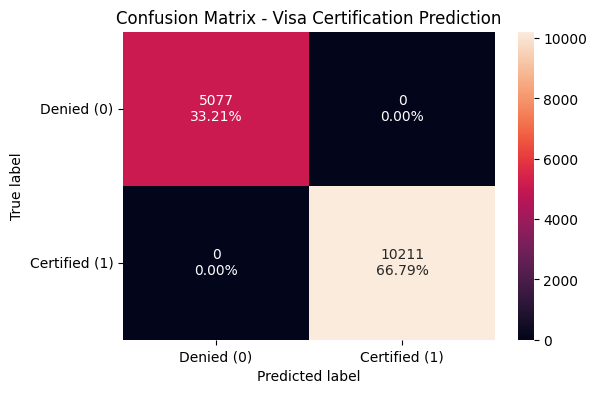

In [68]:
print("Confusion Matrix-DT (Train):")
confusion_matrix_sklearn(dtree, X_train, y_train)

**Training Set Confusion Matrix Observations:**

* The model made no errors in the training set.

* All **15,288** cases were accurately classified.

* 5,077 denials and 10,211 certificates were predicted correctly.

* This precise separation is typical of decision trees without constraints.



Confusion Matrix-DT(Validation):


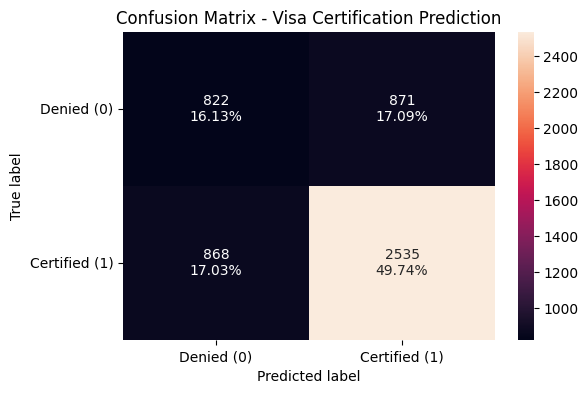

In [69]:
print("Confusion Matrix-DT(Validation):")
confusion_matrix_sklearn(dtree, X_val, y_val)

**Validation Set Confusion Matrix Observation:**

* The model demonstrates reasonable but **inadequate performance on validation data**.

* Correct predictions: The majority of cases (**about 74%**) are correctly classified.

* Error patterns: Both false positives and false negatives are prevalent, **1,732 cases (861 FP + 871 FN)**.

* There are **861 potentially unqualified applicants** who might receive certification, while there are **871 qualified applicants** might be incorrectly denied visas.



###**Bagging Classifier Initial Model Building**

####**Random Forest**

In [70]:
# Let's build the bagging-Random Forest model

bagging_rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced')
bagging_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

**Checking Initial Bagging (Random Forest) Model's Performance on Train set**

In [71]:
# Evaluate
print("Training Performance-RF:")
rf_tain_perf = model_performance_classification_sklearn(bagging_rf, X_train, y_train)
rf_tain_perf


Training Performance-RF:


,Accuracy,Recall,Precision,F1
0,0.999935,1.0,0.999902,0.999951


**Training Performance Analysis:**

* The model's performance on the training set is unrealistically perfect, sign of high overfitting.

* ***Accuracy: ~99.99%***: The model accurately predicted almost all cases in the training data.

* ***The recall of 1.0 and precision of ~0.9999***.  This signifies that the model made nearly no errors in recognising "Denied" applications during training.  The algorithm detected all denials (Recall=1.0) and accurately predicted "Denied" in virtually all cases (Precision~1.0).

**Conclusion:**
* The model's nearly flawless performance indicates that it has overfitted the training data.
* It has overlearned the specific patterns and noise in the training set, making it less adaptive to new data.

In [72]:
# Evaluate
print("Validation Performance-RF:")
rf_val_perf = model_performance_classification_sklearn(bagging_rf, X_val, y_val)
rf_val_perf



Validation Performance-RF:


,Accuracy,Recall,Precision,F1
0,0.725275,0.851895,0.7639,0.805502


**Validation Performance Analysis:**

* The performance declines considerably on the validation set, confirming the overfitting observed during the training phase.

* ***Accuracy: ~72.5%***: The model accurately predicts the outcome in around 7 out of 10 applications.  This is a considerable decline from 99.99%, indicating overfitting.

* The ***recall is 0.852***.  This is the most significant positive metric.  This means that the model correctly identifies 85.2% of all truly fraudulent or problematic ("Denied") applications.  This is adequate for an initial model, as capturing denials is frequently a crucial.

* The ***precision is 0.764***.  This means that only **76.4%** of the applications predicted by the model as "Denied" were really denied.  The remaining 23.6% were false alarms (false positives), which means that legitimate applications were mistakenly identified for rejection.  This could result in unnecessary manual scrutiny and applicant unhappiness.

* ***F1-Score (0.806)***: The harmonic mean of Precision and Recall yields a single score for the "Denied" class' performance.  A score of 0.806 is acceptable, but there is space for growth, particularly on the Precision side.

**Confusion matrix of bagging initial model**

Confusion Matrix-RF (Train):


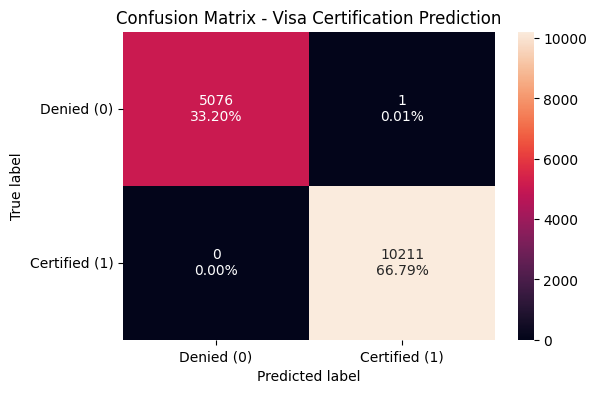

In [73]:
print("Confusion Matrix-RF (Train):")
confusion_matrix_sklearn(bagging_rf, X_train, y_train)

**Training Confusion Matrix:**

* There were **10,211** applications were successfully forecasted as Certified (true positives).

* Approximately **5076** applications were accurately forecasted as denied (True Negatives).

* Only one application was inaccurately forecasted as Certified when it was actually Denied (false negative).

* 0 applications were incorrectly classified as denied when they were really certified (False Positive).


Confusion Matrix-RF (Validation):


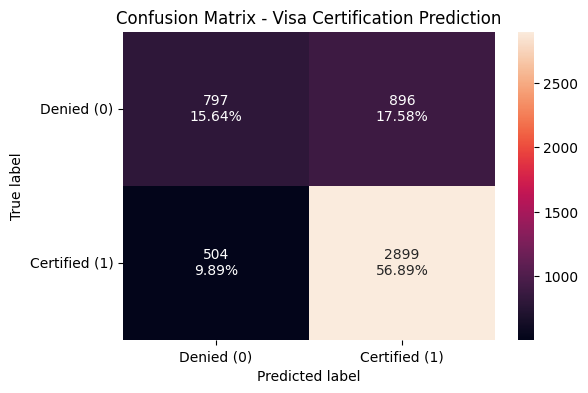

In [74]:
print("Confusion Matrix-RF (Validation):")
confusion_matrix_sklearn(bagging_rf, X_val, y_val)

**Validation Confusion Matrix Observations:**

* ***Correct predictions:***

 * **2,899** applications were correctly forecasted as Certified (true positives).

 * **797** applications were accurately predicted as Denied (true negatives).

* ***Incorrect predictions:***

 * **896** applications were wrongly classified as Certified when they were really denied (False Negatives).

 * **4307** applications were wrongly classified as denied when they were really certified (False Positives).  


###**Boosting Initial Model Building**

####**AdaBoost Initial Model Building**

In [75]:
ada_boost = AdaBoostClassifier(random_state=42)
ada_boost.fit(X_train,y_train)

AdaBoostClassifier(random_state=42)

**Checking Performance of Adaboost model**

In [76]:
#train set performance
print("Training Performance-Adaboost:")
ada_train_perf = model_performance_classification_sklearn(ada_boost, X_train, y_train)
ada_train_perf

Training Performance-Adaboost:


,Accuracy,Recall,Precision,F1
0,0.741627,0.883851,0.765544,0.820455


**Training Performance Observations:**

* ***Accuracy (0.741):*** The model has a high level of accuracy, which means it accurately classifies a large portion of the training data.

* ***Recall (0.883):*** A high recall indicates that the model is excellent at detecting positive instances while minimising false negatives.

* ***Precision (0.765):*** The precision score suggests a decent mix of true and false positives, but there is still space for improvement.

* ***F1 Score (0.820):*** The F1 score represents a good mix of precision and recall, indicating that the model performs well overall.

In [77]:
#validation set performance
print("Validation Performance-Adaboost:")
ada_val_perf = model_performance_classification_sklearn(ada_boost, X_val, y_val)
ada_val_perf


Validation Performance-Adaboost:


,Accuracy,Recall,Precision,F1
0,0.738226,0.891566,0.75869,0.819778


**Validation Performance Observations:**

* ***Accuracy (0.7382):*** The accuracy on the validation set is slightly lower than the training accuracy, which could indicate overfitting.

* ***Recall (0.8915):*** The recall remained strong, comparable to the training set, indicating consistent performance in detecting good instances.

* ***Precision (0.75869):*** Precision is slightly lower than in training, indicating a minor rise in false positives during validation.

* ***F1 Score (0.819778):*** The F1 score is similar to the training score, indicating that the model strikes a fair balance between precision and recall on unseen data.

**Confusion matrix of adaboost initial model**

Confusion Matrix-Adaboost (Train):


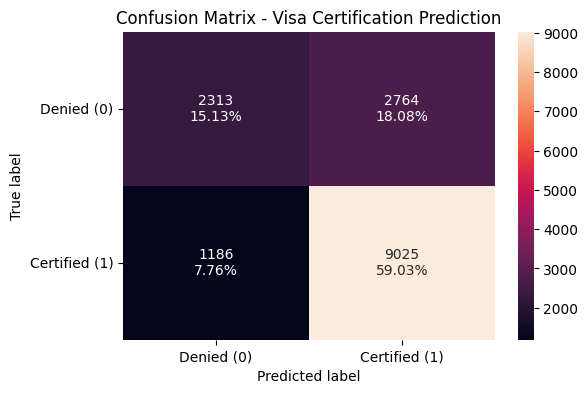

In [78]:
print("Confusion Matrix-Adaboost (Train):")
confusion_matrix_sklearn(ada_boost, X_train, y_train)

**Training Set Confusion Matrix Observations:**

***Correct predictions:***

 * Certified visas accurately predicted (**TP**): **9025** (59.03%).

 * Denied visas accurately predicted (**TN**): **2313** (~15.13%).

***Incorrect predictions:***

 * Certified predicted as denied (**FN**): **1186** (approx. 7.76%)

 * Denied predicted as Certified (**FP**): **2764** (~18.08%).

**Conclusions:**

* The model performs better at recognising certified visas than refused visas.

* False Positives (18%) are relatively high, showing that the model occasionally incorrectly labels refused instances as certified.

* There are no notable evidence of overfitting based on train-validation accuracy similarity.

Confusion Matrix-Adaboost(Validation):


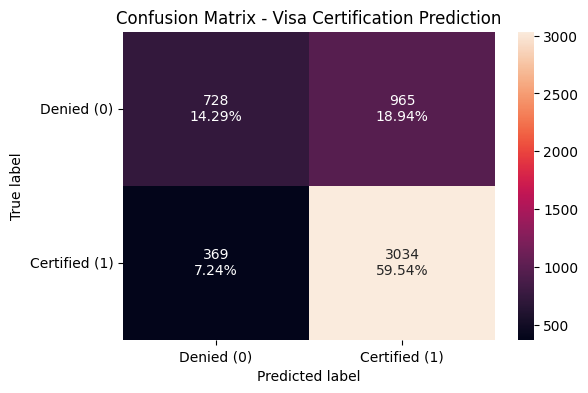

In [79]:
print("Confusion Matrix-Adaboost(Validation):")
confusion_matrix_sklearn(ada_boost, X_val, y_val)

**Validation Set Confusion Matrix Observations:**

***Correct predictions:***

* Certified visas accurately predicted (**TP**): **3034** (59.54%).

* Denied visas correctly predicted (**TN**): **728** (14.29%).

***Incorrect predictions:***

* Certified predicted as denied (**FN**): **369** (~7.24%).

* Denied predicted as Certified (**FP**): **965** (~18.94%)


**Conclusions:**

* Performance is consistent with the training set, showing high generalisability.

* The model continues to predict certified cases better than refused instances.

* The false positive rate is slightly higher ~(19%) than the false negative rate ~(7%), indicating that some denied candidates are incorrectly reported as certified.

####**Gradient Boost Initial Model Building**

In [80]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

**Checking Performance of Gradient Boosting Initial Model**

In [81]:
# Train-set Performance of Gradient Boosting Initial Model
print("Training Performance-Gradient Boosting Model:")
gb_train_perf = model_performance_classification_sklearn(gb_model, X_train, y_train)
gb_train_perf


Training Performance-Gradient Boosting Model:


,Accuracy,Recall,Precision,F1
0,0.759812,0.880129,0.78592,0.830361


**Training Performance Observations for the Gradient Boosting Model:**

* ***Accuracy (0.7598):*** The model obtains a high accuracy on the training set, indicating that the training data is properly classified.

* ***Recall (0.8801):*** The recall score is high, indicating that the model is good at detecting positive cases and has a low rate of false negatives.

* ***Precision (0.7859):*** The precision shows a good ratio of true positives to false positives, but there is still room for improvement.

* ***F1 Score (0.8303):*** The F1 score represents a good balance of precision and recall, showing that the model performs well during training.

In [82]:
# Validation-set Performance of Gradient Boosting Initial Model
print("Validation Performance-Gradient Boosting Model:")
gb_val_perf = model_performance_classification_sklearn(gb_model, X_val, y_val)
gb_val_perf


Validation Performance-Gradient Boosting Model:


,Accuracy,Recall,Precision,F1
0,0.748823,0.878636,0.775214,0.823691


**Validation Performance Observations for the Gradient Boosting Model:**

* ***Accuracy (0.7488):*** The validation set has slightly lower accuracy than the training set, which could indicate some degree of overfitting.

* ***Recall (0.8786):*** The recall is still high, similar to the training performance, demonstrating consistent effectiveness in identifying the  positive cases.

* ***Precision (0.7752):*** Precision is slightly lower than in training, indicating a small rise in false positives during validation.

* ***F1 Score (0.8236):*** The F1 score is similar to the training score, indicating that the model retains a solid balance of precision and recall when tested on unseen data.

**Confusion Matrix of Gradient Boosting Initial Model**

Confusion Matrix-Gradient Boosting(Train):


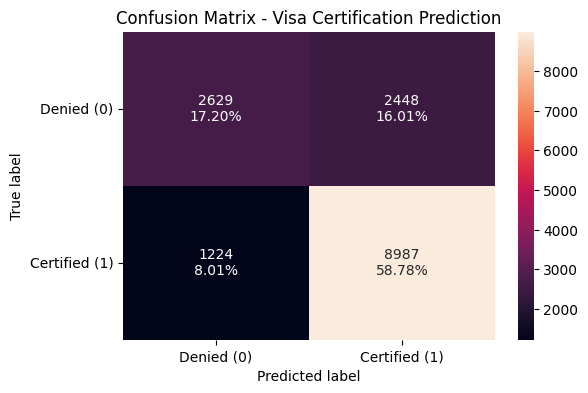

In [83]:
print("Confusion Matrix-Gradient Boosting(Train):")
confusion_matrix_sklearn(gb_model, X_train, y_train)

**Confusion Matrix Observations on the Training Set-Gradient Boosting:**

***Correct predictions:***

* Certified visas accurately predicted (**TP**): **8,987** (58.78%).

* Denied visas correctly predicted (**TN**): **2,629** (17.20%).

***Incorrect predictions:***

* Certified predicted as denied (**FN**): **1,224** (8.01%).

* Denied predicted as Certified (**FP**): **2,448** (~16.01%)


**Conclusions:**

* The model predicts certified cases better than refused cases.

* False positives (~16%) remain a concern, indicating that some disallowed applications are incorrectly represented as certified.

* Balanced performance with no signs of overfitting (error distribution is stable).

Confusion Matrix-Gradient Boosting(Validation):


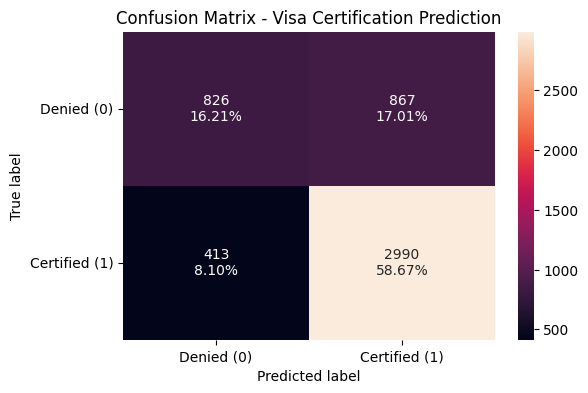

In [84]:
print("Confusion Matrix-Gradient Boosting(Validation):")
confusion_matrix_sklearn(gb_model, X_val, y_val)

**Confusion Matrix Observations on the Validation Set - Gradient Boosting:**

***Correct predictions:***

* Certified visas correctly predicted (**TP**): **2,990** (~58.67%).

* Denied visas accurately predicted (**TN**): **826** (~16.21%)


***Incorrect predictions:***

* Certified predicted as denied (**FN**): **413** (~8.10%).

* Denied predicted as Certified (**FP**): **867** (17.01%).


**Conclusions:**

* Validation performance roughly corresponds to training outcomes, showing strong generalisation.

* The model accurately identifies certified cases, but misclassifies approximately 17% of denied cases.

* The low false negative rate (~8%) helps prevent promising candidates from being wrongfully denied.

####**XGBoost Initial Model Building**

In [85]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

**Checking Performace of XGBoost Initial Model**

In [86]:
print("Training Performance-XGBoost:")
xgb_train_perf = model_performance_classification_sklearn(xgb_model, X_train, y_train)
xgb_train_perf

Training Performance-XGBoost:


,Accuracy,Recall,Precision,F1
0,0.851583,0.934091,0.856655,0.893699


**Training Performance Observations for XGBoost:**

* ***Accuracy (0.8515):*** The model performs well on the training set, indicating that it can classify a significant amount of the training data.

* ***Recall (0.9340):*** The recall score is quite high, indicating that the model excels at identifying positive cases, resulting in a low rate of false negatives.

* ***Precision (0.8566):*** The precision score reflects a high ratio of true positives to false positives, indicating that the model is reliable in making positive predictions.

* ***F1 Score (0.8936):*** The F1 score shows a good balance of precision and recall, indicating that the model performs very well during the training phase.

In [87]:
print("Validation Performance-XGBoost:")
xgb_val_perf = model_performance_classification_sklearn(xgb_model, X_val, y_val)
xgb_val_perf


Validation Performance-XGBoost:


,Accuracy,Recall,Precision,F1
0,0.731947,0.859242,0.767253,0.810646


**Validation and Performance Observations for XGBoost:**

* ***Accuracy (0.7319):*** The accuracy on the validation set is much lower than that on the training set, which could imply overfitting, as the model performs well on training data but poorly on unknown data.

* ***Recall (0.8592):*** The recall remains quite high, although lower than the training recall, indicating that the model is still effective at identifying positive cases but has a greater percentage of false negatives than training.

* ***Precision (0.7672):*** The precision score is lower than in training, indicating that false positives increased during validation, potentially affecting the model's reliability in practical applications.

* The ***F1 score (0.8106)*** is lower than the training value, indicating a decline in the balance of precision and recall when tested on unknown data.

**Confusion Matrix of XGBoost Initial Model**

Training Confusion Matrix-XGBoost:


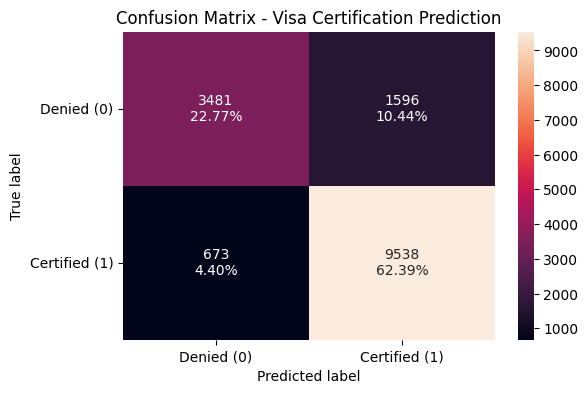

In [88]:
print("Training Confusion Matrix-XGBoost:")
confusion_matrix_sklearn(xgb_model, X_train, y_train)



**Observations of Confusion Matrix on Training Set-XGBoost:**

***Correct predictions:***

* Certified visas accurately predicted (**TP**): **9,538** (about 62.39%).

* Denied visas correctly predicted (**TN**): **3,481** (22.77%).

***Incorrect predictions:***

* Certified predicted as denied (**FN**): **673** (~4.40%).

* Denied predicted as Certified (FP): **1,596** (~10.44%).


**Conclusions:**

* The model achieves good accuracy in both classes, particularly in certified cases (~62%).

* The low false negative rate (~4%) indicates that it rarely misses certified applications.

* Training performance is quite robust, somewhat higher than validation, indicating some overfitting but it remains within a reasonable range.

Validation Confusion Matrix-XGBoost:


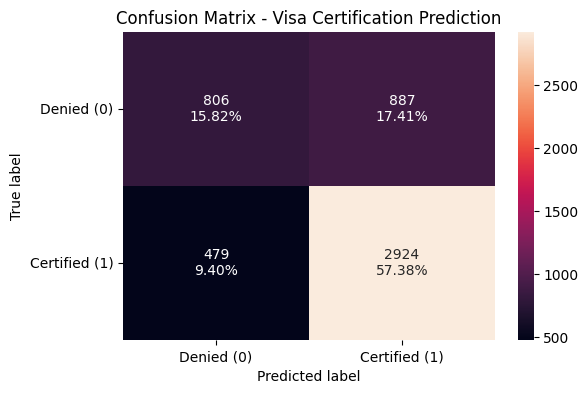

In [89]:
print("Validation Confusion Matrix-XGBoost:")
confusion_matrix_sklearn(xgb_model, X_val, y_val)

**Observations of Confusion Matrix on Validation Set -XGBoost:**

***Correct Predictions:***

* Certified visas correctly predicted (**TP**): **2,924** (~57.38%)

* Denied visas correctly predicted (**TN**): **806** (~15.82%)

***Incorrect Predictions:***

* Certified predicted as Denied (**FN**): **479** (~9.40%)

* Denied predicted as
Certified (**FP**): **887** (~17.41%)


**Conclusions:**

* Slight drop in performance compared to the training set, indicating some overfitting.

* Higher false negatives ~(9%) and false positives ~(17%) on validation compared to train, but performance is still solid.

* Model Retains a good ability to correctly predict certified cases, making it useful in practical scenarios where missing genuine certified cases is costly.

#**MODEL BUILDING - OVERSAMPLED DATA**

**Oversampling is used in model building to address class imbalance by increasing the representation of minority class. We will be using SMOTE (Synthetic Minority Oversampling Technique) to perform oversampling.**

**Checking class distribution before oversampling**

In [90]:
# Checking class distribution before oversampling
print("Before Oversampling:")
print("Counts of label 'Denied': {}".format(sum(y_train == 0)))
print("Counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Proportions: {:.2f}% Denied, {:.2f}% Certified\n".format(
    sum(y_train == 0)/len(y_train)*100,
    sum(y_train == 1)/len(y_train)*100
))

Before Oversampling:
Counts of label 'Denied': 5077
Counts of label 'Certified': 10211
Proportions: 33.21% Denied, 66.79% Certified



**Observations:**

* **Before oversampling**, the dataset has a **significant imbalance** between the two labels, 'Denied' and 'Certified'.  Specifically, there are:

* **5077** instances of '**Denied**' (33.21%) and **10211** instances of '**Certified**' (66.79%).  

* To overcome these issues, oversampling (**SMOTE-Synthetic Minority Oversampling Technique**) approaches will be used to balance the class distribution, allowing the model to learn more effectively from both classes while improving overall prediction performance.

In [91]:
# Applying SMOTE oversampling
from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42) #k=5
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


**Note: To ensure that validation and test data truly reflect real-world distributions, no oversampling is performed on validation and test sets.  This enables for a fair evaluation of the model's performance on unseen data while avoiding any bias caused by artificially inflating the minority class.**

**Checking class distribution after oversampling**

In [92]:
# Check class distribution after oversampling
print("After Oversampling:")
print("Counts of label 'Denied': {}".format(sum(y_train_over == 0)))
print("Counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("Proportions: {:.2f}% Denied, {:.2f}% Certified\n".format(
    sum(y_train_over == 0)/len(y_train_over)*100,
    sum(y_train_over == 1)/len(y_train_over)*100
))

print("After Oversampling, shape of X_train: {}".format(X_train_over.shape))
print("After Oversampling, shape of y_train: {}".format(y_train_over.shape))


After Oversampling:
Counts of label 'Denied': 10211
Counts of label 'Certified': 10211
Proportions: 50.00% Denied, 50.00% Certified

After Oversampling, shape of X_train: (20422, 21)
After Oversampling, shape of y_train: (20422,)


**Observations:**

* After applying oversampling, the dataset now has a balanced class distribution between the two labels, 'Denied' and 'Certified'.  Specifically, there are:

  * 10211 instances of '**Denied**' (**50%**)
  * 10211 instances of '**Certified**' (**50%**).

* The shapes of the training features (X_train) and labels (y_train) show that the dataset was **successfully expanded to contain a total of 20,422 instances and 21 features**.  

* This is an excellent result because it demonstrates that the oversampling procedure efficiently **increased the number of examples for the minority class while preserving all information**.

##**Decision Tree Model Building using Oversampled Data**

In [93]:
# Initialize and train
dt_model_over = DecisionTreeClassifier(random_state=42)
dt_model_over.fit(X_train_over, y_train_over)

DecisionTreeClassifier(random_state=42)

**Checking Performance of Decision Tree-oversampled Model**

In [94]:
# Training performance (on oversampled data)
print("TRAINING PERFORMANCE-DT (Oversampled Data):")
dt_train_perf_over = model_performance_classification_sklearn(dt_model_over, X_train_over, y_train_over)
dt_train_perf_over

TRAINING PERFORMANCE-DT (Oversampled Data):


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Training Performance Observations for Decision Tree Model (Oversampled Data):**

* ***Accuracy (1.0):*** The model achieves complete accuracy on the training set, which means it correctly classifies all instances.  However, this could indicate overfitting, as the model may have memorised the training data instead of learning generalisable patterns.

* ***Recall (1.0):*** A recall of 1.0 shows that the model correctly recognises all positive cases in the training data, demonstrating its ability to capture all instances of the minority class.

* ***Precision (1.0):*** A perfect precision score indicates that all of the model's positive predictions are true positives, with no false positives in the training set.

* ***F1 Score (1.0):*** An F1 score of 1.0 indicates an optimum balance of precision and recall, indicating that the model performs extraordinarily well on oversampled training data.

* These perfect result are due to synthetic data and do not reflect real-world performance.


In [95]:
# Validation performance (on original validation data)
print("VALIDATION PERFORMANCE-DT (Original Validation Data):")
dt_val_perf_over = model_performance_classification_sklearn(dt_model_over, X_val, y_val)
dt_val_perf_over

VALIDATION PERFORMANCE-DT (Original Validation Data):


,Accuracy,Recall,Precision,F1
0,0.658163,0.733764,0.749175,0.74139


**Validation Performance Observations for Decision Tree Model (Original Validation Data):**

* ***Accuracy (0.6581):*** The validation set's accuracy is much lower than that of the training set, indicating that the model may not generalise effectively to new data, which is a common problem when overfitting occurs.

* ***Recall (0.7337):*** The recall score is moderate, indicating that the model correctly identifies a majority of the positive class in the validation set, but there is still room for improvement.

* ***Precision (0.7491):*** The precision score indicates that, while the model makes an acceptable number of correct positive predictions, there are some false positives, indicating a decrease in reliability when compared to the training data.

* ***F1 Score (0.7413):*** The F1 score is lower than in the training data, indicating a shift in the balance of precision and recall as compared to the original validation data.

**Confusion Matrix on Decision tree Model with Oversampled Data**

TRAINING CONFUSION MATRIX-DT(Oversampled Data):


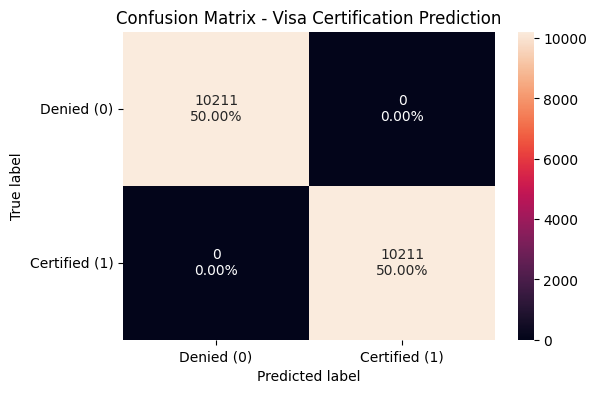

In [96]:
print("TRAINING CONFUSION MATRIX-DT(Oversampled Data):")
confusion_matrix_sklearn(dt_model_over, X_train_over, y_train_over)



**Observations on the Confusion Matrix of the Training Set Decision Tree (Oversampled Data):**

* The model demonstrates perfect classification. This result is artifically infalted due to use of SMOTE and do not reflect real-world performance.

* ***True Negatives (TN):*** **10,211** (all denied visas were correctly anticipated).

* ***True Positives (TP):*** **10,211** (all certified visas were correctly predicted).

* ***No false negatives (FN) or false positives (FP)***.

* Accuracy, precision, recall, and F1-score are all 100% on the training data.

* This indicates that the model overfits substantially to the oversampled training data.



VALIDATION CONFUSION MATRIX-DT(Original Validation Data):


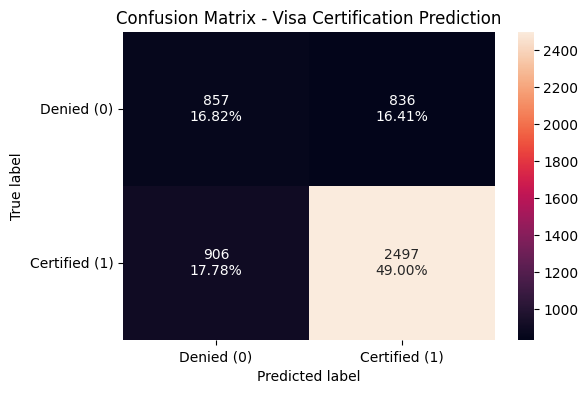

In [97]:
print("VALIDATION CONFUSION MATRIX-DT(Original Validation Data):")
confusion_matrix_sklearn(dt_model_over, X_val, y_val)

**Observations on the Confusion Matrix of Validation Set-Decision Tree (Oversampled Data):**

* Performance is significantly lower than training, indicating overfitting.

* ***True Negatives (TN):***  **857** (properly predicted refused instances ~16.8%).

* ***True Positives (TP):*** **2,497** (about 49% of certified cases were correctly predicted).

* ***False Negatives (FN)*** totalled **906**, with approximately 17.8% of certified cases being incorrectly predicted as denied.

* ***False Positives (FP)*** = **836** (denied cases incorrectly predicted as certified, ~16.4%).

* The model is better at predicting certified visas (class 1) than denied visas, but it still have issues with balanced generalisation.

##**Bagging (Randon Forest) Model Building using Oversampled Data**

In [98]:
# Initialize and train model
rf_model_over = RandomForestClassifier(random_state=42)
rf_model_over.fit(X_train_over, y_train_over)

RandomForestClassifier(random_state=42)

**Checking Performance of Random Forest-oversampled Model**

In [99]:
# Training performance (on oversampled data)
print("Training Performance-RF(Oversampled Data):")
rf_train_perf_over = model_performance_classification_sklearn(rf_model_over, X_train_over, y_train_over)
rf_train_perf_over

Training Performance-RF(Oversampled Data):


,Accuracy,Recall,Precision,F1
0,0.999951,1.0,0.999902,0.999951


**Random Forest Training Performance (oversampled data):**

* ***Accuracy: 0.99995***  The model obtains an extremely high accuracy of roughly 99.9951% on the training set, indicating great performance but causing overfitting.

* ***Recall (1.0):*** A perfect recall score of 1.0 means that the model correctly identified every case of the majority class ('Certified') in the training data.

* ***Precision (0.999902):*** The precision score is quite high, at 99.9902%, indicating that almost all positive predictions provided by the model are true positives.

* ***F1 Score (0.999951):*** The F1 score, which balances precision and recall, is also very high at around 99.99%, suggesting remarkable performance in both categories.

In [100]:
# Validation performance (on original validation data)
print("Validation Performance-RF (Original Validation Data):")
rf_val_perf_over = model_performance_classification_sklearn(rf_model_over, X_val, y_val)
rf_val_perf_over

Validation Performance-RF (Original Validation Data):


,Accuracy,Recall,Precision,F1
0,0.717033,0.811637,0.775189,0.792995


**Validation Performance of Random Forest (Original Data):**

* ***Accuracy (0.717033):*** The accuracy on the validation set is substantially lower, at around 71.70%, demonstrating that the model struggles to generalise to unseen data.

* ***Recall (0.811637):*** The recall score of roughly 81.16% indicates that the model correctly detects a significant number of the positive cases ('Certified') in the validation set, but there is still room for improvement.

* ***Precision (0.775189):*** A precision score of 77.52% suggests that, while the model makes a decent percentage of correct positive predictions, there are some false positives.

* ***F1 Score (0.792995):*** When compared to the original validation data, the F1 score of around 79.30% reveals a decline in the balance of accuracy and recall, indicating that the model's performance is not as robust as it was during training, as training data was oversampled.

**Confusion Matrix of Random Forest Model with Oversampled Data**

Training Confusion Matrix - RF (Oversampled Data):


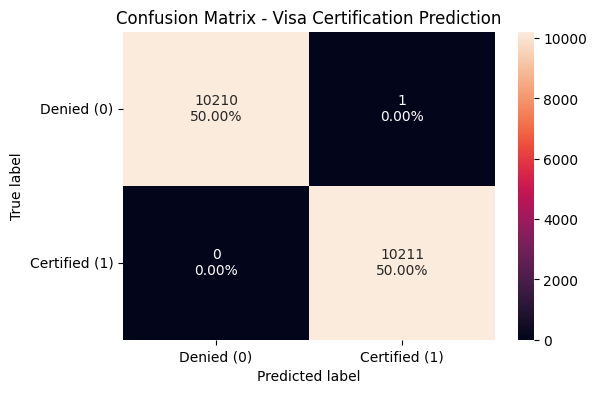

In [101]:
# Confusion matrix
print("Training Confusion Matrix - RF (Oversampled Data):")
confusion_matrix_sklearn(rf_model_over, X_train_over, y_train_over)

**Observations for Training Set Confusion Matrix - Random Forest (Oversampled data):**

* ***True Negatives (10210):*** The model accurately predicted 10,210 instances of 'Denied' (true negatives), accounting for 50% of the training set.  This demonstrates that the model is quite good at recognising the negative class in the training data.

* ***False Positives (1):*** There was just one instance when the model predicted 'Certified' when the correct label was 'Denied' (false positive).  This is a very low rate, indicating that the model's predictions for the 'Denied' class are quite accurate.

* ***False Negatives (0):*** The model classified no occurrences of 'Certified' as 'Denied' (false negatives), showing flawless recall for the minority class in the training set.

* ***True Positives (10211):***  The model accurately predicted 10,211 instances of 'Certified' (true positives), accounting for 50% of the training set.  This demonstrates the model's high effectiveness in identifying the positive class.

* These good results are due to addition of synthetic data by SMOTE technique.

Validation Confusion Matrix - RF (Original Validation Data):


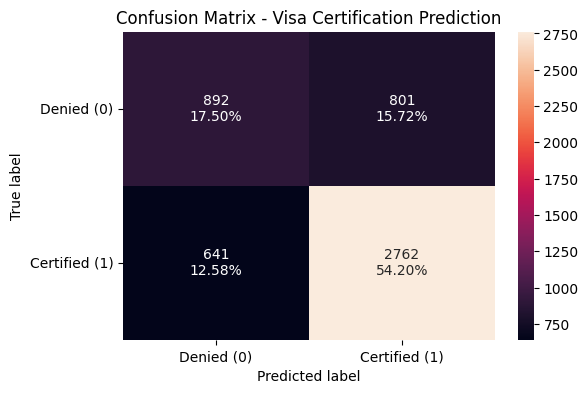

In [102]:
print("Validation Confusion Matrix - RF (Original Validation Data):")
confusion_matrix_sklearn(rf_model_over, X_val, y_val)


**Observations for Validation Set Confusion Matrix - Random Forest (Original data):**

* ***True Negatives (892):*** The model accurately predicted 892 instances of 'Denied' (true negatives), accounting for 17.50% of the validation set.  This shows a considerable reduction in performance when compared to the training set.

* ***False Positives (801):*** The model misclassified 801 cases as 'Certified' when they were actually 'Denied' (false positives), accounting for 15.72% of the validation set.  This shows that the model is unable to appropriately classify the majority of unseen data.

* ***False Negatives (641):*** The model misclassified 641 instances of 'Certified' as 'Denied' (false negatives), or 12.58% of the validation set.  This shows a significant decline in recall for the majority class compared to the training set.

* ***True Positives (2,762):*** The model correctly predicted 2,762 instances of 'Certified' (true positives), representing 54.20% of the validation set.  While this is somewhat effective in identifying the majority class, it falls short of the training performance.

##**Boosting Model Building using Oversampled Data**

###**AdaBoost - Oversampled Data**

In [103]:
# Initialize and train
ada_model_over = AdaBoostClassifier(random_state=42)
ada_model_over.fit(X_train_over, y_train_over)


AdaBoostClassifier(random_state=42)

**Checking Performance of AdaBoost-Oversampled Model**

In [104]:
# Training performance (on oversampled data)
print("Training Performance-AdaBoost (Oversampled Data):")
ada_train_perf_over = model_performance_classification_sklearn(ada_model_over, X_train_over, y_train_over)
ada_train_perf_over

Training Performance-AdaBoost (Oversampled Data):


,Accuracy,Recall,Precision,F1
0,0.769317,0.764959,0.771685,0.768308


**Observations for Training Performance of AdaBoost (Oversampled Data):**

* ***Accuracy (0.7693):*** The model achieves an accuracy of ~76.93% on the training set. While this is reasonable performance, it is much lower than the accuracy obtained with the Random Forest model on the identical oversampled data, implying that AdaBoost may not be capturing data patterns as well.

* ***Recall (0.7649):*** The recall score of about 76.50% indicates that the model correctly recognises 76.50% of the real positive cases ('Certified') in the training set.  This suggests that there is still opportunity for improvement in identifying all positive cases.

* ***Precision (0.7716):*** A precision score of 77.17% shows that about 77.17% of the instances predicted as 'Certified' are true positives.  This shows that the model's positive predictions are generally reliable, but there are some false positives.

* ***F1 Score (0.7683):*** The F1 score of around 76.83% represents a balance between precision and recall, showing that the model performs sufficiently but not as well as the Random Forest model.  This shows that, while the model is useful, there is room for additional improvement.

In [105]:
# Validation performance (on original validation data)
print("Validation Performance-AdaBoost (Original Data):")
ada_val_perf_over = model_performance_classification_sklearn(ada_model_over, X_val, y_val)
ada_val_perf_over

Validation Performance-AdaBoost (Original Data):


,Accuracy,Recall,Precision,F1
0,0.699765,0.771966,0.776989,0.774469


**Observations for Validation Performance of AdaBoost (Original Data):**

* ***Accuracy (0.699765):*** The validation set has an accuracy of about 69.98%, which is lower than the training accuracy.  This implies that the model is having difficulty generalising to previously unseen data.

* ***Recall (0.771966):*** The recall score of about 77.20% indicates that the model correctly recognises a significant proportion of the positive cases ('Certified') in the validation set.  This is a good trait, indicating that the model is reasonably effective at detecting positive cases.

* ***Precision (0.776989):*** A precision score of around 77.70% suggests that the model's positive predictions are reasonably dependable, with a high proportion of genuine positives among predicted positives.  However, there are still some false positives.

* ***F1 Score (0.774469):*** The F1 score of approximately 77.45% shows a balanced performance between precision and recall, indicating that the model is performing adequately on the validation set, but there is still room for improvement.



**Confusion Matrix of Adaboost Model with Oversampled Data**

TRAINING CONFUSION MATRIX-AdaBoost(Oversampled Data):


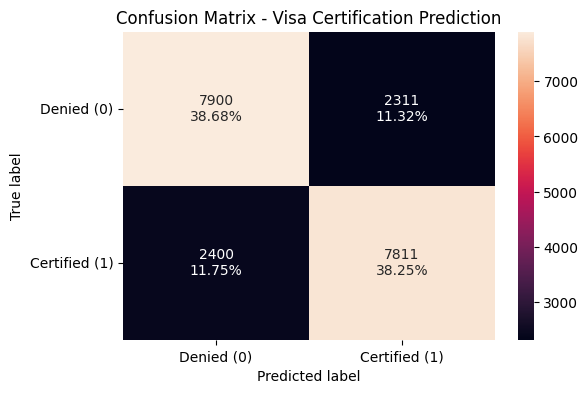

In [106]:
print("TRAINING CONFUSION MATRIX-AdaBoost(Oversampled Data):")
confusion_matrix_sklearn(ada_model_over, X_train_over, y_train_over)

**Observations for Training Set Confusion Matrix - AdaBoost (Oversampled data):**

***True Negatives (TN: 7,900 | 38.68%)***

* The model correctly classified 7,900 visa applications as denied.
* This demonstrates a great ability to capture negative cases after oversampling.

**False Positives (FP: 2,311|11.32%)**

* These are applications that were actually denied but were incorrectly classified as certified.
* The misclassification rate of approximately 11% implies a risk of granting certification to denied cases.

***False Negatives (FN: 2,400|11.75%)***

* These are applications that have actually been certified but are predicted to be denied.
* This represents missed opportunities for real approvals, but the error rate is moderate.

***True Positives (TP: 7,811|38.25%)***

* The model accurately identified 7,811 Certified apps.
* Balanced performance is seen, with about equal shares of correct predictions in both classes.

**Thus, we can say oversampling effectively reduced the bias toward the majority class.**


VALIDATION CONFUSION MATRIX-AdaBoost(Original Data):


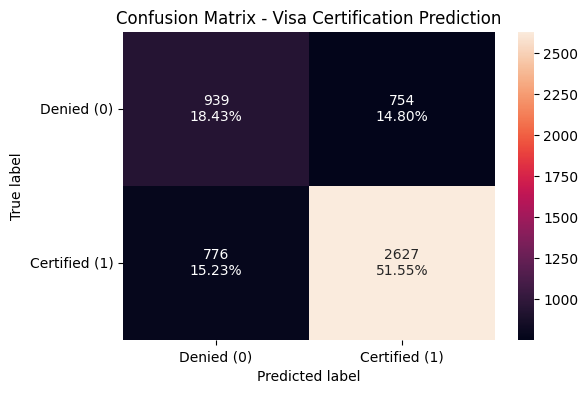

In [107]:
print("VALIDATION CONFUSION MATRIX-AdaBoost(Original Data):")
confusion_matrix_sklearn(ada_model_over, X_val, y_val)

**Observations for Validation Set Confusion Matrix - AdaBoost (Original data):**

***True Negatives: 939 (18.43%)***

* Only 939 denied applications were accurately predicted.
* Significantly lower than during training, indicating while oversampling improved minority class recognition, the model still performs weaker on denied cases in real-world (imbalanced) validation data.

***False Positives (FP: 754; 14.80%)***

* These are denied applications that have been wrongly labelled as certified.
* This  may lead to approving undesirable candidates, which may have compliance issues.


***False Negatives (FN: 776; 15.23%)***

* Certified applications were misclassified as denied.
* Rejecting legitimate applications can lead to disappointment and a loss of good candidate.


***True Positives (TP: 2,627; 51.55%)***

* The majority of certified applications were accurately predicted.
* This indicates that the model is biased towards predicting certification.


**Conclusions:**

* There is a stronger bias towards certification predictions; denial predictions are weak.
* Indicates some degree of overfitting and difficulties owing to class imbalance.
* However, this does not mean that oversampling failed, but rather demonstrates the impact of applying a balanced-trained model to an uneven real-world distribution.

###**Gradient Boosting - Oversampled Data**

In [108]:
# Initialize and train
gb_model_over = GradientBoostingClassifier(random_state=42)
gb_model_over.fit(X_train_over, y_train_over)

GradientBoostingClassifier(random_state=42)

**Checking Performance of Gradient Boosting-Oversampled Model**

In [109]:
# Training performance (on oversampled data)
print("Training Performance - GB (Oversampled Data):")
gb_train_perf_over = model_performance_classification_sklearn(gb_model_over, X_train_over, y_train_over)
gb_train_perf_over

Training Performance - GB (Oversampled Data):


,Accuracy,Recall,Precision,F1
0,0.801244,0.830967,0.784341,0.806981


**Observations for Training Performance of Gradient Boosting (Oversampled Data):**

* ***Accuracy (0.801244):*** On the training set, the model achieved an accuracy of roughly 80.12%.  This indicates strong performance, implying that the model is successfully capturing patterns in the oversampled data.

* ***Recall (0.830967):*** A recall score of about 83.10% shows that the model correctly recognises around 83.10% of the positive cases ('Certified') in the training set.  This demonstrates a good capacity to detect positive cases, which is critical in our application where missing positive occurrences is costly.

* ***Precision (0.784341):*** A precision score of 78.43% indicates that about 78.43% of the cases predicted as 'Certified' are true positives.  While this is an acceptable level of precision, it does show that the model is still producing some false positive results.

* ***F1 Score (0.806981):*** The F1 score of around 80.70% represents a strong balance of precision and recall, indicating that the model performs well overall.  This score indicates that the model is effective at recognising positive cases while also retaining a reasonable level of accuracy in its predictions.

In [110]:
# Validation performance (original validation data)
print("Validation Performance - GB (Original Data):")
gb_val_perf_over = model_performance_classification_sklearn(gb_model_over, X_val, y_val)
gb_val_perf_over

Validation Performance - GB (Original Data):


,Accuracy,Recall,Precision,F1
0,0.739992,0.835145,0.788131,0.810957


**Observations for Validation Performance of Gradient Boosting (Original Data):**

* ***Accuracy (0.739992):*** The validation set has an accuracy of about 73.99%, which is lower than the training accuracy.  This suggests that the model has difficulty generalising to previously unknown data.

* ***Recall (0.835145):*** The recall score of about 83.51% indicates that the model is effective at identifying a significant number of positive cases ('Certified') from the validation set.  This is an excellent indicator because it shows that the model can still detect positive cases even when using previously unseen data.

* ***Precision (0.788131):*** A precision score of around 78.81% suggests that the model's positive predictions are reasonably dependable, with a high rate of actual positives among predicted positives.  However, there are still some false positives.

* ***F1 Score (0.810957):*** The F1 score of around 81.10% indicates that the model performs well on the validation set, with a balance of precision and recall.  This score indicates that the model is effective at recognising positive cases while also retaining a reasonable level of accuracy in its predictions.

**Confusion Matrix of Gradient Boosting Model with Oversampled Data**

Training Confusion Matrix - GB (Oversampled Data):


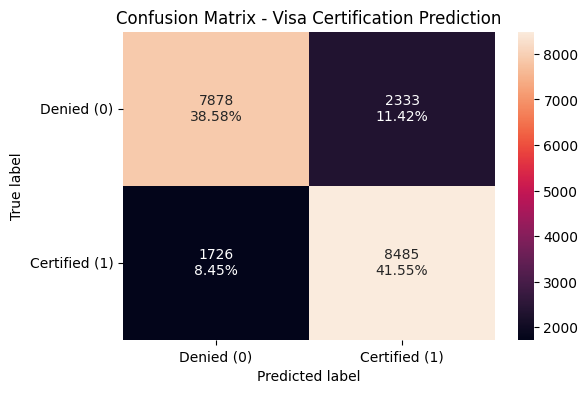

In [111]:
print("Training Confusion Matrix - GB (Oversampled Data):")
confusion_matrix_sklearn(gb_model_over, X_train_over, y_train_over)

**Observations on Training Confusion Matrix-Gradient Boosting (Oversampled Data):**

***True Negatives (TN: 7,878 | 38.58%)***
* The model correctly classified 7,878 applications as denied.
* Strong performance on negative cases, indicating oversampling, aided the model in learning minority tendencies.

***False Positives (FP: 2,333 | 11.42%)***

* Applications that were actually denied but incorrectly predicted as Certified.
* Represents the business risk of mistakenly giving certification.
* However, the error rate is moderate and manageable when compared to the improvements in actual positive predictions.

***False Negatives (FN: 1,726 | 8.45%)***

* Applications that were truly certified but reported as denied.

* This mistake rate is lower than in previous models (such as AdaBoost), indicating improved minority recall.

***True Positives (8,485 | 41.55%)***

* The model accurately classified 8,485 applications as Certified.
* This is the largest accurate block, indicating a good recognition of positive cases.

**Conclusions:**

* The model exhibits balanced prediction across both classes, demonstrating the clear benefits of oversampling.
* Both FP and FN rates are relatively modest, showing that the model is not overly biased.

Validation Confusion Matrix - GB (Original Validation Data):


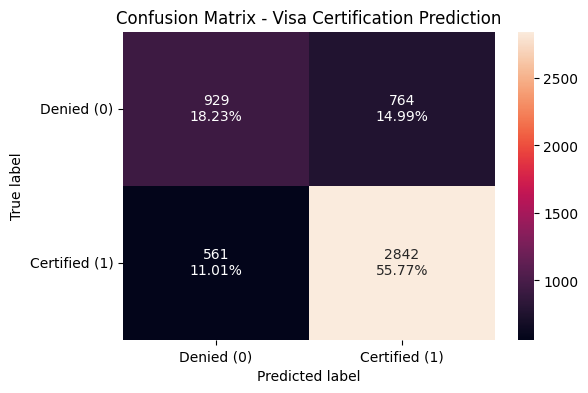

In [112]:
print("Validation Confusion Matrix - GB (Original Validation Data):")
confusion_matrix_sklearn(gb_model_over, X_val, y_val)

**Observations on Validation Confusion Matrix-Gradient Boosting (Original Data):**

***True Negatives (TN: 929 | 18.23%)***

* Only 929 denied applications were successfully detected.
* This is much lower than training, implying poorer performance on negative situations when applied to real-world distribution.
* Still, the model outperforms models trained without oversampling.


***False Positives (FP: 764 | 14.99%)***

* Applications were denied due to being misclassified as Certified.
* This creates a real-world risk of approving ineligible candidates.


***False Negatives (FN: 561 | 11.01%)***

* Certified applications were wrongly rejected as Denied.
* Although there are fewer lost opportunities than with FP.


***True Positives (TP: 2,842 | 55.77%)***

* The majority of Certified applications were predicted accurately.
* The model aligns more strongly with the Certified class, which accounts for around 67% of the validation data distribution.


**Conclusions:**

* There is a substantial bias towards Certification predictions, while Denied predictions are weaker.
* This does not imply that oversampling failed; rather, it indicates a mismatch between balanced training and imbalanced real-world validation data.

###**XGBoost- Oversampled Data**

In [113]:
# Initialize and train
xgb_model_over = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model_over.fit(X_train_over, y_train_over)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

**Checking Performance of XGBoost-Oversampled Model**

In [114]:
# Training performance on oversampled data
print("TRAINING PERFORMANCE - XGB (Oversampled Data):")
xgb_train_perf_over = model_performance_classification_sklearn(xgb_model_over, X_train_over, y_train_over)
xgb_train_perf_over

TRAINING PERFORMANCE - XGB (Oversampled Data):


,Accuracy,Recall,Precision,F1
0,0.878611,0.906473,0.858627,0.881902


**Observations on Training Performance of XGBoost (Oversampled Data):**

* ***Accuracy (0.878611):***  The model obtains an accuracy of around 87.86%, suggesting excellent performance on the training set.

* ***Recall (0.906473):*** A recall score of approximately 90.65% indicates that the model correctly recognises a large majority of positive examples ('Certified').

* ***Precision (0.858627):*** The precision score of about 85.86% shows that the majority of positive forecasts are actual positives, with some false positives included.

* ***F1 Score (0.881902):*** An F1 score of approximately 88.19% demonstrates an excellent balance of precision and recall, indicating overall prediction efficacy.

In [115]:
# Validation performance on original validation data
print("VALIDATION PERFORMANCE - XGB (Original Validation Data):")
xgb_val_perf_over = model_performance_classification_sklearn(xgb_model_over, X_val, y_val)
xgb_val_perf_over

VALIDATION PERFORMANCE - XGB (Original Validation Data):


,Accuracy,Recall,Precision,F1
0,0.72292,0.827799,0.773264,0.799603


**Observations on the Validation Performance of XGBoost (Original Validation Data):**

* ***Accuracy (0.72292):*** The accuracy on the validation set is roughly 72.29%, showing a decrease in performance when compared to the training set.

* ***Recall (0.827799):*** A recall score of around 82.78% indicates that the model continues to recognise a significant number of positive cases.

* ***Precision (0.773264):*** A precision score of roughly 77.33% suggests that the model is reasonably dependable, but there are some false positives.

* ***F1 Score (0.799603):*** An F1 score of approximately 79.96% indicates balanced performance, although lower than the training F1 score.

**Confusion Matrix of XGBoost Model with Oversampled Data**

TRAINING CONFUSION MATRIX - XGB (Oversampled Data):


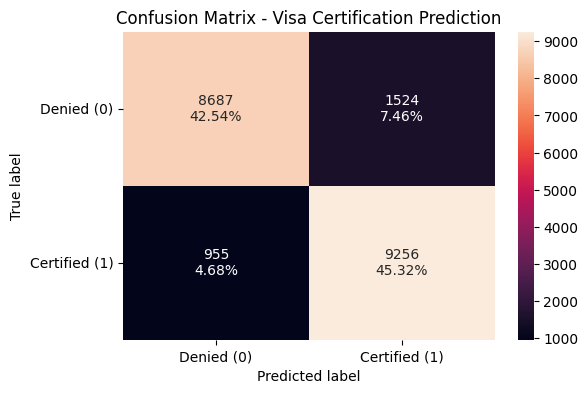

In [116]:
# Confusion matrix
print("TRAINING CONFUSION MATRIX - XGB (Oversampled Data):")
confusion_matrix_sklearn(xgb_model_over, X_train_over, y_train_over)

**Observations on the Training Confusion Matrix for XGBoost (Oversampled Data):**


***True Negatives (TN: 8,687 | 42.54%)***

* Strong performance in correctly predicting denied applications.


***False positives (FP: 1,524 | 7.46%)***

* Denied instances were misclassified as Certified; risk is low.


***False Negatives (FN: 955; 4.68%)***

* Certified applications are wrongly predicted as denied; the error rate is low.


***True Positives (TP: 9,256 | 45.32%)***

* The majority of certified instances were correctly classified, indicating excellent positive recognition.


**Conclusions:**

* Balanced performance across classes, keeping both FP and FN low.

* Oversampling significantly increased fairness across classes.

VALIDATION CONFUSION MATRIX -XGB (Original Validation Data):


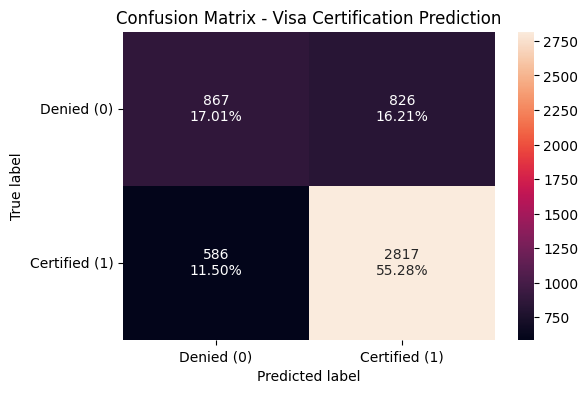

In [117]:
print("VALIDATION CONFUSION MATRIX -XGB (Original Validation Data):")
confusion_matrix_sklearn(xgb_model_over, X_val, y_val)

**Observations on the Validation Confusion Matrix for XGBoost (Original Data):**


***True Negatives (TN: 867 | 17.01% )***

* Lower than training; less accurate recognition of Denied cases in real-world distribution.

***False Positives (FP: 826 | 16.21%)***

* Denied applications were incorrectly predicted as Certified, posing a significant business risk.


***False Negatives (FN: 586 | 11.50%)***

* Certified cases predicted as denied; moderate error but lower impact than FP.


***True Positives (TP: 2,817 | 55.28%)***

* Strong recognition of Certified apps; matches with class distribution during validation.


**Conclusions:**

* The model exhibits a bias towards Certification predictions, while Denied predictions are weaker.


#**MODEL BUILDING - UNDERSAMPLED DATA**

**Undersampling is a machine learning strategy for addressing class imbalance that reduces the number of instances in the majority class.  This contributes to a more balanced dataset, improving the model's ability to learn from both classes and lowering the possibility of bias towards the majority class, resulting in better predicted performance on minority class instances. We will be applying RandomUnderSampler to implement this strategy.**

**Checking class distribution before undersampling**

In [118]:
print("Before Undersampling:")
print("Counts of label 'Denied': {}".format(sum(y_train == 0)))
print("Counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Proportions: {:.2f}% Denied, {:.2f}% Certified\n".format(
sum(y_train == 0)/len(y_train)*100,
sum(y_train == 1)/len(y_train)*100
))

Before Undersampling:
Counts of label 'Denied': 5077
Counts of label 'Certified': 10211
Proportions: 33.21% Denied, 66.79% Certified



**Observations:**

* The dataset is biased, with just **33.21%** **labelled as 'Denied'** and **66.79% as 'Certified'**.  
* This **imbalance** may result in a model that is biased towards the majority class ('Certified'), risking its ability to accurately predict the minority class ('Denied').  
* Undersampling can help to address this issue by reducing the number of cases in the majority class, resulting in a more balanced dataset.

**Applying RandomUnderSampler to train the model using undersampling technique**

In [119]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy=1, random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)


**Checking class distribution after undersampling**

In [120]:
print("After Undersampling:")
print("Counts of label 'Denied': {}".format(sum(y_train_under == 0)))
print("Counts of label 'Certified': {}".format(sum(y_train_under == 1)))
print("Proportions: {:.2f}% Denied, {:.2f}% Certified\n".format(
sum(y_train_under == 0)/len(y_train_under)*100,
sum(y_train_under == 1)/len(y_train_under)*100
))

print("After Undersampling, shape of X_train: {}".format(X_train_under.shape))
print("After Undersampling, shape of y_train: {}".format(y_train_under.shape))



After Undersampling:
Counts of label 'Denied': 5077
Counts of label 'Certified': 5077
Proportions: 50.00% Denied, 50.00% Certified

After Undersampling, shape of X_train: (10154, 21)
After Undersampling, shape of y_train: (10154,)


**Observations:**

* Class distribution is balanced after applying undersampling technique.
* Both 'Denied' & 'Certified' class is now at 50% - 50%
* The shape of X_train is (10154, 21) & y_train is (10154,).


##**Decision Tree - Undersampled Data**

In [121]:
#Train & fit Model

dt_model_under = DecisionTreeClassifier(random_state=42)
dt_model_under.fit(X_train_under, y_train_under)

DecisionTreeClassifier(random_state=42)

**Checking performance for Decision Tree (Undersampled Data)**

In [122]:
print("TRAINING PERFORMANCE - DT (Undersampled Data):")
dt_train_perf_under = model_performance_classification_sklearn(dt_model_under, X_train_under, y_train_under)
dt_train_perf_under

TRAINING PERFORMANCE - DT (Undersampled Data):


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Observations on Training Performance for Decision Tree (Undersampled Data):**

* ***Accuracy (1.0):*** The model achieves 100% accuracy on the training set, indicating that all of the training data has been classified but data is overfitting.

* ***Recall (1.0):*** A 100% recall score indicates that the model correctly recognises all positive instances ('Certified').

* ***Precision (1.0):*** A precision score of 100% means that all positive predictions are correct, with no false positives.

* ***F1 Score (1.0):*** A score of 100% demonstrates an ideal blend of precision and recall, indicating remarkable performance on the training data.

* This high performance is high due to the class balance technique and may not reflect the real-world scenario, indicating overfitting model.

In [123]:
print("VALIDATION PERFORMANCE-DT (Original Validation Data):")
dt_val_perf_under = model_performance_classification_sklearn(dt_model_under, X_val, y_val)
dt_val_perf_under

VALIDATION PERFORMANCE-DT (Original Validation Data):


,Accuracy,Recall,Precision,F1
0,0.611656,0.607405,0.762731,0.676264


**Observations on Validation Performance for Decision Tree (Original Validation Data):**

* ***Accuracy (0.611656):*** The validation set has an accuracy of roughly 61.17%, showing a considerable decrease in performance when compared to the training set.

* ***Recall (0.607405):*** A recall score of around 60.74% indicates that the model only recognises a subset of positive events ('Certified').

* ***Precision (0.762731):*** A precision score of roughly 76.27% suggests that a significant majority of positive predictions are true positives, but there are also false positives.

* ***F1 Score (0.676264):*** An F1 score of approximately 67.63% indicates a moderate balance of precision and recall, but it is significantly lower than the training F1 score.

**Conclusions:**

* When compared to its high performance metrics on the training set, the model exhibits a considerable reduction.

* This disparity indicates that the model is not correctly capturing the underlying patterns in the validation data, most likely due to overfitting on the training data.


**Confusion Matrix for Decision Tree (Undersampled Data)**

TRAINING CONFUSION MATRIX -DT (Undersampled Data):


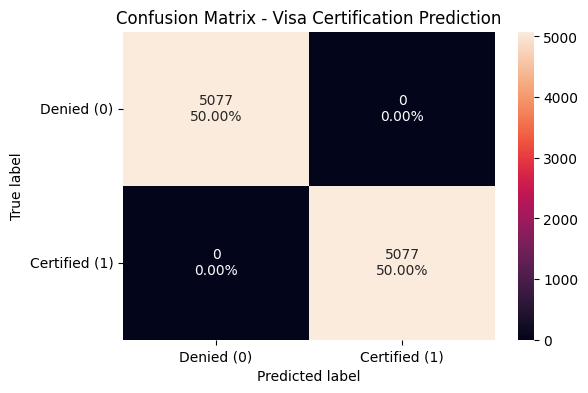

In [124]:
print("TRAINING CONFUSION MATRIX -DT (Undersampled Data):")
confusion_matrix_sklearn(dt_model_under, X_train_under, y_train_under)



**Observations on Training for Confusion Matrix of Decision Trees (Undersampled Data):**

* ***True Negatives (TN): 5,077*** cases were correctly classified as 'Denied' (50%).

* ***False Positives (FP): 0*** instances were falsely classified as 'Certified' (0%).

* ***False Negatives (FN): 0*** cases were wrongly classified as 'Denied' (0%).

* ***True Positives (TP): 5,077*** instances were accurately classified as 'Certified' (50%).

**Conclusions:**

* The Decision Tree model correctly identifies all cases in the training set, suggesting overfitting.  

* The model learnt the training data too well, which resulted in no misclassification.

VALIDATION CONFUSION MATRIX-DT (Original Validation Data):


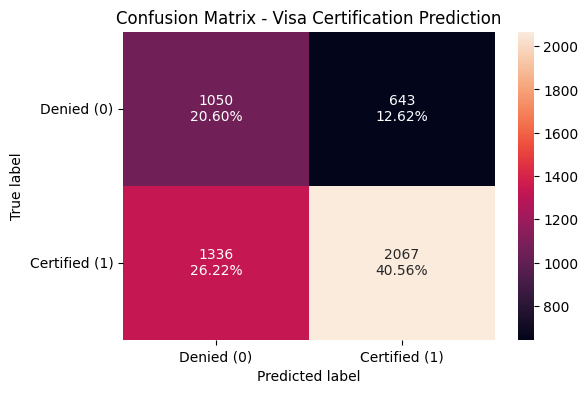

In [125]:
print("VALIDATION CONFUSION MATRIX-DT (Original Validation Data):")
confusion_matrix_sklearn(dt_model_under, X_val, y_val)

**Observations on the Validation Confusion Matrix of Decision Tree (Original Validation Data):**

* ***True Negatives (TN): 1,050*** cases were properly predicted as 'Denied' (20.60%).

* ***False Positives (FP): 643*** instances were wrongly identified as 'Certified' (12.62%).

* ***False Negatives (FN): 1,336*** instances mistakenly classified as 'Denied' (26.22%).

* ***True Positives (TP): 2,067*** instances were accurately identified as 'Certified' (40.56%).

**Conclusion:**

* The model performs badly on the validation set, with a high amount of misclassifications (1,336 false negatives and 643 false positives).  

* This demonstrates that the model is overfitting, as it is unable to generalise successfully to new data.  

* The training set's high accuracy does not transition to the validation set, indicating that the model's predictions are not resilient.

##**Bagging - Undersampled Data**

**Building Random Forest Model (Undersampled Data)**

In [126]:
rf_model_under = RandomForestClassifier(random_state=42)
rf_model_under.fit(X_train_under, y_train_under)


RandomForestClassifier(random_state=42)

**Checking performance for Random Forest (Undersampled Data)**

In [127]:
print("TRAINING PERFORMANCE-RF(Undersampled Data):")
rf_train_perf_under = model_performance_classification_sklearn(rf_model_under, X_train_under, y_train_under)
rf_train_perf_under

TRAINING PERFORMANCE-RF(Undersampled Data):


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Observations on Random Forest Training Performance (Undersampled Data):**

* ***Accuracy (1.0):*** The model has a high accuracy of 100% on the training set.

* ***Recall (1.0):*** A 100% recall score means that all positive cases ('Certified') were accurately identified.

* ***Precision (1.0):*** A score of 100% indicates that all positive predictions are true positives.

* ***F1 score (1.0):*** An F1 score of 100% indicates a perfect combination of precision and recall.

**Conclusions:**
* The Random Forest model performs perfectly on undersampled training data, suggesting overfitting.

* The perfect scores indicate that the model learnt the training data too well, catching both noise and specific patterns.



In [128]:
print("VALIDATION PERFORMANCE-RF (Original Validation Data):")
rf_val_perf_under = model_performance_classification_sklearn(rf_model_under, X_val, y_val)
rf_val_perf_under

VALIDATION PERFORMANCE-RF (Original Validation Data):


,Accuracy,Recall,Precision,F1
0,0.684851,0.683808,0.814491,0.74345


**Observations on Validation Performance of Random Forest (Original Validation Data):**

* ***Accuracy (0.684851):*** The validation set has an accuracy of about 68.49%, indicating moderate performance.

* ***Recall (0.683808):*** A recall score of around 68.38% indicates that the model correctly detects a substantial proportion of positive events ('Certified').

* ***Precision (0.814491):*** A precision score of around 81.45% implies that the majority of positive predictions are true positives.

* ***F1 Score (0.74345):*** An F1 score of approximately 74.35% indicates a healthy balance of precision and recall.

**Conclusions:**

* The Random Forest model performs relatively well on the validation set, with a significant decline in performance when compared to the training set.

* While it has strong precision and recall, the lower accuracy and F1 score indicate that the model is not generalising as effectively as it should.

* This points to potential overfitting, as the model performs much better on training data than on unknown data.

**Confusion Matrix for Random Forest (Undersampled Data)**

TRAINING CONFUSION MATRIX-RF (Undersampled Data):


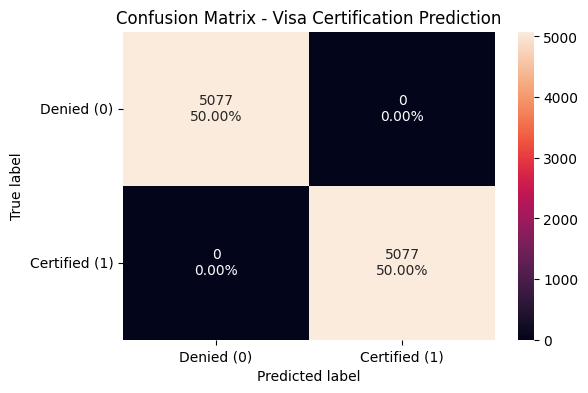

In [129]:
print("TRAINING CONFUSION MATRIX-RF (Undersampled Data):")
confusion_matrix_sklearn(rf_model_under, X_train_under, y_train_under)


**Observations on Training for Confusion Matrix of Random Forest (Undersampled Data):**

* ***True Negatives (TN): 5,077*** cases were correctly classified as 'Denied' (50%).

* ***False Positives (FP): 0*** instances were falsely classified as 'Certified' (0%).

* ***False Negatives (FN): 0*** cases were wrongly classified as 'Denied' (0%).

* ***True Positives (TP): 5,077*** instances were accurately classified as 'Certified' (50%).

**Conclusions:**

* The Random Forest model correctly identifies all cases in the training set, indicating overfitting. This result is similar to decision tree training set.

* The model learnt the training data too well, which resulted in no misclassification.

VALIDATION CONFUSION MATRIX-RF (Original Validation Data):


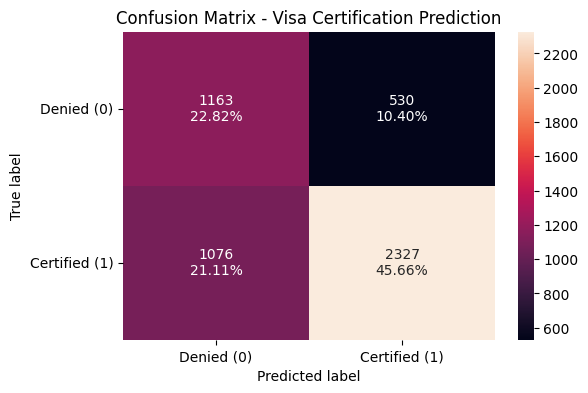

In [130]:
print("VALIDATION CONFUSION MATRIX-RF (Original Validation Data):")
confusion_matrix_sklearn(rf_model_under, X_val, y_val)

**Observations on Random Forest's Validation Confusion Matrix (original validation data):**

* ***True Negatives (TN): 1,163*** cases were properly predicted as 'Denied' (22.82%).

* ***False Positives (FP): 530*** occurrences were wrongly identified as 'Certified' (10.40%).

* ***False Negatives (FN): 1,076*** cases were mistakenly classified as 'Denied' (21.11%).

* ***True Positives (TP): 2,327*** instances were accurately classified as 'Certified' (45.66%).



**Conclusions:**

* The validation set had 1,076 false negatives and 530 false positives, indicating a significant number of misclassifications by the model.

* This implies that the model does not generalise effectively to prior unseen data, proving that it is most likely overfitting.

* The validation set performs significantly worse than the training set, emphasising the need for improved model robustness and generalisation.

##**Boosting - Undersampled Data**

###**AdaBoost - Undersampled Data**

In [131]:
ada_model_under = AdaBoostClassifier(random_state=42)
ada_model_under.fit(X_train_under, y_train_under)

AdaBoostClassifier(random_state=42)

**Checking performance for AdaBoost Model (Undersampled Data)**

In [132]:
print("TRAINING PERFORMANCE-AdaBoost(Undersampled Data):")
ada_train_perf_under = model_performance_classification_sklearn(ada_model_under, X_train_under, y_train_under)
ada_train_perf_under

TRAINING PERFORMANCE-AdaBoost(Undersampled Data):


,Accuracy,Recall,Precision,F1
0,0.690762,0.741383,0.673225,0.705662


**Observations on AdaBoost Training Performance (Undersampled Data):**

* ***Accuracy (0.690762):*** On the training set, the model achieves an average accuracy of 69.08%.

* ***Recall (0.741383):*** A recall score of around 74.14% shows that the model correctly detects a substantial proportion of positive events ('Certified').

* ***Precision (0.673225):*** A precision score of about 67.32% indicates that a large proportion of positive predictions are true positives.

* ***F1 Score (0.705662):*** An F1 score of approximately 70.57% indicates a reasonable balance of precision and recall.


**Conclusion:**

* The AdaBoost model performs relatively well on undersampled training data, without overfitting.

* The metrics show that the model recognises patterns in the data without attaining flawless classification, implying a high level of generalisation.

In [133]:
print("VALIDATION PERFORMANCE-AdaBoost (Original Validation Data):")
ada_val_perf_under = model_performance_classification_sklearn(ada_model_under, X_val, y_val)
ada_val_perf_under

VALIDATION PERFORMANCE-AdaBoost (Original Validation Data):


,Accuracy,Recall,Precision,F1
0,0.709969,0.750808,0.802198,0.775653


**Observations for Validation Performance of AdaBoost (Original Validation Data):**

* ***Accuracy (0.709969):*** The validation set has an accuracy of about 70.99%, which is slightly higher than the training set.

* ***Recall (0.750808):*** A recall score of approximately 75.08% indicates that the model continues to recognise a significant number of positive cases.

* ***Precision (0.802198):*** A precision score of around 80.22% implies that a large proportion of positive predictions are true positives.

* ***F1 Score (0.775653):*** An F1 score of approximately 77.57% indicates a solid balance of precision and recall.


***Conclusions:***

* The AdaBoost model outperforms on the validation set, with higher accuracy and F1 score compared to the training set.  

* This shows that the model is effectively generalising to previously unseen data, implying that it is not overfitting and has strong predictions.

**Confusion Matrix for AdaBoost Model (Undersampled Data)**

TRAINING CONFUSION MATRIX-AdaBoost (Undersampled Data):


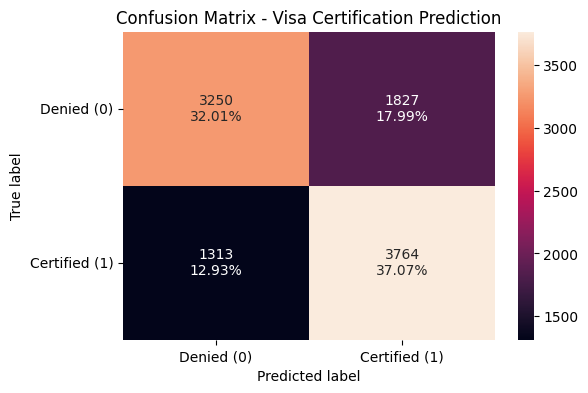

In [134]:
print("TRAINING CONFUSION MATRIX-AdaBoost (Undersampled Data):")
confusion_matrix_sklearn(ada_model_under, X_train_under, y_train_under)

**Observations for Training Confusion Matrix of AdaBoost (Undersampled Data):**


* ***True Negatives (TN): 3,250*** cases were properly predicted as 'Denied' (32.01%).

* ***False Positives (FP): 1,827*** instances were falsely classified as 'Certified' (17.99%).

* ***False Negatives (FN): 1,313*** instances falsely classified as 'Denied' (12.93%).

* ***True Positives (TP): 3,764*** instances were accurately predicted as 'Certified' (37.07%).


**Conclusion:**

* The AdaBoost model performs well on the training set, with a manageable number of misclassifications.  
* The presence of false positives and false negatives suggests that the model is not overfitting because it captures trends without reaching perfect classification.  The model generalises well.

VALIDATION CONFUSION MATRIX-AdaBoost(Original Validation Data):


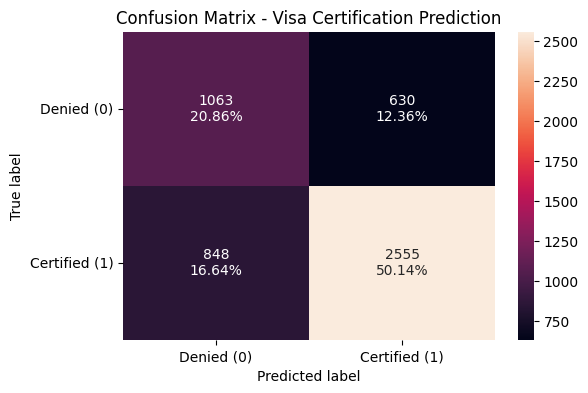

In [135]:
print("VALIDATION CONFUSION MATRIX-AdaBoost(Original Validation Data):")
confusion_matrix_sklearn(ada_model_under, X_val, y_val)

**Observations on the AdaBoost Validation Confusion Matrix (Original Validation Data):**

* ***True Negatives (TN): 1,063*** cases were accurately classified as 'Denied' (20.86%).

* ***False Positives (FP): 630*** instances were falsely identified as 'Certified' (12.36%).

* ***False negatives (FN): 848*** cases were inaccurately predicted as 'Denied' (16.64%).

* ***True Positives (FP): 2,555*** instances were accurately classified as 'Certified' (50.14%).


**Conclusions:**

* The model performs well on the validation set, with a high number of true positives (2,555) and a modest number of misclassifications.  
* The results show that the AdaBoost model generalises well to previously unexplored data, with no symptoms of overfitting.  
* The performance indicators indicate a robust model with a decent mix of precision and recall.

###**Gradient Boosting - Undersampled Data**

In [136]:
gb_model_under = GradientBoostingClassifier(random_state=42)
gb_model_under.fit(X_train_under, y_train_under)

GradientBoostingClassifier(random_state=42)

**Checking performance for Gradient Boosting Model (Undersampled Data)**

In [137]:
print("TRAINING PERFORMANCE-GB(Undersampled Data):")
gb_train_perf_under = model_performance_classification_sklearn(gb_model_under, X_train_under, y_train_under)
gb_train_perf_under

TRAINING PERFORMANCE-GB(Undersampled Data):


,Accuracy,Recall,Precision,F1
0,0.72336,0.746898,0.713318,0.729722


**Observations for Training Performance of Gradient Boosting (Undersampled Data):**

* ***Accuracy (0.72336):*** On the training set, the model achieved an accuracy of roughly 72.34%.

* ***Recall (0.746898):*** A recall score of around 74.69% suggests that the model correctly recognises a substantial portion of positive events ('Certified').

* ***Precision (0.713318):*** A precision score of about 71.33% indicates that a large proportion of positive predictions are true positives.

* ***F1 Score (0.729722):*** An F1 score of approximately 72.97% indicates an acceptable balance of precision and recall.

**Conclusions:**

* The Gradient Boosting model performs relatively well on the undersampled training data, showing no evidence of overfitting.

* The metrics show that the model efficiently captures patterns in the data without attaining perfect classification, implying a high level of generalisation.

In [138]:
print("VALIDATION PERFORMANCE-GB (Original Validation Data):")
gb_val_perf_under = model_performance_classification_sklearn(gb_model_under, X_val, y_val)
gb_val_perf_under

VALIDATION PERFORMANCE-GB (Original Validation Data):


,Accuracy,Recall,Precision,F1
0,0.716052,0.739348,0.817945,0.776663


**Observations for Validation Performance of Gradient Boosting (Original Validation Data):**

* ***Accuracy (0.716052):*** The accuracy score on the validation set is ~71.61%, suggesting a slight decline as compared to the training set.

* ***Recall (0.739348):*** A recall score of around 73.93% indicates that the model continues to recognise a significant number of positive cases.

* ***Precision (0.817945):*** A precision score of around 81.79% implies that the majority of positive predictions are true positives.

* ***F1 Score (0.776663):*** An F1 score of approximately 77.67% indicates a solid balance of precision and recall.


**Conclusions:**

* The Gradient Boosting model outperforms on the validation set, with only a modest reduction in accuracy compared to the training set.  
* However, the improvement in precision and F1 score indicates that the model is effectively generalising to previously unseen data, implying that it is not overfitting and has strong predictions.



**Confusion Matrix for Gradient Boosting Model (Undersampled Data)**

TRAINING CONFUSION MATRIX-GB (Undersampled Data):


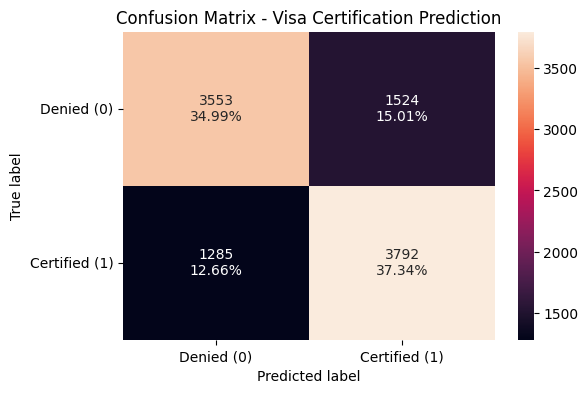

In [139]:
print("TRAINING CONFUSION MATRIX-GB (Undersampled Data):")
confusion_matrix_sklearn(gb_model_under, X_train_under, y_train_under)

**Observations for Training Confusion Matrix of Gradient Boosting (Undersampled Data):**

* ***True Negatives (TN): 3,553*** cases were accurately predicted as 'Denied' (34.99%).

* ***False Positives (FP): 1,524*** instances were wrongly classified as 'Certified' (15.01%).

* ***False Negatives (FN): 1,285*** instances were wrongly classified as 'Denied' (12.66%).

* ***True Positives (TP): 3,792*** instances were accurately identified as 'Certified' (37.34%).


**Conclusions:**

* The Gradient Boosting model performs well on the training set, with a fair proportion of misclassifications.

* False positives and false negatives show that the model is not overfitting because it captures trends without attaining perfect classification.

* Overall, the model shows a high level of generalisation.

VALIDATION CONFUSION MATRIX-GB (Original Validation Data):


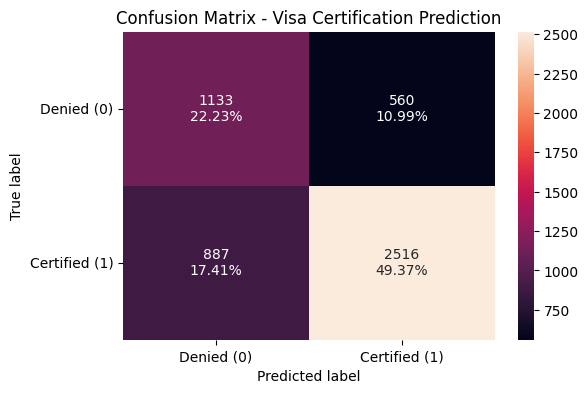

In [140]:
print("VALIDATION CONFUSION MATRIX-GB (Original Validation Data):")
confusion_matrix_sklearn(gb_model_under, X_val, y_val)

**Observations for Validation Confusion Matrix of Gradient Boosting (Original Validation Data):**

* ***True Negatives (TN): 1,133*** cases were properly predicted as 'Denied' (22.23%).

* ***False Positives (FP): 560*** instances were falsely identified as 'Certified' (10.99%).

* ***False Negatives (FN): 887*** cases were mistakenly classified as 'Denied' (17.41%).

* ***True Positives (TP): 2,516*** instances were accurately classified as 'Certified' (49.37%).


**Conclusions:**

* The model performs well on the validation set, with a high number of true positives (2,516) and a modest number of misclassifications.

* The results show that the Gradient Boosting model generalises well to new data, with no evidence of overfitting.

* The performance indicators indicate a robust model with a decent mix of precision and recall.

###**XGBoost - Undersampled Data**

In [141]:
xgb_model_under = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model_under.fit(X_train_under, y_train_under)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

**Checking performance for XGBoost Model (Undersampled Data)**

In [142]:
print("TRAINING PERFORMANCE-XGB (Undersampled Data):")
xgb_train_perf_under = model_performance_classification_sklearn(xgb_model_under, X_train_under, y_train_under)
xgb_train_perf_under

TRAINING PERFORMANCE-XGB (Undersampled Data):


,Accuracy,Recall,Precision,F1
0,0.866555,0.861926,0.86998,0.865935


**Observations on the Training Performance of XGBoost (Undersampled Data):**

* ***Accuracy (0.866555):*** The model obtains a high accuracy of around 86.66% on the training data.

* ***Recall (0.861926):*** A recall score of around 86.19% shows that the model correctly detects a substantial percentage of positive instances ('Certified').

* ***Precision (0.86998):*** The precision score of about 86.99% indicates that the majority of positive predictions are true positives.

* ***F1 Score (0.865935):*** An F1 score of approximately 86.59% indicates a solid balance of precision and recall.

**Conclusions:**

* The XGBoost model outperforms the undersampled training data, indicating possible overfitting.

* The high scores across all criteria indicate that the model learnt the training data quite well, possibly capturing noise and unique patterns.

In [143]:
print("VALIDATION PERFORMANCE-XGB (Original Validation Data):")
xgb_val_perf_under = model_performance_classification_sklearn(xgb_model_under, X_val, y_val)
xgb_val_perf_under



VALIDATION PERFORMANCE-XGB (Original Validation Data):


,Accuracy,Recall,Precision,F1
0,0.690345,0.694387,0.814547,0.749683


**Observations for Validation Performance of XGBoost (Original Validation Data):**

* ***Accuracy (0.690345):*** The accuracy on the validation set is ~69.03%, suggesting a significant drop compared to the training set.

* ***Recall (0.694387):*** A recall score of around 69.44% indicates that the model detects a good proportion of positive cases.

* ***Precision (0.814547):*** A precision score of around 81.45% implies that a significant number of positive predictions are true positives.

* ***F1 Score (0.749683):*** An F1 score of approximately 74.97% indicates a moderate balance of precision and recall.


**Conclusions:**

* The XGBoost model performs significantly worse on the validation set, with lower accuracy and F1 scores than on the training set.

* This indicates that the model is not generalising effectively to unseen data, which confirms concerns of overfitting.

* The mismatch between training and validation measures shows that modifications are required to improve robustness and generalisation.

**Confusion Matrix for XGBoost Model (Undersampled Data)**

TRAINING CONFUSION MATRIX-XGB (Undersampled Data):


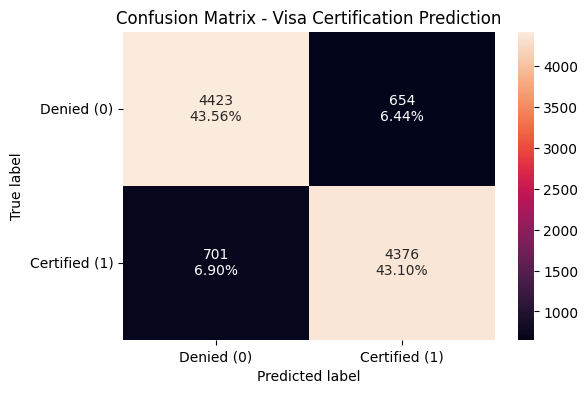

In [144]:
print("TRAINING CONFUSION MATRIX-XGB (Undersampled Data):")
confusion_matrix_sklearn(xgb_model_under, X_train_under, y_train_under)


**Observations for the Training Confusion Matrix of XGBoost (Undersampled Data):**

* ***True Negatives (TN): 4,423*** instances were accurately classified as 'Denied' (43.56%).

* ***False Positives (FP): 654*** instances were falsely identified as 'Certified' (6.44%).

* ***False negatives (FN): 701*** cases were inaccurately predicted as 'Denied' (6.90%).

* ***True Positives (TP): 4,376*** instances were accurately identified as 'Certified' (43.10%).


 **Conclusions:**

* The XGBoost model performs well on the training set, with a large number of true positives and true negatives.

* The model's relatively low false positive and false negative rates indicate that it is not overfitting, since it successfully identifies patterns without attaining perfect classification.

* Overall, the model exhibits a high level of generalisations.

VALIDATION CONFUSION MATRIX-XGB (Original Validation Data):


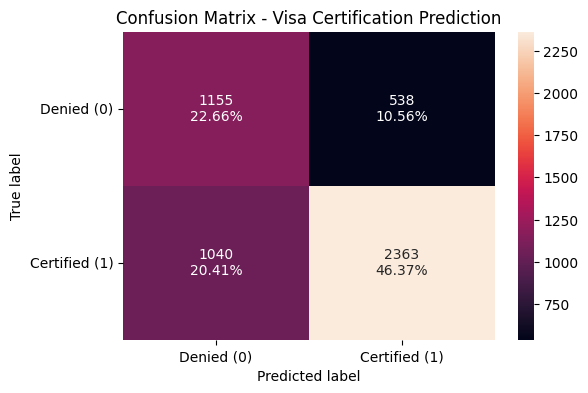

In [145]:
print("VALIDATION CONFUSION MATRIX-XGB (Original Validation Data):")
confusion_matrix_sklearn(xgb_model_under, X_val, y_val)

**Observations for the Validation Confusion Matrix of XGBoost (original validation data):**

* ***True Negatives (TN): 1,155*** instances were accurately classified as 'Denied' (22.66%).

* ***False Positives (FP): 538*** instances were falsely classified as 'Certified' (10.56%).

* ***False Negatives (FN): 1,040*** cases were mistakenly classified as 'Denied' (20.41%).

* ***True Positives (TP): 2,363*** instances were accurately identified as 'Certified' (46.37%).


**Conclusions:**

* On the validation set, the model performs moderately, with a substantial number of true positives and false negatives.

* The decrease in performance as compared to the training set suggests that the model is not generalising well to new data, confirming indicators of overfitting.

* The mismatch in measurements shows that further tuning is required to improve robustness and generalisation.

#**HYPERPARAMETER TUNING**

**We chose AdaBoost, Gradient Boosting, XGBoost, and Random Forest for hyperparameter tuning**.  Gradient Boosting had the **highest validation F1 score**, demonstrating outstanding baseline performance.  **AdaBoost's initial F1 was somewhat higher than XGBoost's** so we chose that as well. We also chose **XGBoost since it has more tuning options** and typically performs better following hyperparameter optimisation.  Random Forest was chosen because of its **consistent and reliable performance**.

**We did not select models trained on oversampled or undersampled data because they had lower validation scores**.  Sampling probably didn't help much because the class imbalance is moderate, and the models manage it well without changing the data distribution.

**Hyperparameter Tuning Strategy**

* To improve model performance and directly address the class imbalance, we efficiently tuned critical parameters using **RandomizedSearchCV**.

* Objective: Reduce overfitting and improve minority class recognition ("Denied").

**Key Parameters:**

* ***n_estimators:*** Increased the number of trees to make the model more resilient.

* ***max_depth:*** Restricts tree complexity to avoid overfitting.

* To address imbalance, misclassifying "Denied" situations was penalised directly using ***class_weight (RF) and scale_pos_weight (XGBoost)***.

* ***min_samples_leaf & min_samples_split:*** Ensures that splits were based on appropriate sample sizes.

* ***RandomizedSearchCV*** was used to identify the optimal combination of these parameters across a large search space.

**Now, we will now do model performance improvement using hyperparameter tuning.**

In [146]:
# Define F1 scorer for optimization
f1_scorer = make_scorer(f1_score)

# Calculate class weights for handling imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print(f"Class weights for imbalance handling: {class_weight_dict}")

# Calculate scale_pos_weight for XGBoost
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
print(f"Scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")


Class weights for imbalance handling: {np.int64(0): np.float64(1.5056135513098285), np.int64(1): np.float64(0.7486044461854863)}
Scale_pos_weight for XGBoost: 0.50


**Observations:**

* Class 0 (minority class-'Denied') has weight **1.51**

* Class 1 (majority class-'Certified') has weight **~0.75**

* In XGBoost, imbalance is handled by using the **scale_pos_weight** parameter. This **internally up-weight the minority** ("Denied" class, labeled as 0) to balance training.

##**Gradient Boosting Model Tuning**

In [147]:
# Parameter grid for Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None],
    'loss': ['deviance', 'exponential']
}

# Initialize RandomizedSearchCV
gb_random = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=50,
    scoring=f1_scorer,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Perform tuning
print("Performing hyperparameter tuning for Gradient Boosting:")
gb_random.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters for Gradient Boosting:")
print(gb_random.best_params_)
print(f"Best Cross-Validation F1 Score: {gb_random.best_score_:.4f}")

# Evaluate tuned model
gb_tuned = gb_random.best_estimator_

Performing hyperparameter tuning for Gradient Boosting:
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters for Gradient Boosting:
{'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'loss': 'exponential', 'learning_rate': 0.01}
Best Cross-Validation F1 Score: 0.8261


**Observations:**

* After tuning, the best Gradient Boosting parameters were: ***subsample=1.0, n_estimators=300, min_samples_split=20, min_samples_leaf=4, max_features='log2', max_depth=5, loss='exponential', and learning_rate=0.01***.

* The tuned Gradient Boosting model achieved an average cross-validation **F1 score of 0.8261, somewhat higher than the original score of 0.8237**.  While the gain is minor, it indicates that hyperparameter adjustment improved the model's  generalisation.

**Checking Performance of Tuned Gradient Boosting Model**

In [148]:
print("Tuned Gradient Boosting - Training Performance:")
gb_train_perf_tuned = model_performance_classification_sklearn(gb_tuned, X_train, y_train)
gb_train_perf_tuned

Tuned Gradient Boosting - Training Performance:


,Accuracy,Recall,Precision,F1
0,0.758438,0.89335,0.777929,0.831654


**Observations on the Training Data Performance of Tuned Gradient Boosting:**

* ***Accuracy (0.758438):*** The training accuracy is at 75.84%, indicating that the model fits the data well.

* ***Recall (0.89335):*** A high recall of around 89.34% indicates that the model accurately recognises the majority of positive cases in the training set.

* ***Precision (0.777929):*** A precision of approximately 77.79% indicates that a significant number of positive predictions are correct.

* ***F1 Score (0.831654):*** The F1 score of 83.17% indicates a good balance of precision and recall on the training data.


**Conclusions**:

* The tuned Gradient Boosting model performs well on the training set, with good recall and balanced precision, suggesting effective improvement.

* The metrics scores indicate that the model accurately reflects the underlying patterns while avoiding obvious underfitting.

In [149]:
print("Tuned Gradient Boosting - Validation Performance:")
gb_val_perf_tuned = model_performance_classification_sklearn(gb_tuned, X_val, y_val)
gb_val_perf_tuned

Tuned Gradient Boosting - Validation Performance:


,Accuracy,Recall,Precision,F1
0,0.74686,0.891566,0.76713,0.824681


**Observations for Validation Data Performance of Tuned Gradient Boosting:**

* ***Accuracy (0.74686):*** The validation accuracy is roughly 74.69%, which is little lower than the training accuracy but still high.

* ***Recall (0.891566):*** Recall remains high, at approximately 89.16%, indicating that the model continues to recognise the majority of positive cases on previously unseen data.

* ***Precision (0.76713):*** A precision of 76.71% implies that a significant proportion of positive predictions are true positives based on validation data.

* ***F1 Score (0.824681):*** The F1 score of 82.47% demonstrates an excellent mix of precision and recall, which is comparable to training performance.


**Conclusions:**

* The model's validation measures are similar to training results, showing high generalisation and minimal overfitting.

* The minor decline in accuracy and precision is to be expected, and it demonstrates that the model's prediction capacity on new data remains strong.

**Confusion Matrix of Tuned Gradient Boosting Model**

Tuned Gradient Boosting - Training Confusion Matrix:


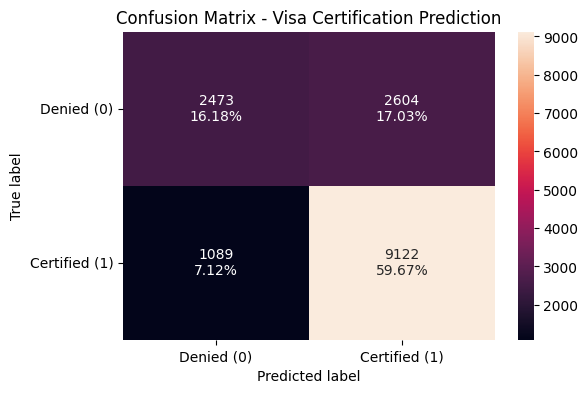

In [150]:
print("Tuned Gradient Boosting - Training Confusion Matrix:")
confusion_matrix_sklearn(gb_tuned, X_train, y_train)

**Observations on the Training Confusion Matrix of Tuned Gradient Boosting Model:**

* ***True Negative (TN = 2473, 16.18%):*** The model accurately predicted 16.18% of denied cases.

* ***False Positives (FP = 2604, 17.03%):*** Approximately 17.03% of denied cases were falsely predicted as certified.

* ***False Negatives (FN = 1089, 7.12%):*** Approximately 7.12% of certified cases were falsely predicted as refused.

* ***True Positive (TP = 9122, 59.67%):*** The model accurately detected 59.67% of certified cases.


**Conclusions:**

* The model has an excellent ability to detect certified cases (high TP), but the comparatively high FP rate suggests that some denied instances are misclassified as certified.

* Overall, the training results indicate good learning without excessive overfitting.

Tuned Gradient Boosting - Validation Confusion Matrix:


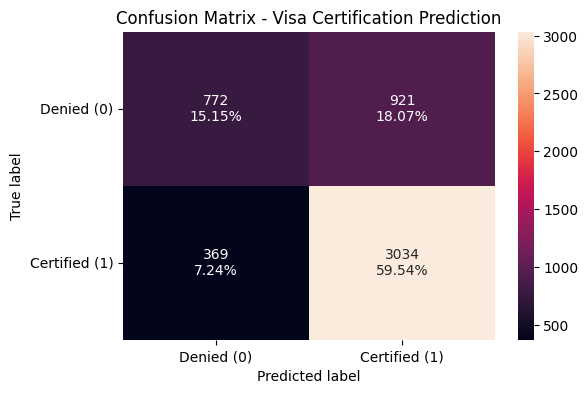

In [151]:
print("Tuned Gradient Boosting - Validation Confusion Matrix:")
confusion_matrix_sklearn(gb_tuned, X_val, y_val)

**Observations for Validation Confusion Matrix of Tuned Gradient Boosting Model:**

* ***True Negative (TN = 772, 15.15%):*** Correctly predicted 15.15 percent of denied cases.

* ***False Positive (FP = 921, 18.07%):*** 18.07% of refused cases were incorrectly identified as certified.

* ***False Negative (FN = 369, 7.24%):*** 7.24 percent of certified cases were incorrectly classed as denied.

* ***True Positive (TP = 3034, 59.54%):*** Identified 59.54% of certified cases.


**Conclusions:**

* Validation findings closely resemble training performance, with comparable TP and FP rates.

* This consistency suggests that the model generalises well without severe overfitting, resulting in balanced predicted accuracy on unseen data.

##**XGBoost Model Tuning**

In [152]:
# Parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 2, 3, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.1, 0.5, 1, 2],
    'reg_lambda': [1, 1.5, 2, 3],
    'scale_pos_weight': [1, scale_pos_weight, scale_pos_weight*1.5]
}

# Initialize RandomizedSearchCV
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=50,
    scoring=f1_scorer,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Perform tuning
print("Performing hyperparameter tuning for XGBoost:")
xgb_random.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters for XGBoost:")
print(xgb_random.best_params_)
print(f"Best Cross-Validation F1 Score: {xgb_random.best_score_:.4f}")

# Evaluate tuned model
xgb_tuned = xgb_random.best_estimator_

Performing hyperparameter tuning for XGBoost:
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters for XGBoost:
{'subsample': 0.8, 'scale_pos_weight': np.float64(0.7458133385564587), 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 4, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.7}
Best Cross-Validation F1 Score: 0.8262


**Observations:**

* **5-fold CV** was performed with **50 parameter** candidates (250 fits).

* The optimal parameters chosen are ***max_depth=6, n_estimators=100, learning_rate=0.01, with regularisation (reg_alpha=0.1, reg_lambda=1) and balanced sampling (scale_pos_weight≈0.75)***.

* The best cross-validation result was ***F1 = 0.8262***.

* XGBoost performance is relatively similar to Gradient Boosting, with only a **minor improvement** by tuning from the base line model. This is because our baseline model was already performing good on the validation set, hence there was only a little room for improvement.


**Checking Performance of XGBoost Tuned Model**

In [153]:
print("Tuned XGBoost - Training Performance:")
xgb_train_perf_tuned = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)
xgb_train_perf_tuned

Tuned XGBoost - Training Performance:


,Accuracy,Recall,Precision,F1
0,0.758307,0.887866,0.780475,0.830714


**Observations on Tuned XGBoost - Training Performance:**

* ***Accuracy (0.7583):*** The model successfully predicts approximately 75.83% of cases based on training data.

* ***Recall (0.8879):*** A high recall indicates accurate detection of positive cases.

* ***Precision (0.7805):*** indicates that 78.05% of positive predictions are correct.

* ***F1 Score (0.8307):*** indicates a balanced performance between precision and recall.


**Conclusions:**

* The model performs well on training data, with high recall and balanced precision, indicating effective learning without overfitting.

In [154]:
print("Tuned XGBoost - Validation Performance:")
xgb_val_perf_tuned = model_performance_classification_sklearn(xgb_tuned, X_val, y_val)
xgb_val_perf_tuned

Tuned XGBoost - Validation Performance:


,Accuracy,Recall,Precision,F1
0,0.74686,0.884808,0.770274,0.823578


**Observations on Tuned XGBoost - Validation Performance:**

* ***Accuracy (0.7469):*** is slightly lower (74.69%) on validation data.

* ***Recall (0.8848):*** remains high, indicating consistent positive case detection.

* ***Precision (0.7703):*** Slightly lower but still acceptable, suggesting positive predictions are true.

* ***The F1 score (0.8236):*** F1 score is consistently good and is near to training, indicating strong generalisation.


**Conclusions:**

* The model's validation measures are similar to training, indicating good generalisation and minimal overfitting.

**Confusion Matrix of XGBoost Tuned Model**

Tuned XGBoost - Training Confusion Matrix:


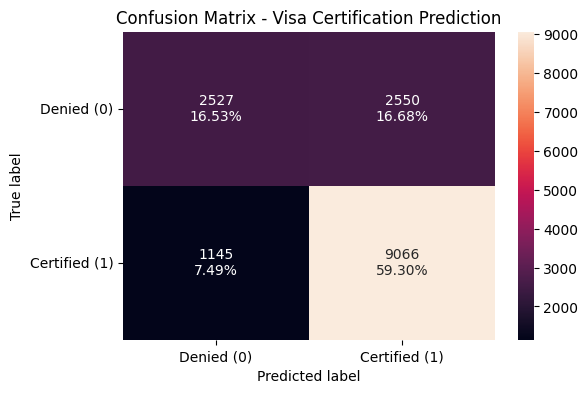

In [155]:
print("Tuned XGBoost - Training Confusion Matrix:")
confusion_matrix_sklearn(xgb_tuned, X_train, y_train)

**Observations on Tuned XGBoost - Training Confusion Matrix:**

* ***True Negative (TN = 2527, 16.53%):*** Correctly predicted 16.53% of denied cases.

* ***False Positive (FP = 2550, 16.68%):*** 16.68% of rejected cases were incorrectly labelled as certified.

* ***False Negative (FN = 1145, 7.49%):*** 7.49% of certified cases were incorrectly classed as rejected.

* ***True Positive (TP = 9066; 59.30%):*** Correctly identified 59.30% of certified cases.


**Conclusions:**

* The model demonstrates an excellent ability to identify certified cases with a moderate FP rate.  

* Training performance demonstrates effective learning without evidence of overfitting.

Tuned XGBoost - Validation Confusion Matrix:


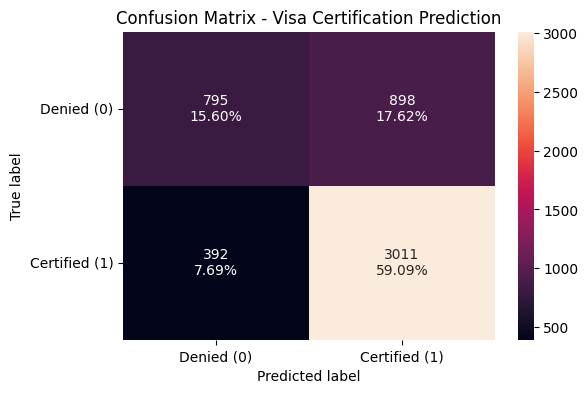

In [156]:
print("Tuned XGBoost - Validation Confusion Matrix:")
confusion_matrix_sklearn(xgb_tuned, X_val, y_val)

**Observations on Tuned XGBoost - Validation Confusion Matrix:**

* ***True Negative (TN = 795, 15.60%):*** accurately predicted 15.60% of refused cases.

* ***False Positive (FP = 898, 17.62%):*** 17.62% of refused cases were incorrectly designated as certified.

* ***False Negative (FN = 392, 7.69%):*** 7.69% of certified cases were incorrectly classed as rejected.

* ***True Positive (TP = 3011, 59.09%):*** Recognised 59.09% of certified cases.


**Conclusions:**

* Validation findings closely mirror training performance, with comparable rates of true and false positives.

* This consistency suggests good generalisation with no major overfitting.

##**Random Forest Tuned Model**

In [157]:
# Parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

# Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring=f1_scorer,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Perform tuning
print("Performing hyperparameter tuning for Random Forest:")
rf_random.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters for Random Forest:")
print(rf_random.best_params_)
print(f"Best Cross-Validation F1 Score: {rf_random.best_score_:.4f}")

# Evaluate tuned model
rf_tuned = rf_random.best_estimator_


Performing hyperparameter tuning for Random Forest:
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters for Random Forest:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}
Best Cross-Validation F1 Score: 0.8260


**Observations:**

* Performed a ***5-fold CV with 30 parameter*** candidates (150 fits).

* The optimal parameters selected are: ***n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=4, max_features='log2', class_weight=None***.

* The best cross-validation result was **F1 = 0.8260**.

* Random Forest performance is comparable to Gradient Boosting and XGBoost, with only a **slight improvement over the baseline model** following hypertuning.

**Checking Performance of Tuned Random Forest Model**

In [158]:
print("Tuned Random Forest - Training Performance:")
rf_train_perf_tuned = model_performance_classification_sklearn(rf_tuned, X_train, y_train)
rf_train_perf_tuned

Tuned Random Forest - Training Performance:


,Accuracy,Recall,Precision,F1
0,0.768184,0.897855,0.785671,0.838026


**Observations on Tuned Random Forest - Training Performance:**

* ***Accuracy (0.7682):*** Higher training accuracy of 76.82%.

* ***Recall (0.8979):*** Very high recall indicates great positive case identification.

* ***Precision (0.7857):*** Precision is moderately high at 78.57%, suggesting that a significant proportion of positive predictions are true.

* ***F1 Score (0.8380):*** Balanced with slightly better overall performance than XGBoost.

**Conclusions:**

* Random Forest exhibits excellent training performance, with good recall and precision, indicating effective learning.

In [159]:
print("Tuned Random Forest - Validation Performance:")
rf_val_perf_tuned = model_performance_classification_sklearn(rf_tuned, X_val, y_val)
rf_val_perf_tuned

Tuned Random Forest - Validation Performance:


,Accuracy,Recall,Precision,F1
0,0.747841,0.887746,0.769878,0.824621


**Observations on Tuned Random Forest - Validation Performance:**

* ***Accuracy (0.7478):*** The validation accuracy is 74.78%, which is close to training.

* ***Recall (0.8877):*** Recall remains high, in line with training, showing that the model is exceptionally good at detecting positive cases.

* ***Precision (0.7699):*** Slightly lower precision but still solid, indicating that positive predictions are correct.

* The ***F1 score (0.8246)*** is near to training, indicating strong generalisation.

***Conclusions:***

* Validation findings closely match training, demonstrating that the model generalises successfully without overfitting.

**Confusion Matrix of Tuned Random Forest Model**

Tuned Random Forest - Training Confusion Matrix:


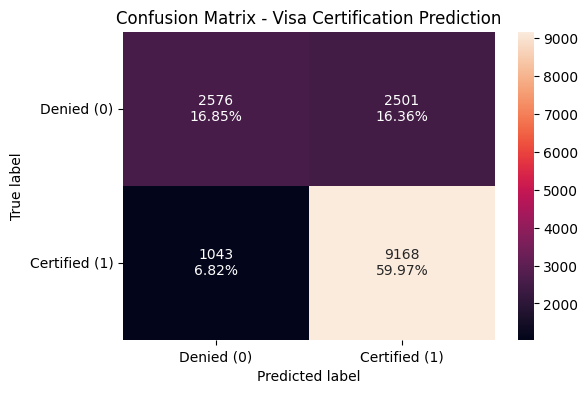

In [160]:
print("Tuned Random Forest - Training Confusion Matrix:")
confusion_matrix_sklearn(rf_tuned, X_train, y_train)

**Observations on Tuned Random Forest - Training Confusion Matrix:**

* ***True Negative (TN = 2576, 16.85%):*** accurately predicted 16.85% of refused cases.

* ***False Positive (FP = 2501, 16.36%):*** 16.36% of refused cases were incorrectly designated as certified.

* ***False Negative (FN = 1043, 6.82%):*** 6.82% of certified cases were incorrectly classed as rejected.

* ***True Positives (TP = 9168, 59.97%):*** Correctly detected 59.97% of certified cases.


**Conclusions:**

* On training data, the tuned Random Forest model beats XGBoost marginally due to higher true negative and true positive rates, as well as lower false negatives and false positives, showing robust learning.

Tuned Random Forest - Validation Confusion Matrix:


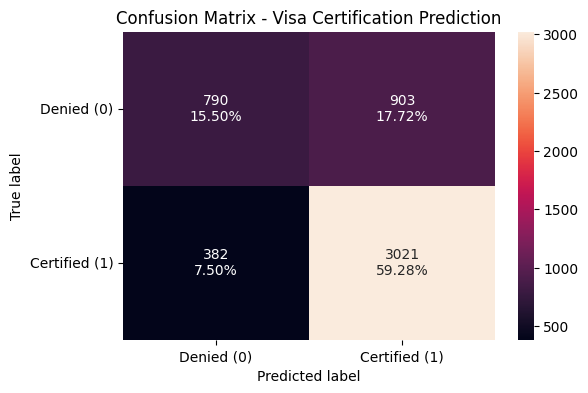

In [161]:
print("Tuned Random Forest - Validation Confusion Matrix:")
confusion_matrix_sklearn(rf_tuned, X_val, y_val)

**Observations on Tuned Random Forest - Validation Confusion Matrix:**

* ***True Negative (TN = 790, 15.50%):*** Correctly predicted 15.50% of denied cases.

* ***False Positive (FP = 903, 17.72%):*** 17.72% of denied cases were incorrectly designated as certified.

* ***False Negative (FN = 382, 7.50%):*** 7.50% of certified cases were incorrectly classed as rejected.

* ***True Positive (TP = 3021, 59.28%):*** Accurately identified 59.28% of certified cases.


***Conclusions:***

* Validation metrics are consistent with training results, demonstrating stable performance and high generalisation without overfitting.

##**AdaBoost Model Tuning**

In [162]:
# defining model
admodel = AdaBoostClassifier(random_state=42)

#Parameter grid for AdaBoost
ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.5, 1.0],
    'estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),]
    }


# Initialize RandomizedSearchCV
ada_random = RandomizedSearchCV(estimator=admodel,
    param_distributions=ada_param_grid,
    n_iter=30,
    scoring=f1_scorer,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,

)

# Perform tuning on the ORIGINAL training data
print("Performing hyperparameter tuning for AdaBoost on original data:")
ada_random.fit(X_train, y_train) # Make sure this is your original X_train, y_train

# Best parameters and score
print("Best Parameters for AdaBoost:")
print(ada_random.best_params_)
print(f"Best Cross-Validation F1 Score: {ada_random.best_score_:.4f}")

# Evaluate tuned model
ada_tuned = ada_random.best_estimator_

Performing hyperparameter tuning for AdaBoost on original data:
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters for AdaBoost:
{'n_estimators': 200, 'learning_rate': 0.05, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
Best Cross-Validation F1 Score: 0.8234


**Observations:**

* A ***5-fold CV was performed with 30 parameter*** candidates (150 fits).

* Best parameters: ***n_estimators = 200, learning_rate = 0.05, and estimator = DecisionTreeClassifier(max_depth = 3)***.

* The best cross-validation result was ***F1 = 0.8234***.

* AdaBoost performance is equivalent to Random Forest (0.8260) and XGBoost (0.8262), with just **a little improvement over the baseline** (0.8198).

**Checking Performance of Tuned AdaBoost Model**

In [163]:
print("Tuned AdaBoost - Training Performance:")
ada_train_perf_tuned = model_performance_classification_sklearn(ada_tuned, X_train, y_train)
ada_train_perf_tuned

Tuned AdaBoost - Training Performance:


,Accuracy,Recall,Precision,F1
0,0.751177,0.87631,0.778832,0.8247


**Observations on Tuned AdaBoost - Training Performance:**

* ***Accuracy (0.7512):*** Training accuracy of 75.12%.

* ***Recall (0.8763):*** A high recall indicates that positive cases are detected accurately.

* ***Precision (0.7788):*** indicates that most positive predictions are right.

* ***F1 Score (0.8247):*** indicates a balanced performance in terms of precision and recall.


**Conclusions:**

* AdaBoost outperforms on training data, with high recall and precision, indicating effective learning.

In [164]:
print("Tuned AdaBoost - Validation Performance:")
ada_val_perf_tuned = model_performance_classification_sklearn(ada_tuned, X_val, y_val)
ada_val_perf_tuned

Tuned AdaBoost - Validation Performance:


,Accuracy,Recall,Precision,F1
0,0.743721,0.876579,0.771,0.820407


**Observations on Tuned AdaBoost - Validation Performance:**

* ***Accuracy (0.7437):*** Validation data showed a slightly lower accuracy (74.37%).

* ***Recall (0.8766):*** Recall is steady, indicating stable positive case detection.

* ***Precision (0.7710):*** Slightly lower but still acceptable, suggesting model is able to predict positive case correctly.

* ***F1 Score (0.8204):*** This score is near to training and indicates strong generalisation.

**Conclusions:**

* AdaBoost's validation measures are similar to training, indicating strong generalisation without overfitting.


**Confusion Matrix of AdaBoost Tuned Model**

Tuned AdaBoost - Training Confusion Matrix:


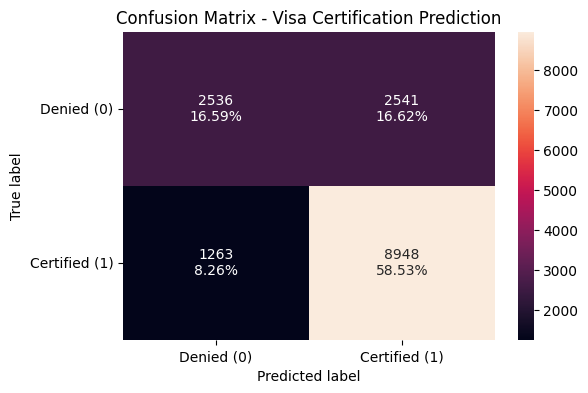

In [165]:
print("Tuned AdaBoost - Training Confusion Matrix:")

confusion_matrix_sklearn(ada_tuned, X_train, y_train)

**Observations on Tuned AdaBoost - Training Confusion Matrix:**

* ***True Negative (TN = 2536, 16.59%):*** Correctly predicted 16.59% of rejected cases.

* ***False Positive (FP = 2541, 16.62%):*** 16.62% of denied cases were incorrectly designated as certified.

* ***False Negative (FN = 1263; 8.26%):*** 8.26% of certified cases were incorrectly classed as rejected.

* ***True Positive (TP = 8948, 58.53%):*** Correctly identified 58.53% of certified cases.


**Conclusions:**

* AdaBoost performs well in training, but has a slightly higher false negative rate, meaning that more certified cases are misclassified as denied than in other models.

Tuned AdaBoost - Validation Confusion Matrix:


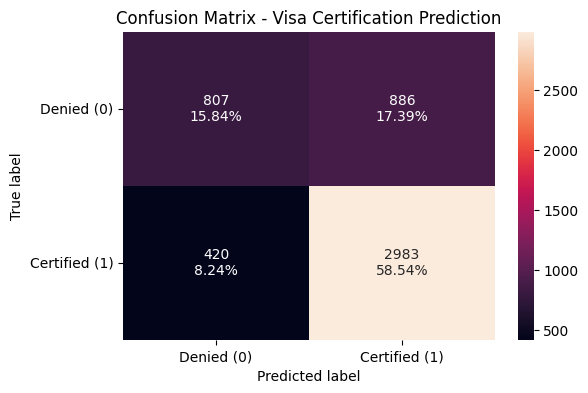

In [166]:
print("Tuned AdaBoost - Validation Confusion Matrix:")

confusion_matrix_sklearn(ada_tuned, X_val, y_val)

**Observations on Tuned AdaBoost - Validation Confusion Matrix:**

* ***True Negative (TN = 807, 15.84%):*** accurately predicted 15.84% of denied cases.

* ***False Positive (FP = 886, 17.39%):*** 17.39% of denied cases were incorrectly designated as certified.

* ***False Negative (FN = 420, 8.24%):*** 8.24% of certified cases were incorrectly classed as rejected.

* ***True Positive (TP = 2983, 58.54%):*** Correctly identified 58.54% of certified cases.


**Conclusions:**

* Validation results are similar to training, with a slightly higher false negative rate.  The model generalises well while avoiding significant overfitting.

# **MODEL COMPARISON & FINAL MODEL SELECTION**

In [167]:
# Create training performance comparison DataFrame
models_train_comp_df = pd.concat(
    [
        gb_train_perf_tuned.T,  # Tuned Gradient Boosting training performance
        xgb_train_perf_tuned.T,  # Tuned XGBoost training performance
        rf_train_perf_tuned.T,   # Tuned Random Forest training performance
        ada_train_perf_tuned.T   # Tuned AdaBoost training performance
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Gradient Boosting (Tuned)",
    "XGBoost (Tuned)",
    "Random Forest (Tuned)",
    "AdaBoost (Tuned)"
]

print("Training performance comparison (Tuned Models):")
models_train_comp_df

Training performance comparison (Tuned Models):


,Gradient Boosting (Tuned),XGBoost (Tuned),Random Forest (Tuned),AdaBoost (Tuned)
Accuracy,0.758438,0.758307,0.768184,0.751177
Recall,0.893350,0.887866,0.897855,0.876310
Precision,0.777929,0.780475,0.785671,0.778832
F1,0.831654,0.830714,0.838026,0.824700


In [168]:
# Create validation performance comparison DataFrame
models_val_comp_df = pd.concat(
    [
        gb_val_perf_tuned.T,  # Tuned Gradient Boosting validation performance
        xgb_val_perf_tuned.T,  # Tuned XGBoost validation performance
        rf_val_perf_tuned.T,   # Tuned Random Forest validation performance
        ada_val_perf_tuned.T   # Tuned AdaBoost validation performance
    ],
    axis=1,
)

models_val_comp_df.columns = [
    "Gradient Boosting (Tuned)",
    "XGBoost (Tuned)",
    "Random Forest (Tuned)",
    "AdaBoost (Tuned)"
]

print("Validation performance comparison (Tuned Models):")
models_val_comp_df

Validation performance comparison (Tuned Models):


,Gradient Boosting (Tuned),XGBoost (Tuned),Random Forest (Tuned),AdaBoost (Tuned)
Accuracy,0.746860,0.746860,0.747841,0.743721
Recall,0.891566,0.884808,0.887746,0.876579
Precision,0.767130,0.770274,0.769878,0.771000
F1,0.824681,0.823578,0.824621,0.820407


**Summary on Tuned Model Comparison  and Final Selection:**

**Rejected models:**

* ***Gradient Boosting*** works well with excellent recall and balanced precision, but ***its F1 score on training data is somewhat lower than Random Forest***, indicating a little less ideal balance of false positives and false negatives.

* ***XGBoost*** is similar to Gradient Boosting, but with somewhat ***lower F1, recall, and precision***.  Given the crucial need to reduce errors in visa approvals, even minor discrepancies matter.

* ***AdaBoost*** has the ***lowest F1 score and recall of any model***, increasing the likelihood of rejecting competent candidates (more false negatives).  This makes it less appropriate for the business objective.


**Selected Model: Tuned Random Forest:**

* Random Forest has the **highest F1 score for training (0.8380) and a competitive F1 score for validation (0.8246)**, resulting in the optimal balance of precision and recall.

* It also has the **highest recall**, which is crucial for accurately identifying suitable visa applicants, as well as high precision, which helps to eliminate false certifications.

* The **model generalises effectively and has minimal overfitting**, making it the most dependable option for generating accurate visa certification decisions.

#**Final Model- Tuned Random Forest**

**Checking Tuned Random Forest - Final Model's Performance on Test Set**

In [169]:
# Evaluate Random Forest performance on test set
rf_test_perf = model_performance_classification_sklearn(rf_tuned, X_test, y_test)
print("Tuned Random Forest - Test Performance:")
rf_test_perf

Tuned Random Forest - Test Performance:


,Accuracy,Recall,Precision,F1
0,0.740188,0.882491,0.764766,0.819422


**Observations:**

* ***Accuracy (0.7402):*** The model accurately predicts around 74.02% of the test set, showing good overall performance.

* ***Recall (0.8825):*** A high recall indicates that the model accurately detects 88.25% of certified cases, lowering false negatives and reducing the risk of dismissing qualified candidates.

* ***Precision (0.7648):*** A precision of 76.48% indicates that the majority of positive predictions (certified cases) are correct, which limits false positives.

* ***F1 Score (0.8194):*** The balanced F1 score demonstrates a strong trade-off between precision and recall, supporting the model's dependability for visa certification judgements based on untested data.


**Conclusion:**

* The **Tuned Random Forest model performs well on the test set**, with only a minor drop in performance compared to training and validation.  This consistency provides **high generalisation** ability and reliability for real-world visa certification predictions.

**Confusion Matrix-Tuned Random Forest Model**

Tuned Random Forest - Test Confusion Matrix:


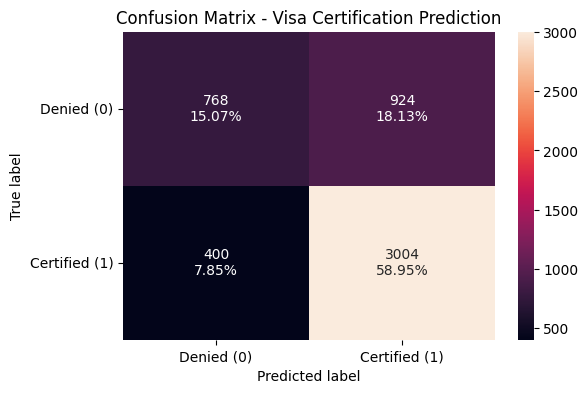

In [170]:
# create confusion matrix
print("Tuned Random Forest - Test Confusion Matrix:")
confusion_matrix_sklearn(rf_tuned, X_test, y_test)


**Observations on Tuned Random Forest - Test Confusion Matrix:**

* ***True Negative (TN) = 768 (15.07%):*** The model accurately predicted 15.07% of denied cases.

* ***False Negative (FN) = 924 (18.13%):*** The model incorrectly predicted 18.13% of the true denied cases as certified.

* ***False Positive (FP) = 400 (7.85%):*** The model wrongly predicted 7.85% of certified cases as refused.

* ***True Positive (TP) = 3004 (58.95%):*** The model accurately recognised 58.95% of certified cases.


**Conclusion:**

* The final model **performs well** at detecting certified applicants (high TP), but a significant number of denied cases are misclassified (high FN), indicating moderate sensitivity for class 0.  

* There are **no signs of overfitting** because performance measurements are consistent across test data.

**Predictions on Test Set &  Classification Report**

In [175]:
# Generate classification report
from sklearn.metrics import classification_report
y_test_pred = rf_tuned.predict(X_test)

print("Detailed Classification Report:")
print(classification_report(y_test, y_test_pred))


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.45      0.54      1692
           1       0.76      0.88      0.82      3404

    accuracy                           0.74      5096
   macro avg       0.71      0.67      0.68      5096
weighted avg       0.73      0.74      0.73      5096



**Observations:**

***Class 0 (Denied cases)***

* **Precision** (**0.66)**, meaning when the model predicts denial cases, it is correct 66% of the time.

* **Recall is relatively low at 0.45**, meaning that the model only **detects 45% of actual denied cases**, leaving out more than half of them.

* The **F1-score of 0.54** reflects this imbalance, indicating moderate performance in detecting rejected cases.


***Class I (Certified Cases)***

* **Precision is 0.76**, which means 76% of predicted certificates are correct.

* Recall is strong, at 0.88, indicating that the model correctly detects **88% of actual certified** cases while minimising false negatives.

* An **F1-score of 0.82** indicates excellent efficiency in recognising certified applications.
 Overall accuracy:

* The model has **74% accuracy**, correctly predicting around three-quarters of all cases.


***Macro Averages***

* Precision (**0.71**), recall (**0.67**), and F1-score (**0.68**) indicate that the model performs better on the majority class (certified) than the minority class (denied).

***Weighted Average***

* Weighted precision (**0.73**), recall (**0.74**), and F1-score (**0.73**) reflect the class distribution and overall balanced performance.

**Important Features Analysis**

Feature ranking:
1. education_of_employee_High School: 0.2236
2. prevailing_wage: 0.1565
3. has_job_experience: 0.1383
4. education_of_employee_Master's: 0.0960
5. no_of_employees: 0.0627
6. unit_of_wage_Year: 0.0547
7. yr_of_estab: 0.0536
8. education_of_employee_Doctorate: 0.0476
9. continent_Europe: 0.0391
10. region_of_employment_Midwest: 0.0225
11. region_of_employment_West: 0.0168
12. continent_Asia: 0.0162
13. continent_North America: 0.0147
14. region_of_employment_South: 0.0132
15. region_of_employment_Northeast: 0.0128
16. full_time_position: 0.0124
17. requires_job_training: 0.0088
18. continent_South America: 0.0059
19. unit_of_wage_Week: 0.0028
20. continent_Oceania: 0.0013


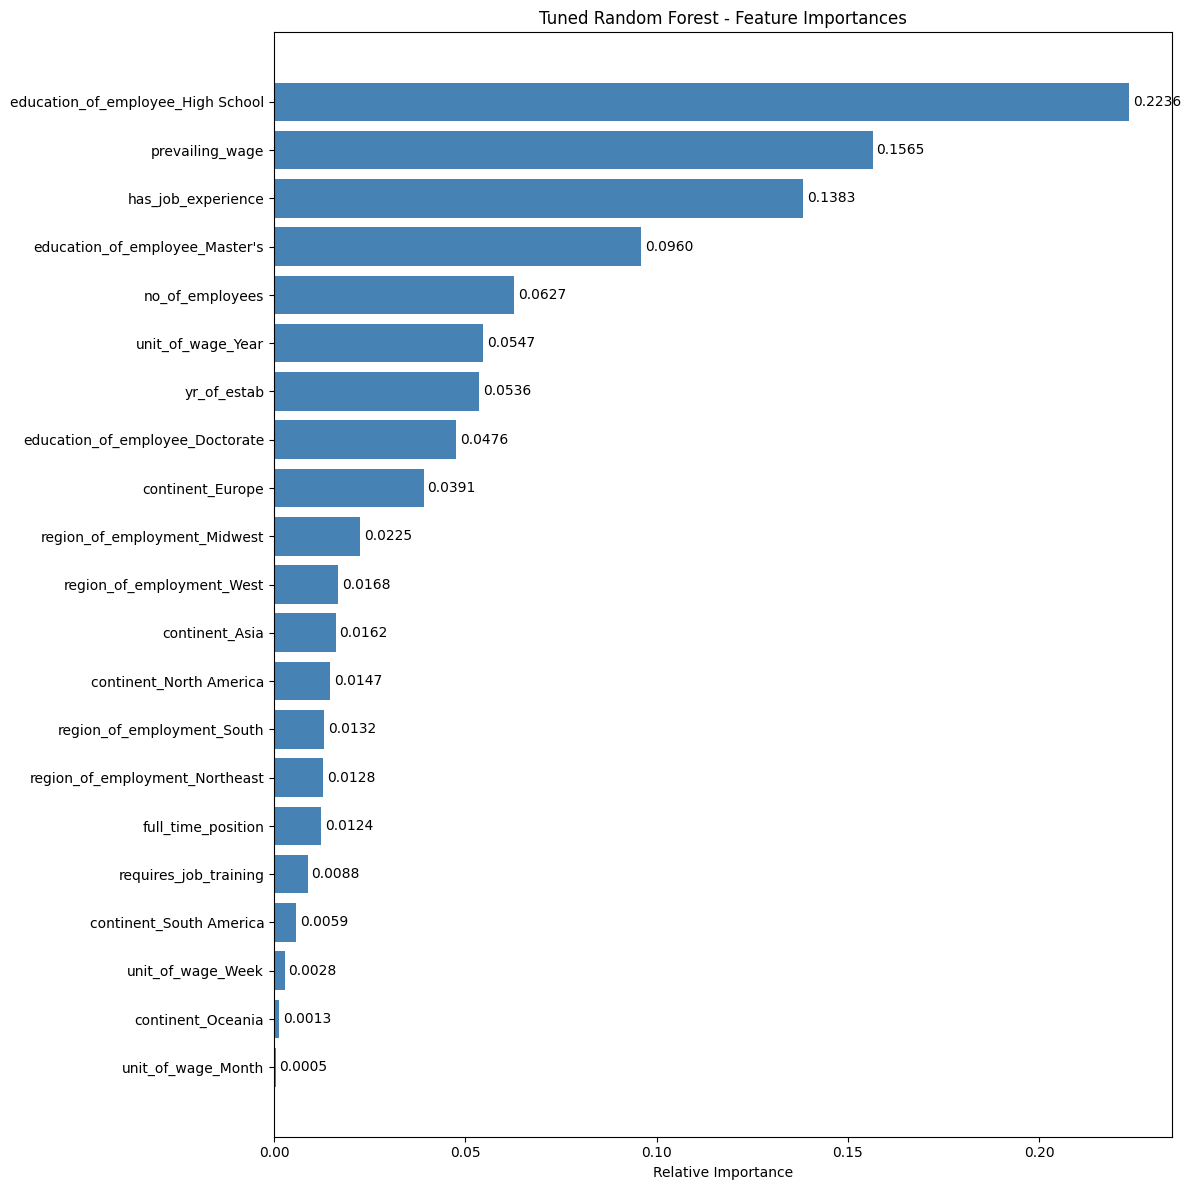

In [172]:
# Get feature importances
feature_names = X_train.columns
importances = rf_tuned.feature_importances_

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")
for f in range(min(20, len(feature_names))):  # Show top 20 features
    print(f"{f + 1}. {feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

# Plot the feature importances
plt.figure(figsize=(12, 12))
plt.title("Tuned Random Forest - Feature Importances")
bars = plt.barh(range(len(indices)), importances[indices], color="steelblue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis()  # Most important at the top

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', ha='left', va='center')

plt.tight_layout()
plt.show()

**Feature Importance Observations:**

* **Education_of_employee_High School has the most importance (0.2236)** because applicants with only a high school education are more likely to be denied, making this attribute a strong predictor of rejection.

* Although **Master's (0.0960) and Doctorate (0.0476)** degrees are associated with faster acceptance, their **lesser relevance** shows that these categories are less influential individually or in the data.

* **Prevailing_wage (0.1565) and has_job_experience (0.1383) are significant predictors**, indicating that higher earnings and relevant experience improve the likelihood of certification.

* Organisational characteristics such as **no_of_employees (0.0627) and year_of_estab (0.0536) have a moderate influence** on the model, demonstrating that company size and establishment year affect results.

* Geographical factors such as **region of employment & continent have a lesser** but cumulative impact, with location playing a little contribution.


**Conclusion:**

* Overall, the model focuses on factors that help distinguish refused applicants (e.g., high school education), which is critical for dealing with class imbalance and enhancing predictive accuracy.





#**ACTIONABLE INSIGHTS**

1. **Education plays a critical role**

   * Applicants with **Master's, Bachelor's, and Doctorate degrees** have a much higher approval rate compared to High School graduates.
   * A “High School” education was found to be the most significant negative factor in visa denials.

2. **Work experience strongly influences approval**

   * Applicants with prior **job experience** are significantly more likely to get approved than those without.

3. **Wage level matters, but only marginally**

   * Higher **prevailing wages** slightly increase the chances of approval, but it is not a deciding factor. Extremely low wages are more likely to lead to denials.

4. **Company size adds credibility**

   * Applications from **larger employers (higher employee counts)** tend to have slightly higher approval rates, likely due to greater financial stability and credibility.

5. **Company age (year of establishment) is neutral**

   * The data shows **no significant difference** in visa outcomes between older, legacy companies and newer ones.

6. **Employment type is a secondary factor**

   * **Full-time roles** have higher approval rates compared to part-time positions, but the effect is small compared to education and experience.

7. **Geographic & demographic factors matter less**

   * The region of employment and continent of origin show only minor influence compared to education, experience, and wage.

8. **Model performance trade-off**

   * The **Tuned Random Forest model** achieved about 74% accuracy with high recall (88% for certified cases).
   * However, about 18% of denied cases were incorrectly classified as certified, indicating that the model favors approvals more than denials.


#**BUSINESS RECOMMENDATIONS**

1. **Prioritize applicants with higher education and experience**

   * Visa authorities and EasyVisa should **flag applicants with Master's/Doctorate degrees and prior work experience** as strong candidates for certification.

2. **Enhance applicant profiles with training/experience**

   * For applicants with only High School education or no work experience, EasyVisa can **recommend additional certifications, internships, or training programs** to strengthen their profiles.

3. **Monitor wage benchmarks**

   * Employers should be encouraged to **offer at least median-level prevailing wages (about $70k)** to improve certification chances and avoid denials based on low wage offers.

4. **Build trust with smaller companies**

   * Since smaller employers have lower approval odds, EasyVisa could **help them document financial stability, compliance history, and legitimacy** to reduce perceived risks.

5. **Improve decision support for authorities**

   * Use the **Tuned Random Forest model as a screening tool** to automatically shortlist high-probability applicants.
   * Visa officers can then focus their manual reviews on borderline or high-risk applications, saving time and effort.

6. **Use insights for advisory services**

   * EasyVisa can create **advisory reports for employers and applicants**, showing how factors like education, wage, and experience impact approval odds.
   * This positions EasyVisa not just as a service provider but also as a **strategic consultant** in visa processing.

7. **Continuous monitoring & retraining**

   * The model should be **retrained annually** as visa approval trends, wage standards, and labor market conditions change.